# NYC TLC Yellow Taxi Trip Record Data

This project uses the NYC TLC Yellow Taxi trip records from January through November 2025 to study taxi movement patterns, unusual trip records, and zone-hour demand forecasting. The goal is to move from basic EDA into graph mining, clustering, anomaly detection, and forecasting that can explain how taxi demand changes across space and time.

In [1]:
try:
    from google.colab import drive
    drive.mount('/drive')
except ModuleNotFoundError:
    print('Not using google colab, skipping.')


Mounted at /drive


### Downloading the dataset for a configurable month/year range

Use `DATA_START` `DATA_END` (format `YYYY-MM`) to set the range of data to be downloaded. The downloader will download each monthly parquet file for the data range if it exists. `SAMPLE_ROWS_PER_MONTH` downsamples the Parquet file for each month to make RAM usage more managable.


In [2]:
# data range configuration
DATA_START = "2025-01"
DATA_END   = "2025-11"

# set to an integer (something like 500_000) to downsample each month after loading. Use None to keep the full size
SAMPLE_ROWS_PER_MONTH = 1_500_000
RANDOM_STATE = 412

# This is to control the removal of exact duplicates
DO_DEDUP = True

import pandas as pd

# print the range used in this analysis
PERIODS = pd.period_range(DATA_START, DATA_END, freq="M")
print(f"Configured period range: {PERIODS[0]} → {PERIODS[-1]} ({len(PERIODS)} months)")


Configured period range: 2025-01 → 2025-11 (11 months)


In [3]:
#download monthly Yellow Taxi parquet file

import os
from pathlib import Path
import urllib.request

BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
OUT_BASE = Path("data/nyc_tlc/yellow")
OUT_BASE.mkdir(parents=True, exist_ok=True)

def download_dataset(url: str, to_path: Path):
    to_path.parent.mkdir(parents=True, exist_ok=True)

    if to_path.exists() and to_path.stat().st_size > 0:
        print(f"!!! Already exists: {to_path.name} !!!")
        return

    print(f"Downloading from {url} ...")
    try:
        urllib.request.urlretrieve(url, str(to_path))
        size = to_path.stat().st_size / (1024 * 1024)
        print(f"Saved to {to_path} ({size:.2f} MB)")
    except Exception as e:
        # TLC doesnt always have all month
        print(f"Download failed for {to_path.name}: {e}")

for p in PERIODS:
    year, month = int(p.year), int(p.month)
    ym = f"{year}-{month:02d}"
    fname = f"yellow_tripdata_{ym}.parquet"

    dest = OUT_BASE / str(year) / fname
    url = f"{BASE_URL}/{fname}"

    download_dataset(url, dest)

print(f"Done. Files saved under: {OUT_BASE.resolve()}")


Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-01.parquet (56.42 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-02.parquet (57.55 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-03.parquet (66.72 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-04.parquet (64.23 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-05.parquet (74.23 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-06.parquet (70.14 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-07.parquet (63.84 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-08.parquet (59.41 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-09.parquet (69.08 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-10.parquet (71.78 MB)
Saved to data/nyc_tlc/yellow/2025/yellow_tripdata_2025-11.parquet (67.84 MB)
Done. Files saved under: /content/data/nyc_tlc/yellow


### 1) Load the dataset/Structure view + Simple cleaning.

In [4]:
# Load TLC Yellow Taxi parquet files into a single DataFrame
import numpy as np

# 1. Build file list for specific range
files = []
for p in PERIODS:
    year, month = int(p.year), int(p.month)
    f = Path(f"data/nyc_tlc/yellow/{year}/yellow_tripdata_{year}-{month:02d}.parquet")
    files.append(f)

missing = [str(f) for f in files if not f.exists()]
if missing:
    raise FileNotFoundError(
        "Missing one or more monthly files. Run the download cell above first.\n"
        + "\n".join(missing[:10])
        + (f"\n... and {len(missing)-10} more" if len(missing) > 10 else "")
    )

# Optional: this keeps memory lower, fall back to full read if columns differ
USE_COLUMNS = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]

dfs = []
for f in files:
    try:
        df = pd.read_parquet(f, columns=USE_COLUMNS)
    except Exception:
        df = pd.read_parquet(f)
        keep = [c for c in USE_COLUMNS if c in df.columns]
        df = df[keep] if keep else df

    if SAMPLE_ROWS_PER_MONTH is not None and len(df) > SAMPLE_ROWS_PER_MONTH:
        df = df.sample(SAMPLE_ROWS_PER_MONTH, random_state=RANDOM_STATE)

    df["source_month"] = f.stem.replace("yellow_tripdata_", "")
    dfs.append(df)

taxi_raw = pd.concat(dfs, ignore_index=True)

print("Shape:", taxi_raw.shape)
print("\nColumns:", list(taxi_raw.columns))

print("\n--- Info ---")
taxi_raw.info()

print("\n--- Random sample ---")
display(taxi_raw.sample(5, random_state=RANDOM_STATE))

# empty columns
empty_cols = []
for col in taxi_raw.columns:
    s = taxi_raw[col]
    if s.isnull().all():
        empty_cols.append(col)
    elif (s.dtype == "object" or pd.api.types.is_string_dtype(s)) and s.astype("string").str.strip().fillna("").eq("").all():
        empty_cols.append(col)

print("\nempty cols:", empty_cols if len(empty_cols) > 0 else "none")

# test to make sure all core collumns exist
expected_cols = {"tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "trip_distance", "fare_amount", "total_amount"}
assert len(taxi_raw) > 0, "taxi_raw is empty; load failed"
assert expected_cols.issubset(set(taxi_raw.columns)), f"Missing expected columns: {expected_cols - set(taxi_raw.columns)}"
print("Load tests passed")


Shape: (16500000, 21)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'source_month']

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16500000 entries, 0 to 16499999
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,source_month
11203433,2,2025-08-24 02:41:36,2025-08-24 02:49:00,1.0,1.88,1.0,N,148,137,1,...,1.0,0.5,3.29,0.0,1.0,19.74,2.5,0.0,0.75,2025-08
7046056,2,2025-05-13 10:37:53,2025-05-13 10:45:33,1.0,1.37,1.0,N,236,141,1,...,0.0,0.5,2.66,0.0,1.0,15.96,2.5,0.0,0.00,2025-05
8495458,2,2025-06-15 12:48:20,2025-06-15 13:03:03,NaN,2.59,NaN,None,75,42,0,...,0.0,0.5,0.00,0.0,1.0,17.10,NaN,NaN,0.00,2025-06
660139,2,2025-01-11 16:41:04,2025-01-11 16:50:05,1.0,0.98,1.0,N,43,230,2,...,0.0,0.5,0.00,0.0,1.0,14.75,2.5,0.0,0.75,2025-01
11121174,2,2025-08-20 19:12:17,2025-08-20 19:29:21,NaN,0.00,NaN,None,249,232,0,...,0.0,0.5,0.00,0.0,1.0,3.01,NaN,NaN,0.75,2025-08



empty cols: none
Load tests passed


In [5]:
# Clean and type conversions
taxi = taxi_raw.copy()

# drop all fully empty collumns
taxi = taxi.drop(columns=[c for c in empty_cols if c in taxi.columns])

# drop any 'unnamed' columns
unamed_cols = [c for c in taxi.columns if str(c).strip().lower().startswith("unnamed")]
if unamed_cols:
    taxi = taxi.drop(columns=unamed_cols)

# Parse datetimes (errors='coerce')
for col in ["tpep_pickup_datetime", "tpep_dropoff_datetime"]:
    if col in taxi.columns:
        taxi[col] = pd.to_datetime(taxi[col], errors="coerce")

# Coerce numerics (errors='coerce')
numeric_cols = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]
for col in numeric_cols:
    if col in taxi.columns:
        taxi[col] = pd.to_numeric(taxi[col], errors="coerce")

#standardize text flags
if "store_and_fwd_flag" in taxi.columns:
    taxi["store_and_fwd_flag"] = taxi["store_and_fwd_flag"].astype("string").str.strip().str.lower()


# Basic validity filters and row loss checking
n_raw = len(taxi)

# passenger count should be 0 to 6 for yellow taxi (0 can appear for missing of unkown)
if "passenger_count" in taxi.columns:
    pc_good = taxi["passenger_count"].isna() | taxi["passenger_count"].between(0, 6)
else:
    pc_good = True

# Distances and amounts should not be negative
dist_good = taxi["trip_distance"].isna() | (taxi["trip_distance"] >= 0) if "trip_distance" in taxi.columns else True

amt_cols = [c for c in ["fare_amount","total_amount","tip_amount","tolls_amount"] if c in taxi.columns]
amt_good = True
for c in amt_cols:
    amt_good = amt_good & (taxi[c].isna() | (taxi[c] >= 0))

taxi = taxi[pc_good & dist_good & amt_good].copy()
n_after_basic = len(taxi)

# dropoff must be >= pickup
if {"tpep_pickup_datetime","tpep_dropoff_datetime"}.issubset(taxi.columns):
    time_good = (
        taxi["tpep_pickup_datetime"].isna()
        | taxi["tpep_dropoff_datetime"].isna()
        | (taxi["tpep_dropoff_datetime"] >= taxi["tpep_pickup_datetime"])
    )
    taxi = taxi[time_good].copy()

n_after_time = len(taxi)

# drop exact duplicatess
if DO_DEDUP:
    taxi = taxi.drop_duplicates()

n_after_dedup = len(taxi)

print(f"Cleaned taxi: {taxi.shape[0]:,} rows x {taxi.shape[1]:,} cols")
print(
    f"Row-loss accounting: dropped {n_raw - n_after_dedup:,} total "
    f"(basic validity: {n_raw - n_after_basic:,}, time: {n_after_basic - n_after_time:,}, dups: {n_after_time - n_after_dedup:,})"
)


# Tests:
if "passenger_count" in taxi.columns:
    assert taxi["passenger_count"].dropna().between(0, 6).all(), "passenger count is out of bounds"
if "trip_distance" in taxi.columns:
    assert (taxi["trip_distance"].dropna() >= 0).all(), "trip distance is out of bounds"
for c in amt_cols:
    assert (taxi[c].dropna() >= 0).all(), f"{c} contains negative values after cleaning"

if {"tpep_pickup_datetime","tpep_dropoff_datetime"}.issubset(taxi.columns):
    tmp = taxi.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
    assert (tmp["tpep_dropoff_datetime"] >= tmp["tpep_pickup_datetime"]).all(), "there is a dropoff before pickup"

if DO_DEDUP:
    assert not taxi.duplicated().any(), "there are still some duplicate rows"

print("all cleaning tests passed")

# Keep these variables for later cells
n_after_pc_dist = n_after_basic
dropped_pc_dist = n_raw - n_after_basic
n_after_time = n_after_time
dropped_time = n_after_basic - n_after_time
n_after_dedup = n_after_dedup
dropped_dups = n_after_time - n_after_dedup


Cleaned taxi: 15,467,200 rows x 21 cols
Row-loss accounting: dropped 1,032,800 total (basic validity: 1,031,988, time: 812, dups: 0)
all cleaning tests passed


### 3) Decoding the categorical codes

There are several columns that are numeric codes. Decoding them for the EDA for readability and plot making.

Reference: NYC TLC Trip Record Data Dictionary (Yellow Taxi).

In [6]:
# TLC codebooks (Yellow Taxi)
# Source: TLC trip record data dictionary
ratecode_map = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride"
}

payment_type_map = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

store_and_fwd_map = {
    "y": "Store-and-forward",
    "n": "Not store-and-forward"
}

taxi["Ratecode_name"] = taxi["RatecodeID"].map(ratecode_map).astype("string").fillna("Unknown")
taxi["payment_type_name"] = taxi["payment_type"].map(payment_type_map).astype("string").fillna("Unknown")
taxi["store_and_fwd_name"] = taxi["store_and_fwd_flag"].map(store_and_fwd_map).astype("string").fillna("Unknown")

display(taxi[["RatecodeID","Ratecode_name","payment_type","payment_type_name","store_and_fwd_flag","store_and_fwd_name"]].sample(10))


,RatecodeID,Ratecode_name,payment_type,payment_type_name,store_and_fwd_flag,store_and_fwd_name
3225115,1.0,Standard rate,1,Credit card,n,Not store-and-forward
12391639,1.0,Standard rate,1,Credit card,n,Not store-and-forward
6624664,NaN,Unknown,0,Unknown,<NA>,Unknown
8253921,1.0,Standard rate,1,Credit card,n,Not store-and-forward
6661339,1.0,Standard rate,1,Credit card,n,Not store-and-forward
836033,1.0,Standard rate,1,Credit card,n,Not store-and-forward
16391496,1.0,Standard rate,1,Credit card,n,Not store-and-forward
16384296,1.0,Standard rate,1,Credit card,n,Not store-and-forward
13079795,NaN,Unknown,0,Unknown,<NA>,Unknown
14910224,1.0,Standard rate,1,Credit card,n,Not store-and-forward


### 4) Taxi Zone Lookup (LocationID → Borough/Zone)

Similar to the previous section, the code cells below will transform the location IDs into readable borough/zone to see spatial patterns without GPS.

In [7]:
import urllib.request
import zipfile
import io

ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

MISC_DIR = Path("data/nyc_tlc/misc")
MISC_DIR.mkdir(parents=True, exist_ok=True)
zone_file = MISC_DIR / "taxi_zone_lookup.csv"

def download_dataset(url: str, to_path: Path):
    to_path.parent.mkdir(parents=True, exist_ok=True)
    if to_path.exists() and to_path.stat().st_size > 0:
        print(f"!!! Already exists: {to_path.name} !!!")
        return
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, str(to_path))
    size = to_path.stat().st_size / (1024 * 1024)
    print(f"Saved to {to_path} ({size:.2f} MB)")

download_dataset(ZONE_LOOKUP_URL, zone_file)


# Also download the taxi zone shapefile used by the RQ1 map cell.
SHAPEFILE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
shp_dir = MISC_DIR / "taxi_zones"
if not shp_dir.exists() or not any(shp_dir.rglob("*.shp")):
    print("Downloading taxi zone shapefile ...")
    resp = urllib.request.urlopen(SHAPEFILE_URL)
    zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    shp_dir.mkdir(parents=True, exist_ok=True)
    zf.extractall(str(shp_dir))
    print(f"Extracted shapefile to {shp_dir}")

zones = pd.read_csv(zone_file)
zones["LocationID"] = pd.to_numeric(zones["LocationID"], errors="coerce")
zones = zones.dropna(subset=["LocationID"]).copy()
zones["LocationID"] = zones["LocationID"].astype(int)

display(zones.head())

# merge in pickup and dropoff labels
pu = zones.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "PU_Borough",
    "Zone": "PU_Zone",
    "service_zone": "PU_service_zone"
})

do = zones.rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "DO_Borough",
    "Zone": "DO_Zone",
    "service_zone": "DO_service_zone"
})

taxi = taxi.merge(pu, on="PULocationID", how="left")
taxi = taxi.merge(do, on="DOLocationID", how="left")

display(taxi[["PULocationID","PU_Borough","PU_Zone","DOLocationID","DO_Borough","DO_Zone"]].sample(10, random_state=RANDOM_STATE))


Saved to data/nyc_tlc/misc/taxi_zone_lookup.csv (0.01 MB)
Extracted shapefile to data/nyc_tlc/misc/taxi_zones


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,PULocationID,PU_Borough,PU_Zone,DOLocationID,DO_Borough,DO_Zone
15027274,162,Manhattan,Midtown East,163,Manhattan,Midtown North
11487466,263,Manhattan,Yorkville West,162,Manhattan,Midtown East
10353922,132,Queens,JFK Airport,95,Queens,Forest Hills
15389035,79,Manhattan,East Village,170,Manhattan,Murray Hill
15010780,132,Queens,JFK Airport,141,Manhattan,Lenox Hill West
4347981,113,Manhattan,Greenwich Village North,142,Manhattan,Lincoln Square East
4190243,74,Manhattan,East Harlem North,140,Manhattan,Lenox Hill East
12466276,211,Manhattan,SoHo,170,Manhattan,Murray Hill
5827863,116,Manhattan,Hamilton Heights,88,Manhattan,Financial District South
6403261,148,Manhattan,Lower East Side,238,Manhattan,Upper West Side North


### 5) Feature engineering: duration, speed, and time features
- `trip_duration_min` (dropoff - pickup)
- `speed_mph` (distance / duration)
- pickup time features (`pickup_hour`, `pickup_dow`)

In [8]:
taxi_fe = taxi.copy()

# Trip duration + speed
taxi_fe["trip_duration_min"] = (
    (taxi_fe["tpep_dropoff_datetime"] - taxi_fe["tpep_pickup_datetime"])
    .dt.total_seconds() / 60.0
)

# only computing speed when duration > 0
taxi_fe["speed_mph"] = np.where(
    taxi_fe["trip_duration_min"] > 0,
    taxi_fe["trip_distance"] / (taxi_fe["trip_duration_min"] / 60.0),
    np.nan
)

# pickup time features
taxi_fe["pickup_year"] = taxi_fe["tpep_pickup_datetime"].dt.year
taxi_fe["pickup_month"] = taxi_fe["tpep_pickup_datetime"].dt.month
taxi_fe["pickup_hour"] = taxi_fe["tpep_pickup_datetime"].dt.hour
taxi_fe["pickup_date"] = taxi_fe["tpep_pickup_datetime"].dt.date
taxi_fe["pickup_dow"] = taxi_fe["tpep_pickup_datetime"].dt.day_name()
taxi_fe["pickup_month_ts"] = taxi_fe["tpep_pickup_datetime"].dt.to_period("M").dt.to_timestamp()

# transforms/buckets
taxi_fe["trip_distance_log10"] = np.log10(taxi_fe["trip_distance"].fillna(0) + 1)
taxi_fe["total_amount_log10"] = np.log10(taxi_fe["total_amount"].fillna(0) + 1)

dur_bins = [-0.01, 0.5, 2, 5, 10, 20, 40, 120, 240, np.inf]
dur_labels = ["<0.5m", "0.5-2m", "2-5m", "5-10m", "10-20m", "20-40m", "40-120m", "120-240m", ">240m"]
taxi_fe["duration_bucket"] = pd.cut(taxi_fe["trip_duration_min"], bins=dur_bins, labels=dur_labels)

# Tip rate defined when fare_amount > 0
taxi_fe["tip_rate"] = np.where(taxi_fe["fare_amount"] > 0, taxi_fe["tip_amount"] / taxi_fe["fare_amount"], np.nan)

taxi = taxi_fe

display(
    taxi[[
        "tpep_pickup_datetime","tpep_dropoff_datetime",
        "trip_duration_min","trip_distance","speed_mph",
        "pickup_hour","pickup_dow","tip_amount","fare_amount","tip_rate",
        "trip_distance_log10","total_amount_log10","duration_bucket"
    ]].sample(10, random_state=RANDOM_STATE)
)

# Tests:
# trip_distance_log10 should be 0 when trip_distance is NaN
if taxi["trip_distance"].isna().any():
    assert taxi.loc[taxi["trip_distance"].isna(), "trip_distance_log10"].iloc[0] == 0.0, "trip_distance_log10 isnt 0"

# duration_bucket only contains allowed labels
allowed = set(dur_labels)
contains = set(taxi["duration_bucket"].dropna().astype(str).unique())
assert contains.issubset(allowed), f"not allowed labels: {contains - allowed}"

print("tests passed")


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min,trip_distance,speed_mph,pickup_hour,pickup_dow,tip_amount,fare_amount,tip_rate,trip_distance_log10,total_amount_log10,duration_bucket
15027274,2025-11-22 16:53:57,2025-11-22 17:04:33,10.600000,1.01,5.716981,16,Saturday,3.09,10.70,0.288785,0.303196,1.290925,10-20m
11487466,2025-09-15 07:05:40,2025-09-15 07:12:53,7.216667,1.58,13.136259,7,Monday,3.69,10.00,0.369000,0.411620,1.288696,5-10m
10353922,2025-08-29 19:36:09,2025-08-29 20:03:00,26.850000,6.68,14.927374,19,Friday,3.10,31.00,0.100000,0.885361,1.611192,20-40m
15389035,2025-11-18 22:32:01,2025-11-18 22:40:40,8.650000,1.64,11.375723,22,Tuesday,2.36,10.00,0.236000,0.421604,1.281261,5-10m
15010780,2025-11-11 22:17:47,2025-11-11 22:48:27,30.666667,16.94,33.143478,22,Tuesday,16.34,70.00,0.233429,1.253822,2.003374,20-40m
4347981,2025-04-17 23:15:35,2025-04-17 23:34:42,19.116667,4.20,13.182214,23,Thursday,0.00,22.28,0.000000,0.716003,1.447623,10-20m
4190243,2025-03-31 20:23:36,2025-03-31 20:30:10,6.566667,1.91,17.451777,20,Monday,0.00,13.70,0.000000,0.463893,1.271842,5-10m
12466276,2025-09-13 16:06:11,2025-09-13 16:33:50,27.650000,2.70,5.858951,16,Saturday,0.00,27.56,0.000000,0.568202,1.522575,20-40m
5827863,2025-05-20 14:22:19,2025-05-20 15:32:49,70.500000,10.30,8.765957,14,Tuesday,0.00,36.50,0.000000,1.053078,1.579784,40-120m
6403261,2025-05-03 22:41:35,2025-05-03 23:17:01,35.433333,7.30,12.361242,22,Saturday,8.45,36.60,0.230874,0.919078,1.714330,20-40m


tests passed


### 6) Outlier and validity checks

The data sometimes contains outliers and occasional invalid rows (e.g., extremely long durations, impossible speeds)

In [9]:
# build a filtered EDA view
taxi_feat = taxi.copy()

# Require core fields to be there for these checks
core_cols = ["trip_duration_min","trip_distance","fare_amount","total_amount"]
taxi_eda = taxi_feat.dropna(subset=core_cols).copy()

# trim extreme outliers using quantiles
def quantile_trim_mask(s, q_low=0.001, q_high=0.999):
    s2 = s.dropna()
    if len(s2) == 0:
        return pd.Series([True]*len(s), index=s.index)
    lo, hi = s2.quantile(q_low), s2.quantile(q_high)
    return s.isna() | s.between(lo, hi)

trim_rules = {
    "trip_duration_min_quantile_trim": quantile_trim_mask(taxi_eda["trip_duration_min"]),
    "trip_distance_quantile_trim": quantile_trim_mask(taxi_eda["trip_distance"]),
    "total_amount_quantile_trim": quantile_trim_mask(taxi_eda["total_amount"]),
}

# simple rule based checks
rules = {
    "duration_0.5_to_240_min": taxi_eda["trip_duration_min"].between(0.5, 240),
    "distance_0_to_100_mi": taxi_eda["trip_distance"].between(0, 100),
    "speed_0_to_80_mph": taxi_eda["speed_mph"].between(0, 80) | taxi_eda["speed_mph"].isna(),
    "fare_non_negative": taxi_eda["fare_amount"] >= 0,
    "total_non_negative": taxi_eda["total_amount"] >= 0,
}

all_rules = {**trim_rules, **rules}

mask = np.ones(len(taxi_eda), dtype=bool)
drop_report = []
for name, cond in all_rules.items():
    kept = int(cond.sum())
    dropped = int((~cond).sum())
    drop_report.append((name, kept, dropped, dropped/len(taxi_eda)*100))
    mask &= cond

# Keep the filtered trips for EDA and keep the removed tail for RQ2.
# RQ2 uses this tail to cluster candidate irregularity types.
taxi_eda_all_core = taxi_eda.copy()
outlier_mask = ~mask
outliers = taxi_eda_all_core[outlier_mask].copy()

def first_failed_rule(row_idx):
    failed = [name for name, cond in all_rules.items() if not bool(cond.loc[row_idx])]
    return failed[0] if failed else "kept"

if len(outliers) > 0:
    outliers["outlier_type"] = [first_failed_rule(idx) for idx in outliers.index]
else:
    outliers["outlier_type"] = pd.Series(dtype="object")

taxi_eda = taxi_eda_all_core[mask].copy()

drop_report_df = pd.DataFrame(drop_report, columns=["rule","kept","dropped","dropped_pct"]).sort_values("dropped", ascending=False)
display(drop_report_df)

print(f"taxi (cleaned): {len(taxi):,}")
print(f"taxi_eda (after filters): {len(taxi_eda):,}  (dropped: {len(outliers):,})")
print(f"outliers available for RQ2: {len(outliers):,}")
if len(outliers) > 0:
    print(outliers["outlier_type"].value_counts().head(10).to_string())

# create a smaller plotting sample for quicker plots
PLOT_SAMPLE_N = 500_000
taxi_plot = taxi_eda.sample(PLOT_SAMPLE_N, random_state=42) if len(taxi_eda) > PLOT_SAMPLE_N else taxi_eda
print(f"taxi_plot rows used for plotting: {len(taxi_plot):,}")


,rule,kept,dropped,dropped_pct
3,duration_0.5_to_240_min,15161025,306175,1.979511
2,total_amount_quantile_trim,15436290,30910,0.199842
0,trip_duration_min_quantile_trim,15451737,15463,0.099973
1,trip_distance_quantile_trim,15451746,15454,0.099915
5,speed_0_to_80_mph,15462803,4397,0.028428
4,distance_0_to_100_mi,15466397,803,0.005192
6,fare_non_negative,15467200,0,0.000000
7,total_non_negative,15467200,0,0.000000


taxi (cleaned): 15,467,200
taxi_eda (after filters): 15,117,731  (dropped: 349,469)
outliers available for RQ2: 349,469
outlier_type
duration_0.5_to_240_min            297246
total_amount_quantile_trim          21468
trip_duration_min_quantile_trim     15463
trip_distance_quantile_trim         14269
speed_0_to_80_mph                    1023
taxi_plot rows used for plotting: 500,000


## EDA summary

I kept the EDA focused on the parts that matter for the final questions: missingness, outliers, trip distributions, and spatial or temporal patterns. The checkpoint notebooks contain the fuller dataset comparison and early EDA notes.


In [10]:
# Missingness and rowloss summary
print("\n" + "-" * 120)
print("Missing values (raw) — top 10 by %:")

missing_raw = taxi_raw.isna().mean().sort_values(ascending=False)
display((missing_raw * 100).head(10).round(2).astype(str) + "%")

print("\n" + "-" * 120)
print("Missing values (cleaned) — top 10 by %:")

missing_clean = taxi.isna().mean().sort_values(ascending=False)
display((missing_clean * 100).head(10).round(2).astype(str) + "%")

# Row loss summary
print("\n" + "-" * 120)
print("What did we lose? (row loss summary):")

n_clean = len(taxi)
dropped_total = n_raw - n_clean

print(f"Raw rows: {n_raw:,}")
print(f"After basic validity filters: {n_after_pc_dist:,}  (dropped: {dropped_pc_dist:,})")
print(f"After time-order filter: {n_after_time:,}  (dropped: {dropped_time:,})")
if DO_DEDUP:
    print(f"After exact dedup: {n_after_dedup:,}  (dropped: {dropped_dups:,})")
else:
    print("After exact dedup: (skipped)")
print(f"Final cleaned rows: {n_clean:,}  (total dropped: {dropped_total:,})")

# Tests: row accounting should match the cleaning
assert n_after_dedup == n_clean, "Row counts don't match"
assert dropped_total == (dropped_pc_dist + dropped_time + dropped_dups), "Dropped counts don't sum to total dropped"
print("Row-loss tests passed")



------------------------------------------------------------------------------------------------------------------------
Missing values (raw) — top 10 by %:


,0
passenger_count,23.28%
Airport_fee,23.28%
congestion_surcharge,23.28%
store_and_fwd_flag,23.28%
RatecodeID,23.28%
trip_distance,0.0%
tpep_dropoff_datetime,0.0%
tpep_pickup_datetime,0.0%
VendorID,0.0%
payment_type,0.0%



------------------------------------------------------------------------------------------------------------------------
Missing values (cleaned) — top 10 by %:


,0
RatecodeID,19.99%
passenger_count,19.99%
store_and_fwd_flag,19.99%
congestion_surcharge,19.99%
Airport_fee,19.99%
speed_mph,1.13%
DO_service_zone,0.68%
DO_Borough,0.44%
DO_Zone,0.23%
PU_service_zone,0.22%



------------------------------------------------------------------------------------------------------------------------
What did we lose? (row loss summary):
Raw rows: 16,500,000
After basic validity filters: 15,468,012  (dropped: 1,031,988)
After time-order filter: 15,467,200  (dropped: 812)
After exact dedup: 15,467,200  (dropped: 0)
Final cleaned rows: 15,467,200  (total dropped: 1,032,800)
Row-loss tests passed


In my sample of the data (Jan–Nov 2025), the same five fields are missing for **23.28%** of trips:  
`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee`.

After basic cleaning, the missingness for these five fields drops to **19.99%**, but this is because invalid rows were removed.


### 7) Univariate distributions (raw vs trimmed)

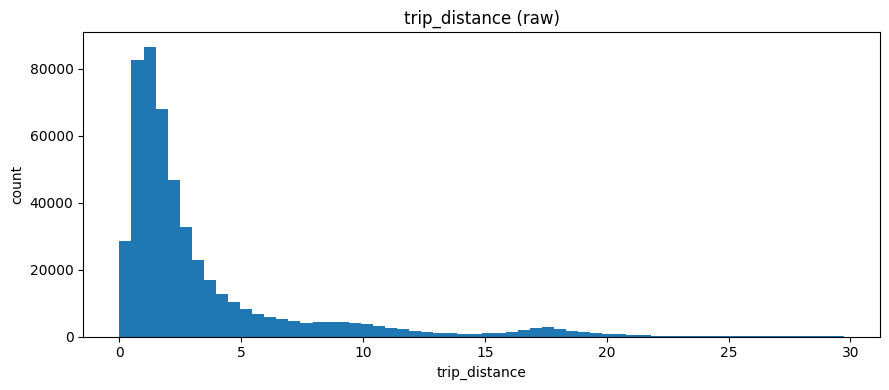

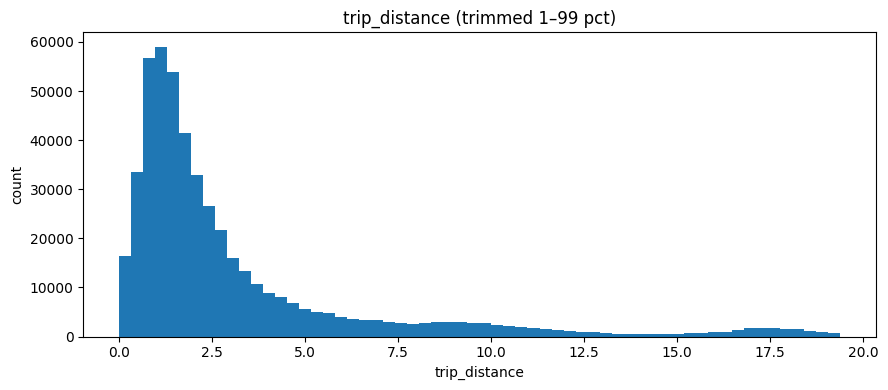

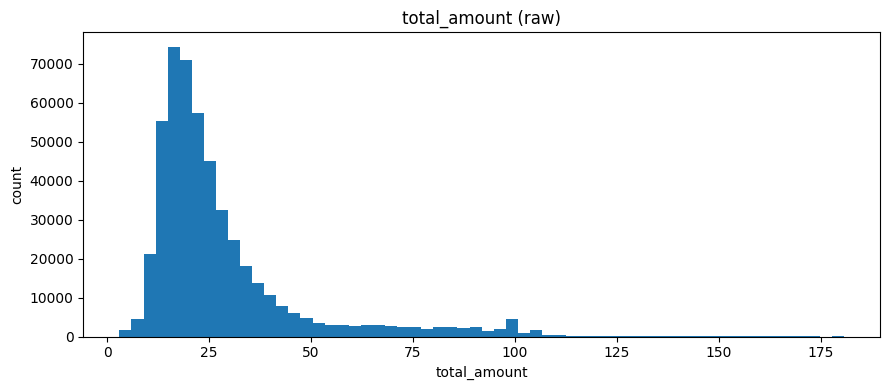

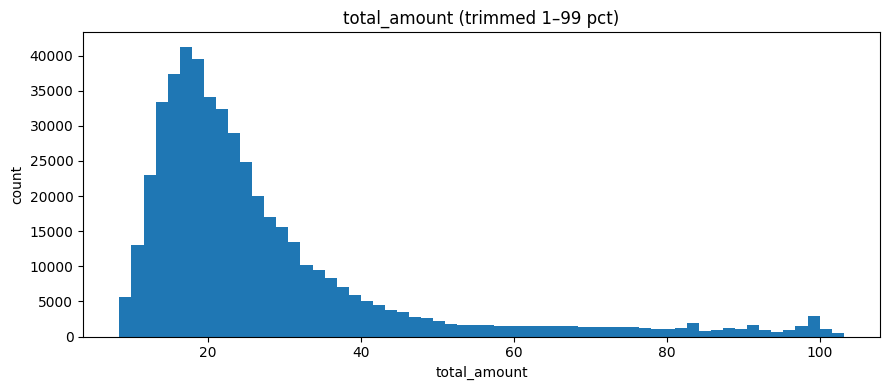

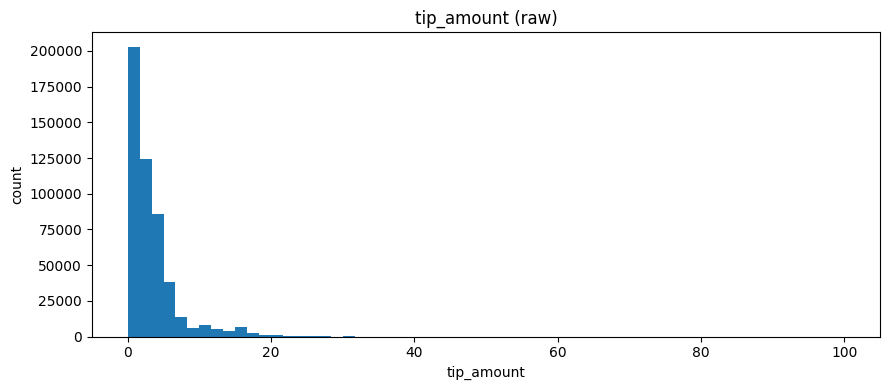

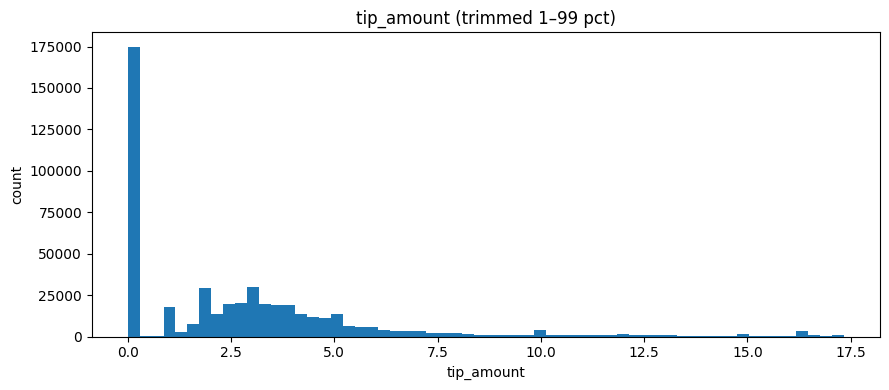

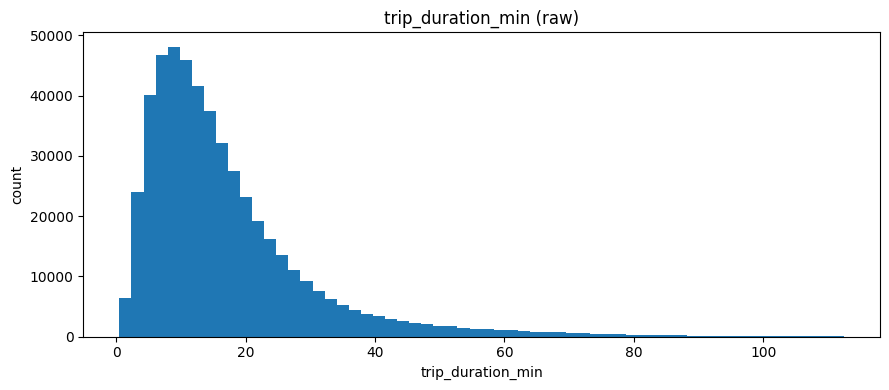

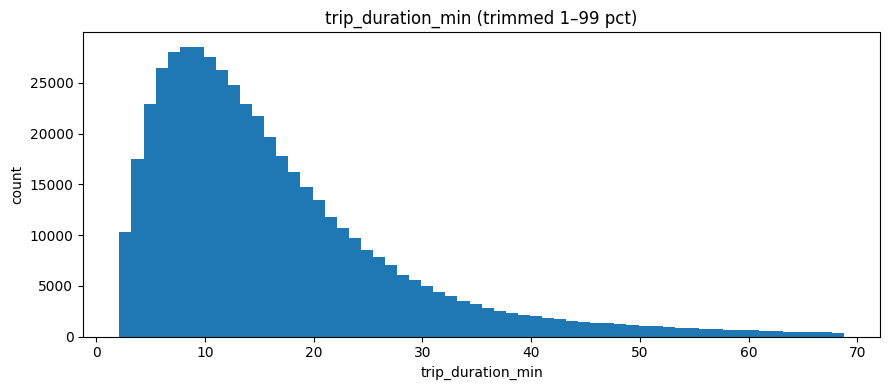

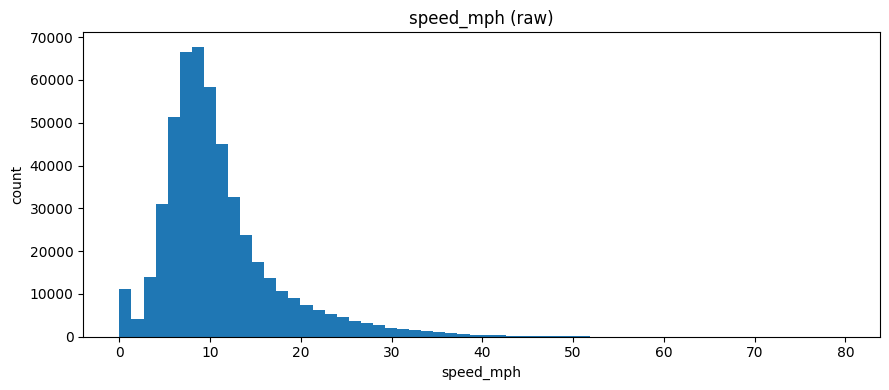

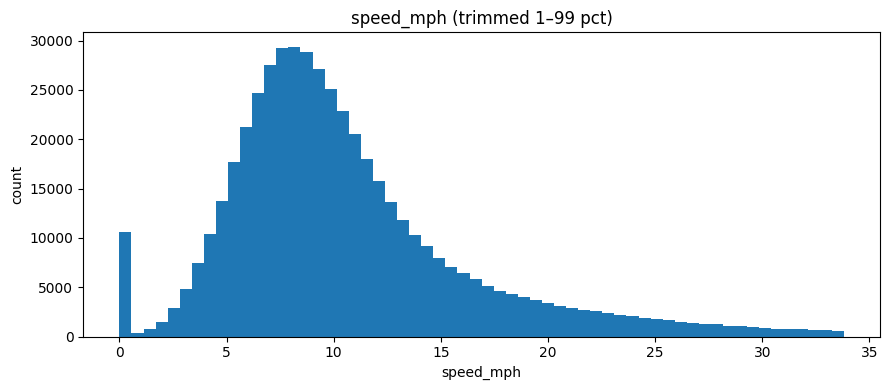

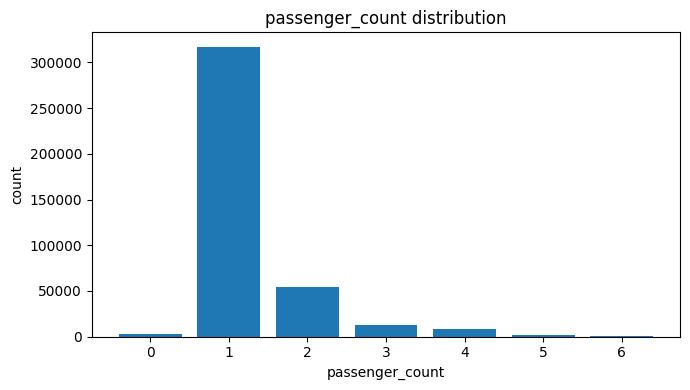

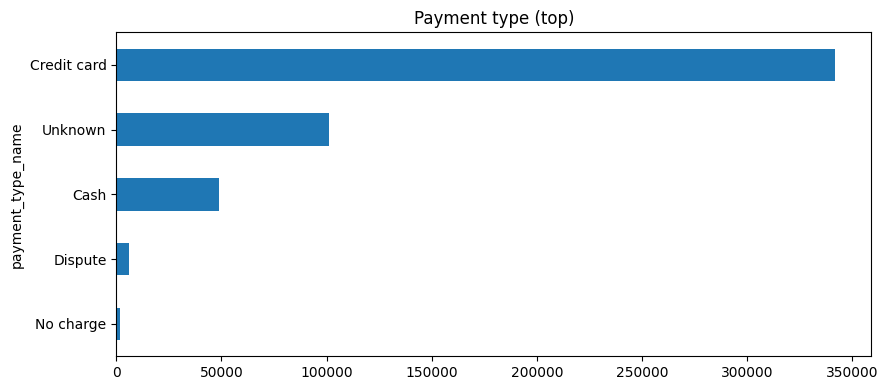

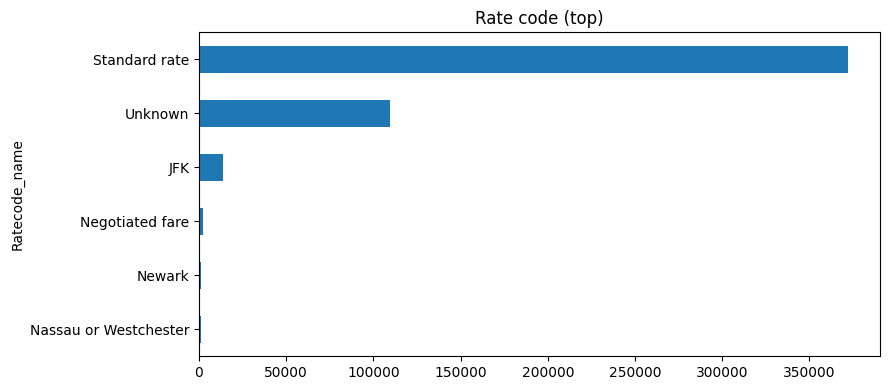

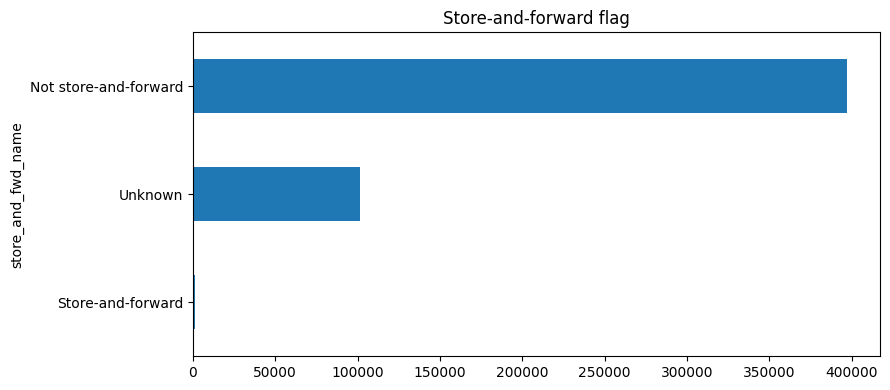

In [11]:
# Core distributions and top categories
import matplotlib.pyplot as plt

def hist_raw_and_trimmed(df, col, bins=60, q_low=0.01, q_high=0.99):
    x = df[col].dropna()
    if len(x) == 0:
        print(f"{col}: no data")
        return

    # Raw
    plt.figure(figsize=(9,4))
    plt.hist(x, bins=bins)
    plt.title(f"{col} (raw)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # Trimmed
    lo, hi = x.quantile(q_low), x.quantile(q_high)
    x_trim = x[(x >= lo) & (x <= hi)]
    plt.figure(figsize=(9,4))
    plt.hist(x_trim, bins=bins)
    plt.title(f"{col} (trimmed {q_low*100:.0f}–{q_high*100:.0f} pct)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

def top_bar(df, col, n=15, title=None):
    """quick top-N barh."""
    if col not in df.columns:
        return
    vc = df[col].value_counts(dropna=False).head(n)
    plt.figure(figsize=(9,4))
    vc.sort_values().plot(kind="barh")
    plt.title(title or f"Top {n}: {col}")
    plt.tight_layout()
    plt.show()

# the core numeric distributions
for col in ["trip_distance","total_amount","tip_amount","trip_duration_min","speed_mph"]:
    if col in taxi_plot.columns:
        hist_raw_and_trimmed(taxi_plot, col)

# passenger count distributions
if "passenger_count" in taxi_plot.columns:
    pc = taxi_plot["passenger_count"].dropna().astype(int)
    plt.figure(figsize=(7,4))
    plt.bar(pc.value_counts().sort_index().index.astype(str), pc.value_counts().sort_index().values)
    plt.title("passenger_count distribution")
    plt.xlabel("passenger_count")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# Top categories
top_bar(taxi_plot, "payment_type_name", 10, "Payment type (top)")
top_bar(taxi_plot, "Ratecode_name", 10, "Rate code (top)")
top_bar(taxi_plot, "store_and_fwd_name", 5, "Store-and-forward flag")


- **Trip distance** is strongly right skewed. Meaning most rides are short, with a secondary bump in the high teens miles that might be outer borough or airport trips.
- **Total amount** concentrates around common short fares (tens of dollars) with a long right tail. There is a secondary spike at 100.
- **Tip amount** shows common lack of tips or very small usual tips. Analysis on tips isn't necessarily reliable as cash tips would likely not be accurately recorded.
- **Trip duration** peaks around short to moderate lengths (a couple minute to under 20 minutes)
- **Speed** These results make sense for a busy city such as NYC (single/low double digits)
- **Passenger count** is dominated by **1–2 passengers**; the presence of **0** indicates missing marked as 0.
- **Credit card** dominates recorded payments, while **“Unknown” payment type** is a substantial subset and is also where many other fields go missing.


### 8) Spatial & temporal patterns
- Trips by pickup hour / day-of-week
- Top pickup and dropoff boroughs/zones
- Most common OD pairs

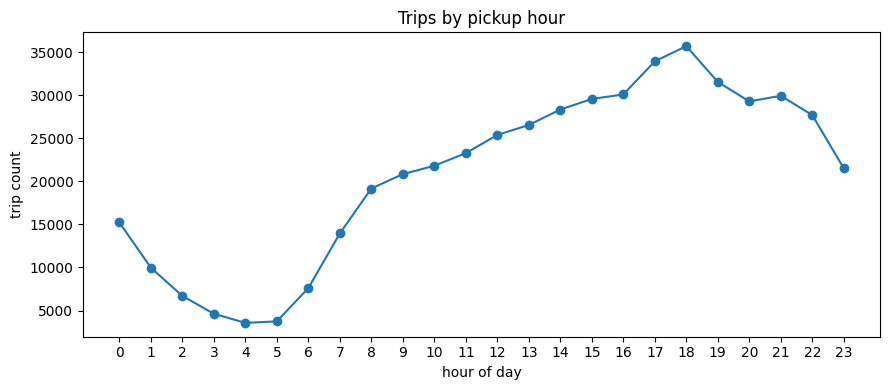

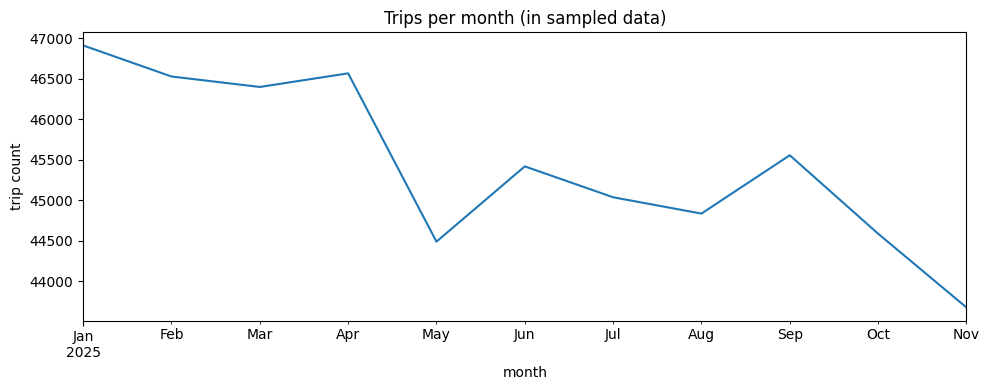

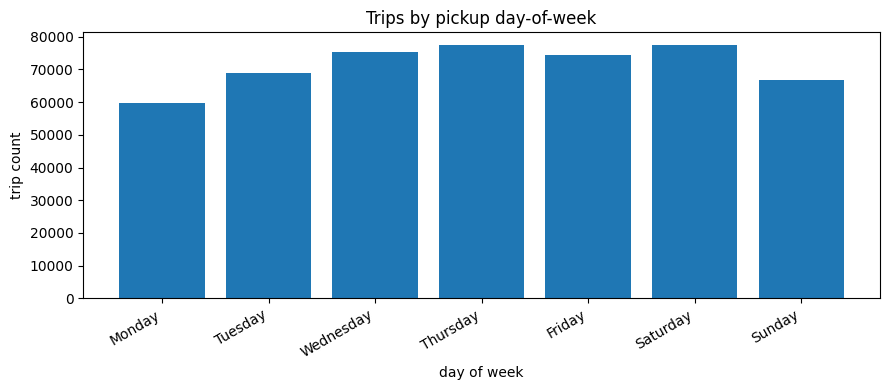

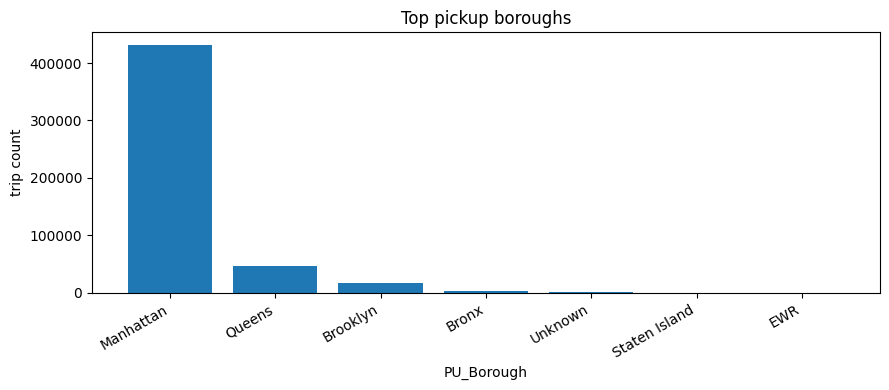

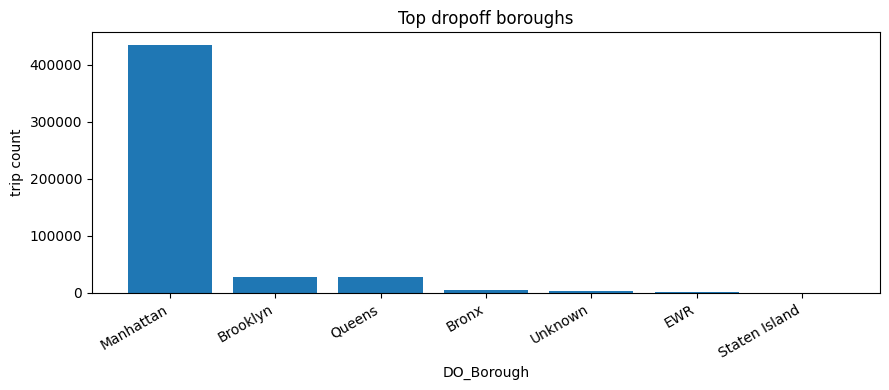

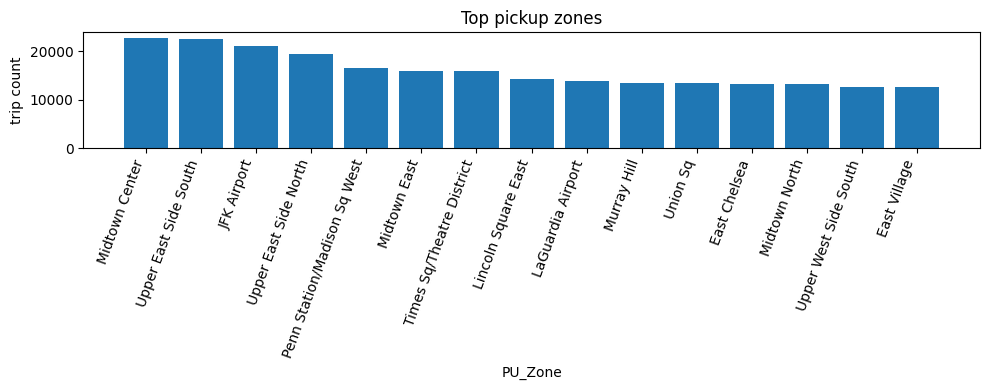

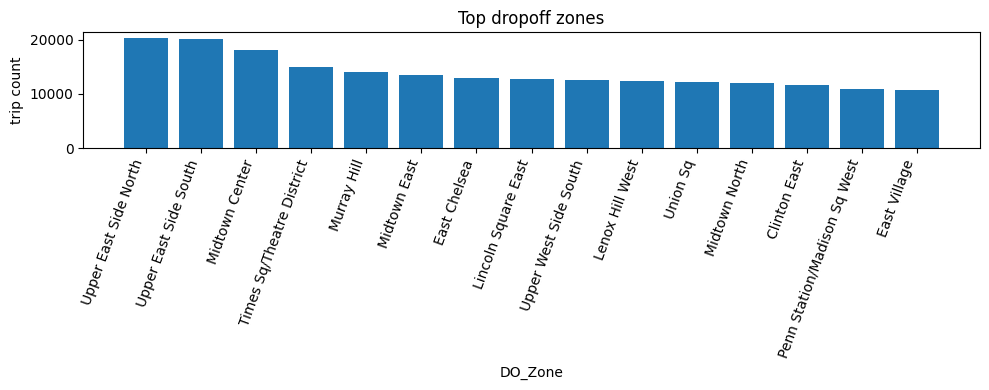

,PU_Zone,DO_Zone,trip_count
0,Upper East Side South,Upper East Side North,3227
1,Upper East Side North,Upper East Side South,2692
2,Upper East Side South,Upper East Side South,2173
3,Upper East Side North,Upper East Side North,2033
4,Midtown Center,Upper East Side South,1599
5,Upper East Side South,Midtown Center,1429
6,Midtown Center,Upper East Side North,1242
7,Upper East Side South,Midtown East,1151
8,Upper West Side South,Upper West Side North,1092
9,Lincoln Square East,Upper West Side South,1080


In [12]:
# trips by pickup hour
hour_counts = taxi_plot["pickup_hour"].value_counts().sort_index()
plt.figure(figsize=(9,4))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.title("Trips by pickup hour")
plt.xlabel("hour of day")
plt.ylabel("trip count")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

# trips by pickup month
if "pickup_month_ts" in taxi_plot.columns:
    month_counts = taxi_plot.groupby("pickup_month_ts").size()
    plt.figure(figsize=(10,4))
    month_counts.plot(kind="line")
    plt.title("Trips per month (in sampled data)")
    plt.xlabel("month")
    plt.ylabel("trip count")
    plt.tight_layout()
    plt.show()

# Trips by pickup (day of the week)
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = taxi_plot["pickup_dow"].value_counts().reindex(dow_order)
plt.figure(figsize=(9,4))
plt.bar(dow_counts.index, dow_counts.values)
plt.title("Trips by pickup day-of-week")
plt.xlabel("day of week")
plt.ylabel("trip count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# top pickup/dropoff boroughs
for col, title in [("PU_Borough","Top pickup boroughs"), ("DO_Borough","Top dropoff boroughs")]:
    if col not in taxi_plot.columns:
        continue
    vc = taxi_plot[col].fillna("Unknown").value_counts().head(10)
    plt.figure(figsize=(9,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("trip count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# top pickup/dropoff zones
for col, title in [("PU_Zone","Top pickup zones"), ("DO_Zone","Top dropoff zones")]:
    if col not in taxi_plot.columns:
        continue
    vc = taxi_plot[col].fillna("Unknown").value_counts().head(15)
    plt.figure(figsize=(10,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("trip count")
    plt.xticks(rotation=70, ha="right")
    plt.tight_layout()
    plt.show()

# most common zone pairs
od = (
    taxi_plot.dropna(subset=["PU_Zone","DO_Zone"])
            .groupby(["PU_Zone","DO_Zone"])
            .size()
            .sort_values(ascending=False)
            .head(20)
            .reset_index(name="trip_count")
)
display(od)


- pickups are lowest around **4–5am**, then rise sharply into the morning, with the largest peak in the **early evening**. This fits common working hours.
- **Day of the week:** trips are higher mid/late week and on **Saturday**, while **Sunday/Monday** are lower.
- both pickups and dropoffs are dominated by **Manhattan**, with **Queens** next. Most likely amplified by airports.  
- The top zones include Midtown/UES areas and major transit/airport zones.
- the most frequent origin/destination pairs are largely within Manhattan, this indicates that a large fraction of trips are within a single borough.
- These patterns suggest using zone level aggregation for later mining/modeling.


### 9) Missingness patterns (by payment type, vendor, time, geography)

Columns with missing values: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee', 'PU_Borough', 'PU_Zone', 'PU_service_zone', 'DO_Borough', 'DO_Zone', 'DO_service_zone', 'speed_mph', 'tip_rate']


,missing_pct
RatecodeID,19.99
passenger_count,19.99
store_and_fwd_flag,19.99
congestion_surcharge,19.99
Airport_fee,19.99
speed_mph,1.13
DO_service_zone,0.68
DO_Borough,0.44


,RatecodeID,passenger_count,store_and_fwd_flag,congestion_surcharge,Airport_fee,speed_mph,DO_service_zone,DO_Borough
payment_type_name,,,,,,,,
Cash,0.0,0.0,0.0,0.0,0.0,1.56,1.16,0.76
Credit card,0.0,0.0,0.0,0.0,0.0,1.40,0.71,0.45
Dispute,0.0,0.0,0.0,0.0,0.0,0.40,1.36,1.24
No charge,0.0,0.0,0.0,0.0,0.0,2.39,1.95,1.07
Unknown,100.0,100.0,100.0,100.0,100.0,0.01,0.25,0.21


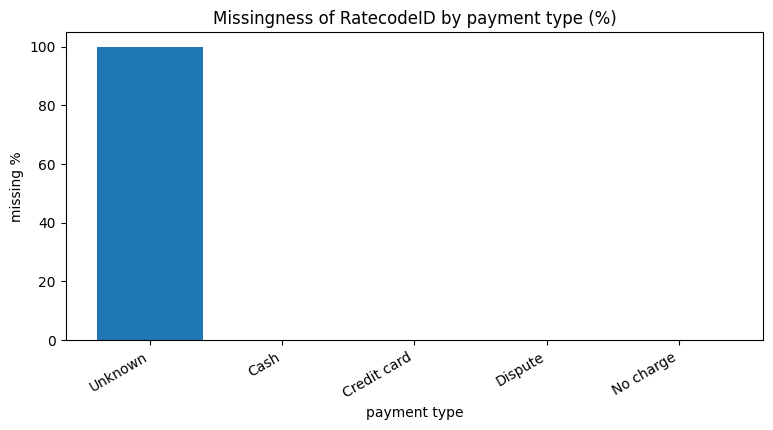

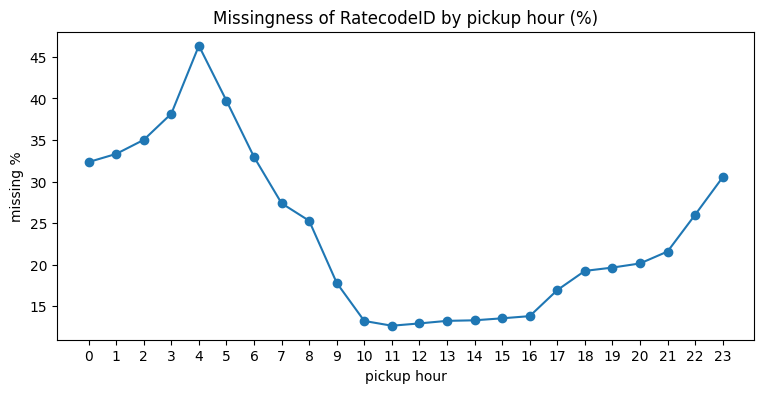

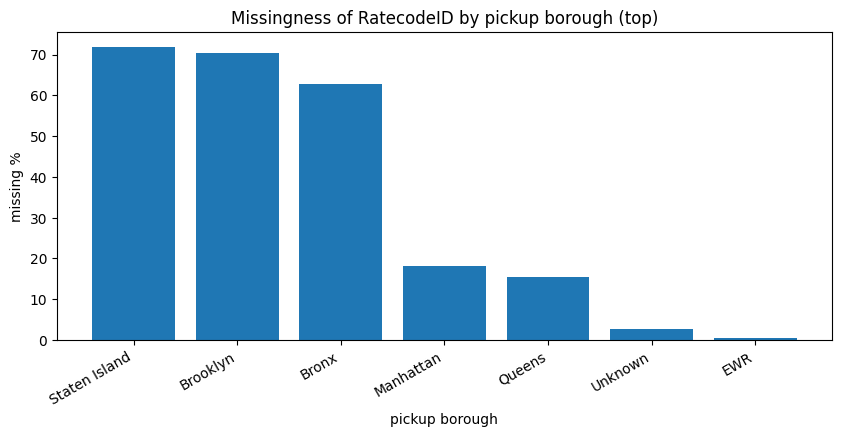

In [13]:
# Columns with any missing values (after cleaning)
missing_cols = [c for c in taxi.columns if taxi[c].isna().any()]
print("Columns with missing values:", missing_cols)

# highest missing numeric columns
top_missing = (
    taxi.isna().mean()
       .sort_values(ascending=False)
       .head(8)
)
display((top_missing * 100).round(2).to_frame("missing_pct"))

focus_cols = list(top_missing.index)

# by payment type
miss_by_pay = (
    taxi.groupby("payment_type_name")[focus_cols]
        .apply(lambda g: g.isna().mean() * 100)
        .round(2)
        .sort_index()
)
display(miss_by_pay)

# plot missingness for the single highest missing column by payment type
most_missing_col = top_missing.index[0]
tmp = (taxi.groupby("payment_type_name")[most_missing_col]
          .apply(lambda s: s.isna().mean()*100)
          .sort_values(ascending=False))

plt.figure(figsize=(9,4))
plt.bar(tmp.index.astype(str), tmp.values)
plt.title(f"Missingness of {most_missing_col} by payment type (%)")
plt.xlabel("payment type")
plt.ylabel("missing %")
plt.xticks(rotation=30, ha="right")
plt.show()

# by pickup hour
tmp2 = (taxi.groupby("pickup_hour")[most_missing_col]
           .apply(lambda s: s.isna().mean()*100)
           .sort_index())

plt.figure(figsize=(9,4))
plt.plot(tmp2.index, tmp2.values, marker="o")
plt.title(f"Missingness of {most_missing_col} by pickup hour (%)")
plt.xlabel("pickup hour")
plt.ylabel("missing %")
plt.xticks(range(0,24))
plt.show()

# by pickup borough
if "PU_Borough" in taxi.columns:
    tmp3 = (taxi.groupby(taxi["PU_Borough"].fillna("Unknown"))[most_missing_col]
               .apply(lambda s: s.isna().mean()*100)
               .sort_values(ascending=False)
               .head(12))

    plt.figure(figsize=(10,4))
    plt.bar(tmp3.index.astype(str), tmp3.values)
    plt.title(f"Missingness of {most_missing_col} by pickup borough (top)")
    plt.xlabel("pickup borough")
    plt.ylabel("missing %")
    plt.xticks(rotation=30, ha="right")
    plt.show()


- In the cleaned data, the top missing fields are still the same five (`RatecodeID`, `passenger_count`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`).
- Missingness is **not random**. By payment type, the “Unknown” group shows **100% missing**.  
This likely means we should **filter out** `payment_type = Unknown` for analyses that require these fields
- Missingness also varies with **pickup hour** (highest in the early hours) and by **pickup borough** (very high percentages in low trip boroughs like Staten Island).


### 10) Bias / limitations

- **Coverage bias:** Yellow taxi trips are only a fraction of total transit and excludes ride share such as UBER/Lyft.
- **Tips field bias:** `tip_amount` is typically recorded for **credit card** trips, but likely unreliable for cash tips, so tip statistics by payment type can be misleading.
- `PULocationID`/`DOLocationID` are taxi zones, not exact coordinates. Conclusions depend on zone boundaries.
- **Outliers/record errors:** Trip duration, distance, and fares can contain data entry errors. Filters change reported averages.


## (E) Initial insights and direction

### What the EDA suggests
**Data scope used for this report:** `DATA_START=2025-01`, `DATA_END=2025-11`, with `SAMPLE_ROWS_PER_MONTH=1,500,000` (This notebook is large but sampled).

**Cleaning:**
- **Loaded 16,500,000** trips (sampled across 11 months).
- **After basic cleaning there were 15,467,200** trips (**1,032,800 dropped**, 6.3%).  
  The removals are driven by basic constraints (e.g., negative money fields, invalid passenger counts, negative distances, and a small number of timing issues).

**Outliers / “typical trip” vs tail**
- The filtered set keeps **15,117,731** trips and drops **349,469** (2.3% of cleaned), with the biggest filter enforced being a duration window of 0.5 to 240 minutes.  
  This indicates that a non trivial “tail” exists and is worth analyzing separately.

**Missingness is structured**
- The same five columns have substantial missingness: **23.28%** missing in the raw sample and **19.99%** missing after cleaning (`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`).
- Missingness is strongly associated with `payment_type = "Unknown"` (these fields are 100% missing there), and also varies by time-of-day and borough.  
  Conclusion: for models using these fields, we should most likely **exclude** the “Unknown payment type” subset.

**Behavioral patterns visible in plots**
- Trips are mostly short (distance + duration are right-skewed), speeds cluster at typical busy city speeds, and Manhattan dominates pickups and dropoffs.  
- Airports and major hubs appear in top zones, and top pairs are mostly within Manhattan.

### Hypotheses / RQs
1. **Graph structure of flows:** If we build a zone level OD flow graph (weighted by trip counts), do we observe clear communities, and do those communities change by hour/day?
2. **Anomalies in tail:** Can we automatically detect and characterize anomalous trips and separate data errors from “plausible” events using anomaly detection on the engineered features?
3. **Tip rate modeling:** For credit card trips, can we predict `tip_rate = tip_amount / total_amount` using trip features and do zone-graph features improve said model's performance?

### Beyond course technique to look into
**graph mining + spatiotemporal modeling**:
- Construct an OD flow graph with zones as nodes and weighted directed edges as trips.  
- Run community detection (to find mobility subregions) and/or node embeddings(to represent zones).  
- Use the graph features for tasks like zone-hour demand predictions, anomaly detection, and comparing against non-graph baselines.


# Project Checkpoint 2: Research Question Formation


## 1. Project Scope

**Dataset:** NYC TLC Yellow Taxi trip records, January–November 2025 (~15.5M cleaned trips across 263 taxi zones, sampled at 1.5M rows/month).

**EDA findings:** Trips are short and right-skewed (distance, duration, fare.) Manhattan dominates pickup and dropoffs with airports as secondary hubs. Around 350K outlier trips (2.3%) were trimmed by my duration rules. Five columns show ~20% missingness tied to `payment_type = "Unknown"`. The tip amounts are only reliable for credit card trips. And trip volume varies by hour and day of the week.

**Course techniques:** Clustering (k-means, DBSCAN), graph mining (PageRank, Personalized PageRank community detection), supervised learning (Gradient-Boosted Decision Trees / XGBoost)  
**External technique:** Spatiotemporal demand forecasting. This involves predicting zone and hour trip demand using time-series or sequence-based methods not covered in the course.


## 2. Research Questions


### RQ1: Do taxi zones form distinct communities in the origin-destination flow graph, and does that community structure change throughout the day?

| | |
|---|---|
| **Data mining task** | Graph mining/community detection |
| **Algorithms** | PageRank (course), Personalized PageRank sweep (course) |
| **Evaluation criteria** | geographic coherence vs. borough boundaries; stability across time of day slices |

 Checkpoint 1's EDA showed Manhattan core and airport hubs via raw trip counts, but did not examine the relational flow structure between zones. Building a weighted directed graph (zones = nodes, trip counts = edge weights) and running community detection to see whether zones group into meaningful sub-regions beyond the five-borough partition.



### RQ2: Can density based clustering identify and characterize distinct anomaly types among outlier trips, and how do those clusters compare to the heuristic outlier rules used in checkpoint 1?

| | |
|---|---|
| **Data mining task** | Clustering and anomaly detection |
| **Algorithms** | k-means (course), DBSCAN (course) |
| **Evaluation criteria** | Silhouette score and overlap comparison (DBSCAN noise vs. CP1 heuristic outliers)|

 In checkpoint 1 I removed around 350K trips using a 0.5–240 minute duration window and noted that this tail likely contains a mix of data errors and genuinely unusual trips. I want to use clustering to let the data define what is anomalous and separate the outliers into sub groups instead of a single bin.



### RQ3: Can a spatiotemporal demand forecasting model predict zone-hour trip counts more accurately than a baseline that ignores temporal patterns?

| | |
|---|---|
| **Data mining task** | Spatiotemporal demand forecasting (**external**) + supervised regression |
| **Algorithms** | Prophet or ARIMA time-series model (**external**); XGBoost with zone features (course) |
| **Evaluation criteria** | RMSE and MAE on held out future time periods; comparison of time-series model vs. XGBoost baseline; whether adding graph features (e.g., PageRank score, community membership) improves predictions |

 For each taxi zone and each hour, how many trips will originate there? This is a problem that requires time-series methods not seemingly covered in the course. The graph features from RQ1 (community membership, PageRank) can naturally be involved in improving the predictions.


### RQ-to-Method Mapping Table

| | RQ1: Zone Communities | RQ2: Trip Anomaly Profiles | RQ3: Demand Forecasting |
|---|---|---|---|
| **Technique type** | Course | Course | **External** + Course |
| **Course algorithms** | PageRank, PPR sweep | k-means, DBSCAN | XGBoost (tabular baseline) |
| **External algorithms** | none | none | **Prophet / ARIMA** |
| **Key features** | Zone-to-zone trip counts, time-of-day slices | duration, distance, speed, fare, hour, borough | Zone-hour trip counts, lagged demand, hour/dow, zone PageRank, community ID |
| **Evaluation** | Conductance, geographic coherence | Silhouette, DBSCAN-vs-heuristic overlap | RMSE / MAE on future time periods |
| **Baseline** | Naive borough grouping | CP1 quantile-based outlier rules | XGBoost without time-series component or graph features |


## 3. Motivation and Feasibility




### RQ1:

**Motivation:** Checkpoint 1 ranked zones by trip volume, but volume alone ignores which zones exchange traffic. Community detection on the OD flow graph could potentially reveal sub-regions. Comparing communities across time slices shows whether the taxi network changes by hour.

**Non-triviality:** The baseline is the five-boroughs. If detected communities simply reproduce borough boundaries, the analysis does not add much. I believe the communities will sub-divide the boroughs.

**Feasibility:** The graph has about 263 nodes. PageRank and PPR will run very quickly using `networkx`.

**Risk:** The graph may end up being too dense if most zones connect to most others.

### RQ2:

**Motivation:** In checkpoint 1 I removed about 350K outlier trips using quantile rules that treat all outliers identically. This feels too rigid and clustering should be able to divide the outliers into sub groups.

**Non-triviality:** The heuristic rules don't adapt to context. For instance a 90 minute trip is normal for JFK but anomalous within a place like Midtown. DBSCAN should be able to capture this, and comparing its flagged set against the original heuristic set quantifies what each approach misses.

**Feasibility:** k-means scales quite well. DBSCAN would could be fairly expensive with this dataset so using stratified sampling might be needed per borough runs.

**Risk:** DBSCAN is sensitive to hyperparameters so a large sweep should be done.

### RQ3:

**Motivation:** My EDA showed clear hourly and day-of-week trip volume variation and showed Manhattan dominance with airport peaks. I want to verify if given a zone and an hour can I predict how many trips will originate from that space in the given hour.

**Non-triviality:** The course covers clustering and classification but does not cover time-series forecasting. Demand forecasting requires handling seasonality (daily + weekly cycles), temporal autocorrelation, and zone level variation. Using a time-series model as the external technique addresses these properties.

**Feasibility:** Facebook Prophet is a well-documented Python package that already handles daily/weekly seasonality. For 263 zones, we can fit per-zone Prophet models or aggregate into zone-clusters from RQ1. XGBoost provides the baseline using lagged features.

**Risks:** (1) fitting 263 separate Prophet models may be slow. Using cluster zones first can mitigate this by fitting one model per cluster. (2) If demand is highly noisy at the zone-hour level, forecasting accuracy may be limited, but comparing against the XGBoost baseline will quantify whether the time-series approach adds value.


## 4. Methodological Planning



### Algorithms

**Course algorithms:**

| Algorithm  | Project application |
|---|---|
| PageRank | Rank zone importance in the OD graph |
| PPR sweep | Detect mobility communities per time slice |
| k-means |Discover trip-profile clusters |
| DBSCAN | Flag anomalies among trips |
| XGBoost | Demand forecasting baseline |

**External algorithm:**

| Algorithm | Source | Project application |
|---|---|---|
| Prophet | Taylor & Letham, 2018 (Facebook) | Time-series demand forecasting per zone with daily/weekly seasonality |

Prophet is an additive time-series model that decomposes a series into trend, seasonality (daily, weekly, yearly), and holiday effects. It is said to handle missing data very well, which will be good for the TLC data where some zone-hours have zero trips.

### Evaluation
| RQ | Metrics | Baseline | Evaluation |
|---|---|---|---|
| **RQ1** | Jaccard similarity, coconductance | EDA borough partitions | Communities have lower conductance than borough baseline. At least some sub-boroughs |
| **RQ2** | Silhouette score; DBSCAN noise count | CP1 heuristic outlier set | Silhouette > 0.3. DBSCAN finds anomaly sub-types the heuristic misses |
| **RQ3** | RMSE, MAE on future time periods | XGBoost with lagged demand + zone features | Prophet may reduce RMSE over XGBoost baseline; adding graph features (PageRank, community) improves predictions further |


### Data Splits and Preprocessing

- **Train/test split:** Jan–Aug 2025 for training, Sep–Nov 2025 for testing. This avoids data leakage.
- **Feature scaling:** StandardScaler on continuous features before k-means and DBSCAN.
- **Missingness:** Exclude `payment_type = "Unknown"` rows for analyses involving `passenger_count`, `RatecodeID`, `congestion_surcharge`, or `Airport_fee`. These fields are 100% missing for that group.
- **DBSCAN scaling:** Stratified sampling or per borough runs to reduce runtime.
- **RQ3 zero-fill:** Zone-hours with no trips are filled with 0 , since zero demand is valid for forecasting.

RQ 1 Feasibility

Nodes: 262
Edges: 48,877
Sparsity (edges / max possible): 71.48%
Weakly connected: True
Strongly connected: False


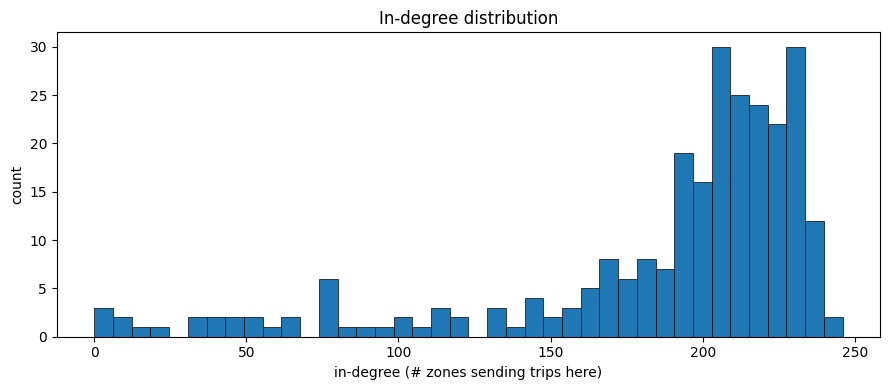

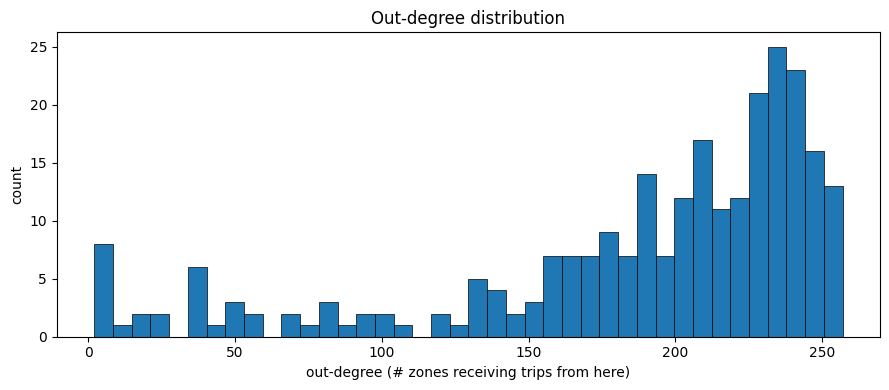

,LocationID,PageRank,Zone
0,236,0.024175,Upper East Side North
1,237,0.023658,Upper East Side South
2,161,0.021424,Midtown Center
3,170,0.017899,Murray Hill
4,230,0.017786,Times Sq/Theatre District
5,68,0.016770,East Chelsea
6,162,0.016759,Midtown East
7,239,0.016057,Upper West Side South
8,142,0.015965,Lincoln Square East
9,48,0.015276,Clinton East


In [14]:
# Confirm the graph is connected, not trivially dense, and has non uniform edge weights
import networkx as nx

od_all = (
    taxi_eda
    .groupby(["PULocationID", "DOLocationID"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

# build directed graph from OD pair count
G = nx.from_pandas_edgelist(
    od_all, "PULocationID", "DOLocationID",
    edge_attr="trip_count", create_using=nx.DiGraph()
)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
max_edges = n_nodes * (n_nodes - 1)
sparsity = n_edges / max_edges

print(f"Nodes: {n_nodes}")
print(f"Edges: {n_edges:,}")
print(f"Sparsity (edges / max possible): {sparsity:.2%}")
print(f"Weakly connected: {nx.is_weakly_connected(G)}")
print(f"Strongly connected: {nx.is_strongly_connected(G)}")

if not nx.is_weakly_connected(G):
    comps = list(nx.weakly_connected_components(G))
    print(f"Weakly connected components: {len(comps)}")
    print(f"Largest component size: {max(len(c) for c in comps)}")

# in degree distribution
in_deg = [d for _, d in G.in_degree()]
plt.figure(figsize=(9, 4))
plt.hist(in_deg, bins=40, edgecolor="black", linewidth=0.5)
plt.title("In-degree distribution")
plt.xlabel("in-degree (# zones sending trips here)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# out degree distribution
out_deg = [d for _, d in G.out_degree()]
plt.figure(figsize=(9, 4))
plt.hist(out_deg, bins=40, edgecolor="black", linewidth=0.5)
plt.title("Out-degree distribution")
plt.xlabel("out-degree (# zones receiving trips from here)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# PageRank sanity check
zone_id_to_name = zones.set_index("LocationID")["Zone"]

pr = nx.pagerank(G, weight="trip_count")
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]

pr_df = pd.DataFrame(top_pr, columns=["LocationID", "PageRank"])
pr_df["Zone"] = pr_df["LocationID"].map(zone_id_to_name)
display(pr_df)


The graph is weakly connected but 71% dense, meaning most zones have at least one trip to most other zones. This shows edge-weight thresholding will be needed to see community structure before running PPR sweep. The PageRank top 10 matches the top pickup zones from checkpoint 1.

### RQ1: PPR Community Detection

Threshold the full OD graph to remove weak edges, then run a Personalized PageRank sweep from the top-ranked seed zones to assign each zone to a community.

In [15]:
import networkx as nx
import pandas as pd

# keep only edges with enough trips
EDGE_MIN = 100   # raises sparsity from 71% to something useful
od_thresh = od_all[od_all["trip_count"] >= EDGE_MIN]

G_thresh = nx.from_pandas_edgelist(
    od_thresh, "PULocationID", "DOLocationID",
    edge_attr="trip_count", create_using=nx.DiGraph()
)
print(f"Thresholded graph: {G_thresh.number_of_nodes()} nodes, "
      f"{G_thresh.number_of_edges()} edges")


# PPR sweep for community detection
# assign each zone to the community whose seed gives it the highest PPR
G_und = G_thresh.to_undirected()  # PPR on undirected graph

# use high PageRank nodes as seeds
pr = nx.pagerank(G_thresh, weight="trip_count")
pr_series = pd.Series(pr).sort_values(ascending=False)

zone_lookup = pd.read_csv("data/nyc_tlc/misc/taxi_zone_lookup.csv")
pr_df = pr_series.reset_index()
pr_df.columns = ["LocationID", "pagerank"]
pr_df = pr_df.merge(zone_lookup[["LocationID",
  "Borough"]], on="LocationID", how="left")

seed_pool = pr_df[pr_df["LocationID"].isin(G_und.nodes())]
seed_idx = seed_pool.groupby("Borough")["pagerank"].idxmax()
seeds = seed_pool.loc[seed_idx, "LocationID"].tolist()
N_COMMUNITIES = len(seeds)
print(f"Seeds: {seeds}")

# run PPR from each seed
ppr_scores = {}
for seed in seeds:
    personalization = {n: (1.0 if n == seed else 0.0) for n in G_und.nodes()}
    ppr = nx.pagerank(G_und, personalization=personalization, weight="trip_count")
    ppr_scores[seed] = ppr

# assign each node to the seed it scores highest under
ppr_df = pd.DataFrame(ppr_scores)   # rows = zones, cols = seeds
community_labels = ppr_df.idxmax(axis=1).rename("community_seed")
community_map = community_labels.reset_index()
community_map.columns = ["LocationID", "community_seed"]

# map seed node IDs to integer community IDs for coloring
seed_to_int = {s: i for i, s in enumerate(seeds)}
community_map["community"] = community_map["community_seed"].map(seed_to_int)

print(community_map["community"].value_counts().sort_index())


Thresholded graph: 234 nodes, 7678 edges
Seeds: [168, 76, 1, 236, 130, 118, 264]
community
0    31
1    37
2    36
3    17
4    46
5    66
6     1
Name: count, dtype: int64


## Final analysis

The sections below are the cleaned up final versions of the deeper analysis. I kept the sections that best answer the three research questions and left the extra testing in the testing notebook. The section numbers match the full testing notebook, so some numbers are skipped here.


### 5.1 RQ1: OD Matrix Stats, Edge-Min Sweep, and Top-30 OD Pairs with Names

Before running PPR with all the diagnostics, we summarise the OD matrix and look at how many edges survive each candidate threshold. This motivates `EDGE_MIN = 100` (keeps roughly 25% of edges and gives a workable inter-borough graph). We then list the top-30 OD pairs with their human readable zone names.

In [16]:
# OD matrix stats, edge min sweep, and top 30 OD pairs with zone names
import networkx as nx
import numpy as np

# rebuild od_all just in case
od_all = (
    taxi_eda.groupby(["PULocationID", "DOLocationID"])
    .size().reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

print(f"OD pairs: {len(od_all):,}  |  Unique PU: {od_all['PULocationID'].nunique()}  "
      f"DO: {od_all['DOLocationID'].nunique()}")

s = od_all["trip_count"]
print(f"trip_count per OD pair: n={len(s):,}  mean={s.mean():.2f}  std={s.std():.2f}  "
      f"min={s.min()}  max={s.max()}")
print(f"  percentiles: " + "  ".join(
    f"p{p}={np.percentile(s, p):.0f}" for p in [25, 50, 75, 95, 99]))

print("\nPairs surviving each threshold:")
for thr in [1, 10, 50, 100, 250, 500, 1000, 2000, 5000]:
    kept = (od_all["trip_count"] >= thr).sum()
    print(f"  >= {thr:<5}  {kept:>6,}  ({kept/len(od_all)*100:.1f}%)")

# edge min sweep on the full graph
G_full = nx.from_pandas_edgelist(
    od_all, "PULocationID", "DOLocationID",
    edge_attr="trip_count", create_using=nx.DiGraph()
)
n_full, e_full = G_full.number_of_nodes(), G_full.number_of_edges()
print(f"\nFull graph: {n_full} nodes, {e_full:,} edges, density={e_full/(n_full*(n_full-1)):.4f}")

print("\nEDGE_MIN sweep:")
for thr in [50, 100, 250, 500, 1000]:
    od_t = od_all[od_all["trip_count"] >= thr]
    if len(od_t) < 2:
        print(f"  >= {thr}: too few edges"); continue
    Gt = nx.from_pandas_edgelist(od_t, "PULocationID", "DOLocationID",
                                 edge_attr="trip_count", create_using=nx.DiGraph())
    nt, et = Gt.number_of_nodes(), Gt.number_of_edges()
    print(f"  >= {thr:<5}  nodes={nt:>4}  edges={et:>6,}  "
          f"density={et/(nt*(nt-1)):.4f}  "
          f"pct_edges_kept={et/e_full*100:.1f}%")

# top 30 OD pairs with zone names
zone_id_to_name = zones.set_index("LocationID")["Zone"]
print("\nTop 30 OD pairs (with zone names):")
for _, row in od_all.head(30).iterrows():
    pu = zone_id_to_name.get(row["PULocationID"], f"ID={row['PULocationID']}")
    do = zone_id_to_name.get(row["DOLocationID"], f"ID={row['DOLocationID']}")
    print(f"  {row['PULocationID']:>4}->{row['DOLocationID']:<4}  "
          f"{pu:<35} -> {do:<35} {row['trip_count']:>8,}")

OD pairs: 48,877  |  Unique PU: 262  DO: 261
trip_count per OD pair: n=48,877  mean=309.30  std=1756.43  min=1  max=97619
  percentiles: p25=3  p50=11  p75=44  p95=1000  p99=7784

Pairs surviving each threshold:
  >= 1      48,877  (100.0%)
  >= 10     26,315  (53.8%)
  >= 50     11,445  (23.4%)
  >= 100     7,678  (15.7%)
  >= 250     4,741  (9.7%)
  >= 500     3,405  (7.0%)
  >= 1000    2,448  (5.0%)
  >= 2000    1,709  (3.5%)
  >= 5000      818  (1.7%)

Full graph: 262 nodes, 48,877 edges, density=0.7148

EDGE_MIN sweep:
  >= 50     nodes= 246  edges=11,445  density=0.1899  pct_edges_kept=23.4%
  >= 100    nodes= 234  edges= 7,678  density=0.1408  pct_edges_kept=15.7%
  >= 250    nodes= 207  edges= 4,741  density=0.1112  pct_edges_kept=9.7%
  >= 500    nodes= 178  edges= 3,405  density=0.1081  pct_edges_kept=7.0%
  >= 1000   nodes= 143  edges= 2,448  density=0.1206  pct_edges_kept=5.0%

Top 30 OD pairs (with zone names):
   237->236   Upper East Side South               -> Upper Eas

### 5.2 RQ1:  PageRank by Borough and PPR Confidence

The earlier PPR cell already produced `community_map` and `seeds`. Here we add two diagnostics:

1. **PageRank by borough:** mean and max PR per borough confirms that Manhattan zones dominate the global ranking, motivating the per-borough seed selection.
2. **PPR assignment confidence:** for every zone we compute the gap between its top-1 and top-2 PPR scores. Small margins show zones whose community label is ambiguous and could swap under small graph changes.

In [17]:
import networkx as nx
import numpy as np
import pandas as pd

# full graph PageRank by borough
pr = nx.pagerank(G_full, weight="trip_count")
pr_df = pd.Series(pr).reset_index()
pr_df.columns = ["LocationID", "PR"]
pr_df["Borough"] = pr_df["LocationID"].map(zones.set_index("LocationID")["Borough"])

print("PageRank by Borough:")
for b, g in pr_df.groupby("Borough"):
    print(f"  {str(b):<20}  mean={g['PR'].mean():.6f}  max={g['PR'].max():.6f}  n={len(g)}")

# PPR assignment confidence is the margin between top and second seed PPR
EDGE_MIN = 100
od_thresh = od_all[od_all["trip_count"] >= EDGE_MIN]
Gt = nx.from_pandas_edgelist(od_thresh, "PULocationID", "DOLocationID",
                             edge_attr="trip_count", create_using=nx.DiGraph())
G_und = Gt.to_undirected()

# picking seeds the same way as the earlier PPR cell
pr_t = nx.pagerank(Gt, weight="trip_count")
pr_t_df = pd.Series(pr_t).reset_index()
pr_t_df.columns = ["LocationID", "pagerank"]
pr_t_df = pr_t_df.merge(zones[["LocationID", "Borough"]], on="LocationID", how="left")
in_g = pr_t_df[pr_t_df["LocationID"].isin(G_und.nodes())]
in_g = in_g[in_g["Borough"].notna() & (in_g["Borough"] != "Unknown")]
seed_idx = in_g.groupby("Borough")["pagerank"].idxmax()
seeds_local = in_g.loc[seed_idx, "LocationID"].tolist()

ppr_scores = {}
for seed in seeds_local:
    pers = {n: (1.0 if n == seed else 0.0) for n in G_und.nodes()}
    ppr_scores[seed] = nx.pagerank(G_und, personalization=pers, weight="trip_count")

ppr_mat = pd.DataFrame(ppr_scores)
sorted_ppr = ppr_mat.apply(lambda row: sorted(row.values, reverse=True), axis=1)
margin = sorted_ppr.apply(lambda x: x[0] - x[1] if len(x) > 1 else x[0])

print(f"\nPPR margin (top - 2nd seed):")
print(f"  n={len(margin):,}  mean={margin.mean():.6f}  std={margin.std():.6f}  "
      f"min={margin.min():.6f}  max={margin.max():.6f}")
for p in [10, 25, 50, 75, 90]:
    print(f"  p{p}={np.percentile(margin, p):.6f}")
ambiguous = (margin < margin.quantile(0.10)).sum()
print(f"  Zones with margin < p10: {ambiguous} (ambiguous community membership)")

PageRank by Borough:
  Bronx                 mean=0.001398  max=0.002664  n=43
  Brooklyn              mean=0.002711  max=0.006843  n=61
  EWR                   mean=0.005850  max=0.005850  n=1
  Manhattan             mean=0.009098  max=0.024175  n=67
  Queens                mean=0.001968  max=0.007771  n=69
  Staten Island         mean=0.000803  max=0.001463  n=19
  Unknown               mean=0.002144  max=0.002144  n=1

PPR margin (top - 2nd seed):
  n=234  mean=0.006685  std=0.026095  min=0.000002  max=0.175144
  p10=0.000041
  p25=0.000111
  p50=0.001353
  p75=0.003233
  p90=0.006852
  Zones with margin < p10: 24 (ambiguous community membership)


Manhattan zones have around 6.5x higher mean PageRank than the Bronx or Staten Island. This confirms Manhattan's structural dominance in the OD flow graph. The PPR distribution shows the median top-vs-second-seed gap is only 0.0014, meaning most zones are assigned to a community with low confidence and could shift under small graph adjustments. The long tail (max=0.175) indicates a few zones are strongly connected to a single seed.

### 5.3 RQ1: Louvain Comparison and NMI vs Borough Labels

PPR is anchor-based so it produces communities that are interpretable, but it does not optimise modularity. Louvain is a algorithm that maximizes modularity without geographic anchors, so comparing the two answers two questions:

- Does PPR achieve modularity comparable to Louvain on the same graph?
- Does PPR / Louvain communities align with administrative borough labels?

In [18]:
import networkx as nx
import numpy as np
from sklearn.metrics import normalized_mutual_info_score

RANDOM_STATE = 412
EDGE_MIN = 100

try:
    from networkx.algorithms.community import louvain_communities
    from networkx.algorithms.community.quality import modularity as nx_modularity

    od_thresh_lv = od_all[od_all["trip_count"] >= EDGE_MIN]
    G_lv_dir = nx.from_pandas_edgelist(
        od_thresh_lv, "PULocationID", "DOLocationID",
        edge_attr="trip_count", create_using=nx.DiGraph()
    )
    G_lv = G_lv_dir.to_undirected()

    lv_comms = louvain_communities(G_lv, weight="trip_count", seed=RANDOM_STATE)
    lv_node_comm = {}
    for cid, comm_set in enumerate(lv_comms):
        for node in comm_set:
            lv_node_comm[node] = cid
    lv_n = len(lv_comms)
    lv_mod = nx_modularity(G_lv, lv_comms, weight="trip_count")
    print(f"Louvain: {lv_n} communities  modularity={lv_mod:.4f}")

    # restrict PPR community sets to the same graph
    ppr_comms_sets = []
    for cid in sorted(community_map["community"].unique()):
        s = (set(community_map.loc[community_map["community"] == cid, "LocationID"])
             & set(G_lv.nodes()))
        if s:
            ppr_comms_sets.append(s)
    try:
        ppr_mod = nx_modularity(G_lv, ppr_comms_sets, weight="trip_count")
        print(f"PPR:     {len(ppr_comms_sets)} communities  modularity={ppr_mod:.4f}")
    except Exception as ex:
        ppr_mod = float("nan")
        print(f"PPR modularity could not be done: {ex}")

    if not np.isnan(ppr_mod):
        if lv_mod > ppr_mod:
            print(f"  Louvain modularity is higher ({lv_mod:.4f} > {ppr_mod:.4f}), ")
        else:
            print(f"  PPR modularity is comparable/higher ({ppr_mod:.4f} >= {lv_mod:.4f});")

    # compare PPR, Louvain, and borough labels using NMI
    common_nodes = sorted(set(community_map["LocationID"]) & set(lv_node_comm.keys()))
    ppr_vec = community_map.set_index("LocationID").loc[common_nodes, "community"].values
    lv_vec  = np.array([lv_node_comm[n] for n in common_nodes])
    borough_ser = zones.set_index("LocationID")["Borough"]
    borough_codes = {b: i for i, b in enumerate(sorted(borough_ser.dropna().unique()))}
    boro_vec = np.array([borough_codes.get(borough_ser.get(n), -1) for n in common_nodes])
    valid = boro_vec >= 0

    nmi_ppr_lv   = normalized_mutual_info_score(ppr_vec, lv_vec)
    nmi_ppr_boro = normalized_mutual_info_score(ppr_vec[valid], boro_vec[valid])
    nmi_lv_boro  = normalized_mutual_info_score(lv_vec[valid],  boro_vec[valid])
    print(f"\nNMI (1.0=identical, 0=independent):")
    print(f"  NMI(PPR,    Louvain) = {nmi_ppr_lv:.4f}")
    print(f"  NMI(PPR,    Borough) = {nmi_ppr_boro:.4f}")
    print(f"  NMI(Louvain,Borough) = {nmi_lv_boro:.4f}")
except ImportError:
    print("networkx louvain_communities not available, skipping Louvain comparison.")
except Exception as ex:
    print(f"Louvain comparison failed: {ex}")

Louvain: 6 communities  modularity=0.2552
PPR:     7 communities  modularity=0.2206
  Louvain modularity is higher (0.2552 > 0.2206), 

NMI (1.0=identical, 0=independent):
  NMI(PPR,    Louvain) = 0.5268
  NMI(PPR,    Borough) = 0.6014
  NMI(Louvain,Borough) = 0.4611


Louvain achieves slightly higher modularity (0.2552 vs 0.2206) since it directly optimizes that objective, while PPR with borough seeds aligns more closely with administrative boroughs (NMI=0.60 vs Louvain's 0.46). The moderate NMI(PPR, Louvain)=0.53 indicates substantial overlap but real differences — seeded PPR pulls zones toward borough anchors in ways that pure modularity optimization does not.

### 5.5 RQ1: Time of Day Community Detection (Morning / Midday / Evening / Overnight)

Split the data into four time slices and re-run PPR on each. This tests whether community structure is stable across the day or whether commute patterns reshape them. We use a lower edge threshold (`TIME_SLICE_EDGE_MIN = 50`) since each slice has fewer trips.

In [19]:
import pandas as pd

TIME_SLICE_EDGE_MIN = 50

def build_ppr_communities_local(od_df, edge_min, zones, zone_id_to_name, label=""):
    """
    - Threshold OD, pick top-PR-per-borough seeds, run PPR.
    - returns (cmap, seeds, n_comm).
    """
    od_t = od_df[od_df["trip_count"] >= edge_min]
    if len(od_t) == 0:
        print(f"  [{label}] No edges at edge_min={edge_min}")
        return None
    G_t = nx.from_pandas_edgelist(od_t, "PULocationID", "DOLocationID",
                                  edge_attr="trip_count", create_using=nx.DiGraph())
    G_und = G_t.to_undirected()
    n2, e2 = G_t.number_of_nodes(), G_t.number_of_edges()
    print(f"  [{label}] edge_min={edge_min}: {n2} nodes  {e2:,} edges  "
          f"density={e2/(n2*(n2-1)) if n2>1 else 0:.4f}")
    pr2 = nx.pagerank(G_t, weight="trip_count")
    pr2_df = pd.Series(pr2).reset_index()
    pr2_df.columns = ["LocationID", "pagerank"]
    pr2_df = pr2_df.merge(zones[["LocationID", "Borough"]], on="LocationID", how="left")
    in_graph = pr2_df[pr2_df["LocationID"].isin(G_und.nodes())]
    valid_seeds_pool = in_graph[in_graph["Borough"].notna()
                                & (in_graph["Borough"] != "Unknown")]
    seed_idx = valid_seeds_pool.groupby("Borough")["pagerank"].idxmax()
    seeds_df = valid_seeds_pool.loc[seed_idx]
    seeds = seeds_df["LocationID"].tolist()
    ppr_scores = {}
    for seed in seeds:
        pers = {nd: (1.0 if nd == seed else 0.0) for nd in G_und.nodes()}
        ppr_scores[seed] = nx.pagerank(G_und, personalization=pers, weight="trip_count")
    ppr_mat = pd.DataFrame(ppr_scores)
    cmap = ppr_mat.idxmax(axis=1).rename("community_seed").reset_index()
    cmap.columns = ["LocationID", "community_seed"]
    seed_to_int = {s: i for i, s in enumerate(seeds)}
    cmap["community"] = cmap["community_seed"].map(seed_to_int)
    cmap["Zone"]    = cmap["LocationID"].map(zone_id_to_name)
    cmap["Borough"] = cmap["LocationID"].map(zones.set_index("LocationID")["Borough"])
    return cmap, seeds, len(seeds)

slices = {
    "morning":   list(range(6, 11)),
    "midday":    list(range(11, 17)),
    "evening":   list(range(17, 22)),
    "overnight": list(range(22, 24)) + list(range(0, 6)),
}

slice_maps = {}
slice_seeds = {}
for sname, hours in slices.items():
    slice_df = taxi_eda[taxi_eda["pickup_hour"].isin(hours)]
    n_trips = len(slice_df)
    print(f"\n[{sname}]  hours={hours}  trips={n_trips:,}")
    od_slice = (slice_df.groupby(["PULocationID", "DOLocationID"])
                        .size().reset_index(name="trip_count"))
    result = build_ppr_communities_local(od_slice, TIME_SLICE_EDGE_MIN,
                                          zones, zone_id_to_name, label=sname)
    if result is None:
        continue
    cmap_s, seeds_s, n_comm_s = result
    slice_maps[sname] = cmap_s
    slice_seeds[sname] = seeds_s
    sizes = cmap_s["community"].value_counts().sort_index()
    print(f"  Communities: {n_comm_s}   Zones assigned: {len(cmap_s)}")
    print(f"  Sizes: {sizes.to_dict()}")
    print(f"  Borough x community:\n{pd.crosstab(cmap_s['community'], cmap_s['Borough']).to_string()}")


[morning]  hours=[6, 7, 8, 9, 10]  trips=2,522,909
  [morning] edge_min=50: 205 nodes  4,289 edges  density=0.1026
  Communities: 5   Zones assigned: 205
  Sizes: {0: 33, 1: 47, 2: 26, 3: 28, 4: 71}
  Borough x community:
Borough    Bronx  Brooklyn  EWR  Manhattan  Queens  Unknown
community                                                  
0             20         0    0         12       1        0
1              0        45    0          0       2        0
2              0         1    1         24       0        0
3              0         0    0         26       1        1
4              4         8    0          1      57        0

[midday]  hours=[11, 12, 13, 14, 15, 16]  trips=4,941,426
  [midday] edge_min=50: 218 nodes  5,309 edges  density=0.1122
  Communities: 6   Zones assigned: 218
  Sizes: {0: 19, 1: 47, 2: 26, 3: 20, 4: 94, 5: 12}
  Borough x community:
Borough    Bronx  Brooklyn  EWR  Manhattan  Queens  Staten Island  Unknown
community                                     

### 5.6 RQ1: ARI Across Time Slices and Zone Stability

ARI compares the timeslice partitions without caring about the actual label values. This cell checks whether the morning, midday, evening, and overnight community assignments are similar, then lists the zones with the most movement across communities.


In [20]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score

slice_names = list(slice_maps.keys())
all_zones = sorted(set().union(*[set(m["LocationID"]) for m in slice_maps.values()]))

# build zone to community vectors per slice
vectors = {}
for sname, cmap_s in slice_maps.items():
    z2c = cmap_s.set_index("LocationID")["community"]
    vectors[sname] = pd.Series([z2c.get(z, -1) for z in all_zones], index=all_zones)

print("ARI matrix:")
print("  " + " " * 10 + "".join(f"  {s[:8]:>8}" for s in slice_names))
for s1 in slice_names:
    row_str = f"  {s1[:12]:<12}"
    for s2 in slice_names:
        if s1 == s2:
            row_str += "  {:>8.4f}".format(1.0)
        else:
            v1 = vectors[s1].values
            v2 = vectors[s2].values
            mask = (v1 >= 0) & (v2 >= 0)
            row_str += "  {:>8}".format("N/A") if mask.sum() < 10 else "  {:>8.4f}".format(adjusted_rand_score(v1[mask], v2[mask]))
    print(row_str)

# zone stability across time slices
stability = pd.DataFrame(vectors)
fully_present = stability[(stability >= 0).all(axis=1)]
print(f"\nZones in all slices: {len(fully_present)}")
if len(fully_present) > 0:
    instability = fully_present.apply(lambda row: row.nunique(), axis=1)
    print(f"Instability distribution: {instability.value_counts().sort_index().to_dict()}")

    print("\nMost unstable zones:")
    for loc_id, inst in instability.sort_values(ascending=False).head(10).items():
        zname = zone_id_to_name.get(loc_id, f"ID={loc_id}")
        print(f"  {loc_id:>4}  {zname:<35}  {inst} communities")

    stable = instability[instability == 1].index
    print(f"Stable zones: {len(stable)}")


ARI matrix:
               morning    midday   evening  overnigh
  morning         1.0000    0.4563    0.3486    0.4406
  midday          0.4563    1.0000    0.4110    0.3983
  evening         0.3486    0.4110    1.0000    0.4764
  overnight       0.4406    0.3983    0.4764    1.0000

Zones in all slices: 200
Instability distribution: {1: 51, 2: 98, 3: 47, 4: 4}

Most unstable zones:
    40  Carroll Gardens                      4 communities
    52  Cobble Hill                          4 communities
   242  Van Nest/Morris Park                 4 communities
   119  Highbridge                           4 communities
    22  Bensonhurst West                     3 communities
    18  Bedford Park                         3 communities
     4  Alphabet City                        3 communities
    13  Battery Park City                    3 communities
    55  Coney Island                         3 communities
    79  East Village                         3 communities
Stable zones: 51


The morning–evening pair is the least similar (ARI=0.35), showing that the commute direction reversal reshapes community membership. All ARI values fall within a range of 0.35 to 0.48. This means communities are somewhat stable but can shift in places across the day. Of 200 zones present in every slice, 51 keep the same community all day, 98 switch once, 47 switch twice, and 4 zones (Carroll Gardens, Cobble Hill, Van Nest/Morris Park, Highbridge) land in a different community in every slice. These are boundary zones that bridge multiple communities depending on time of day.

### 5.7 RQ1: Time Slice Community Maps

These maps show the four time slice PPR communities in two ways: a geographic map when the shapefile is available, and a spring layout network plot as a fallback.


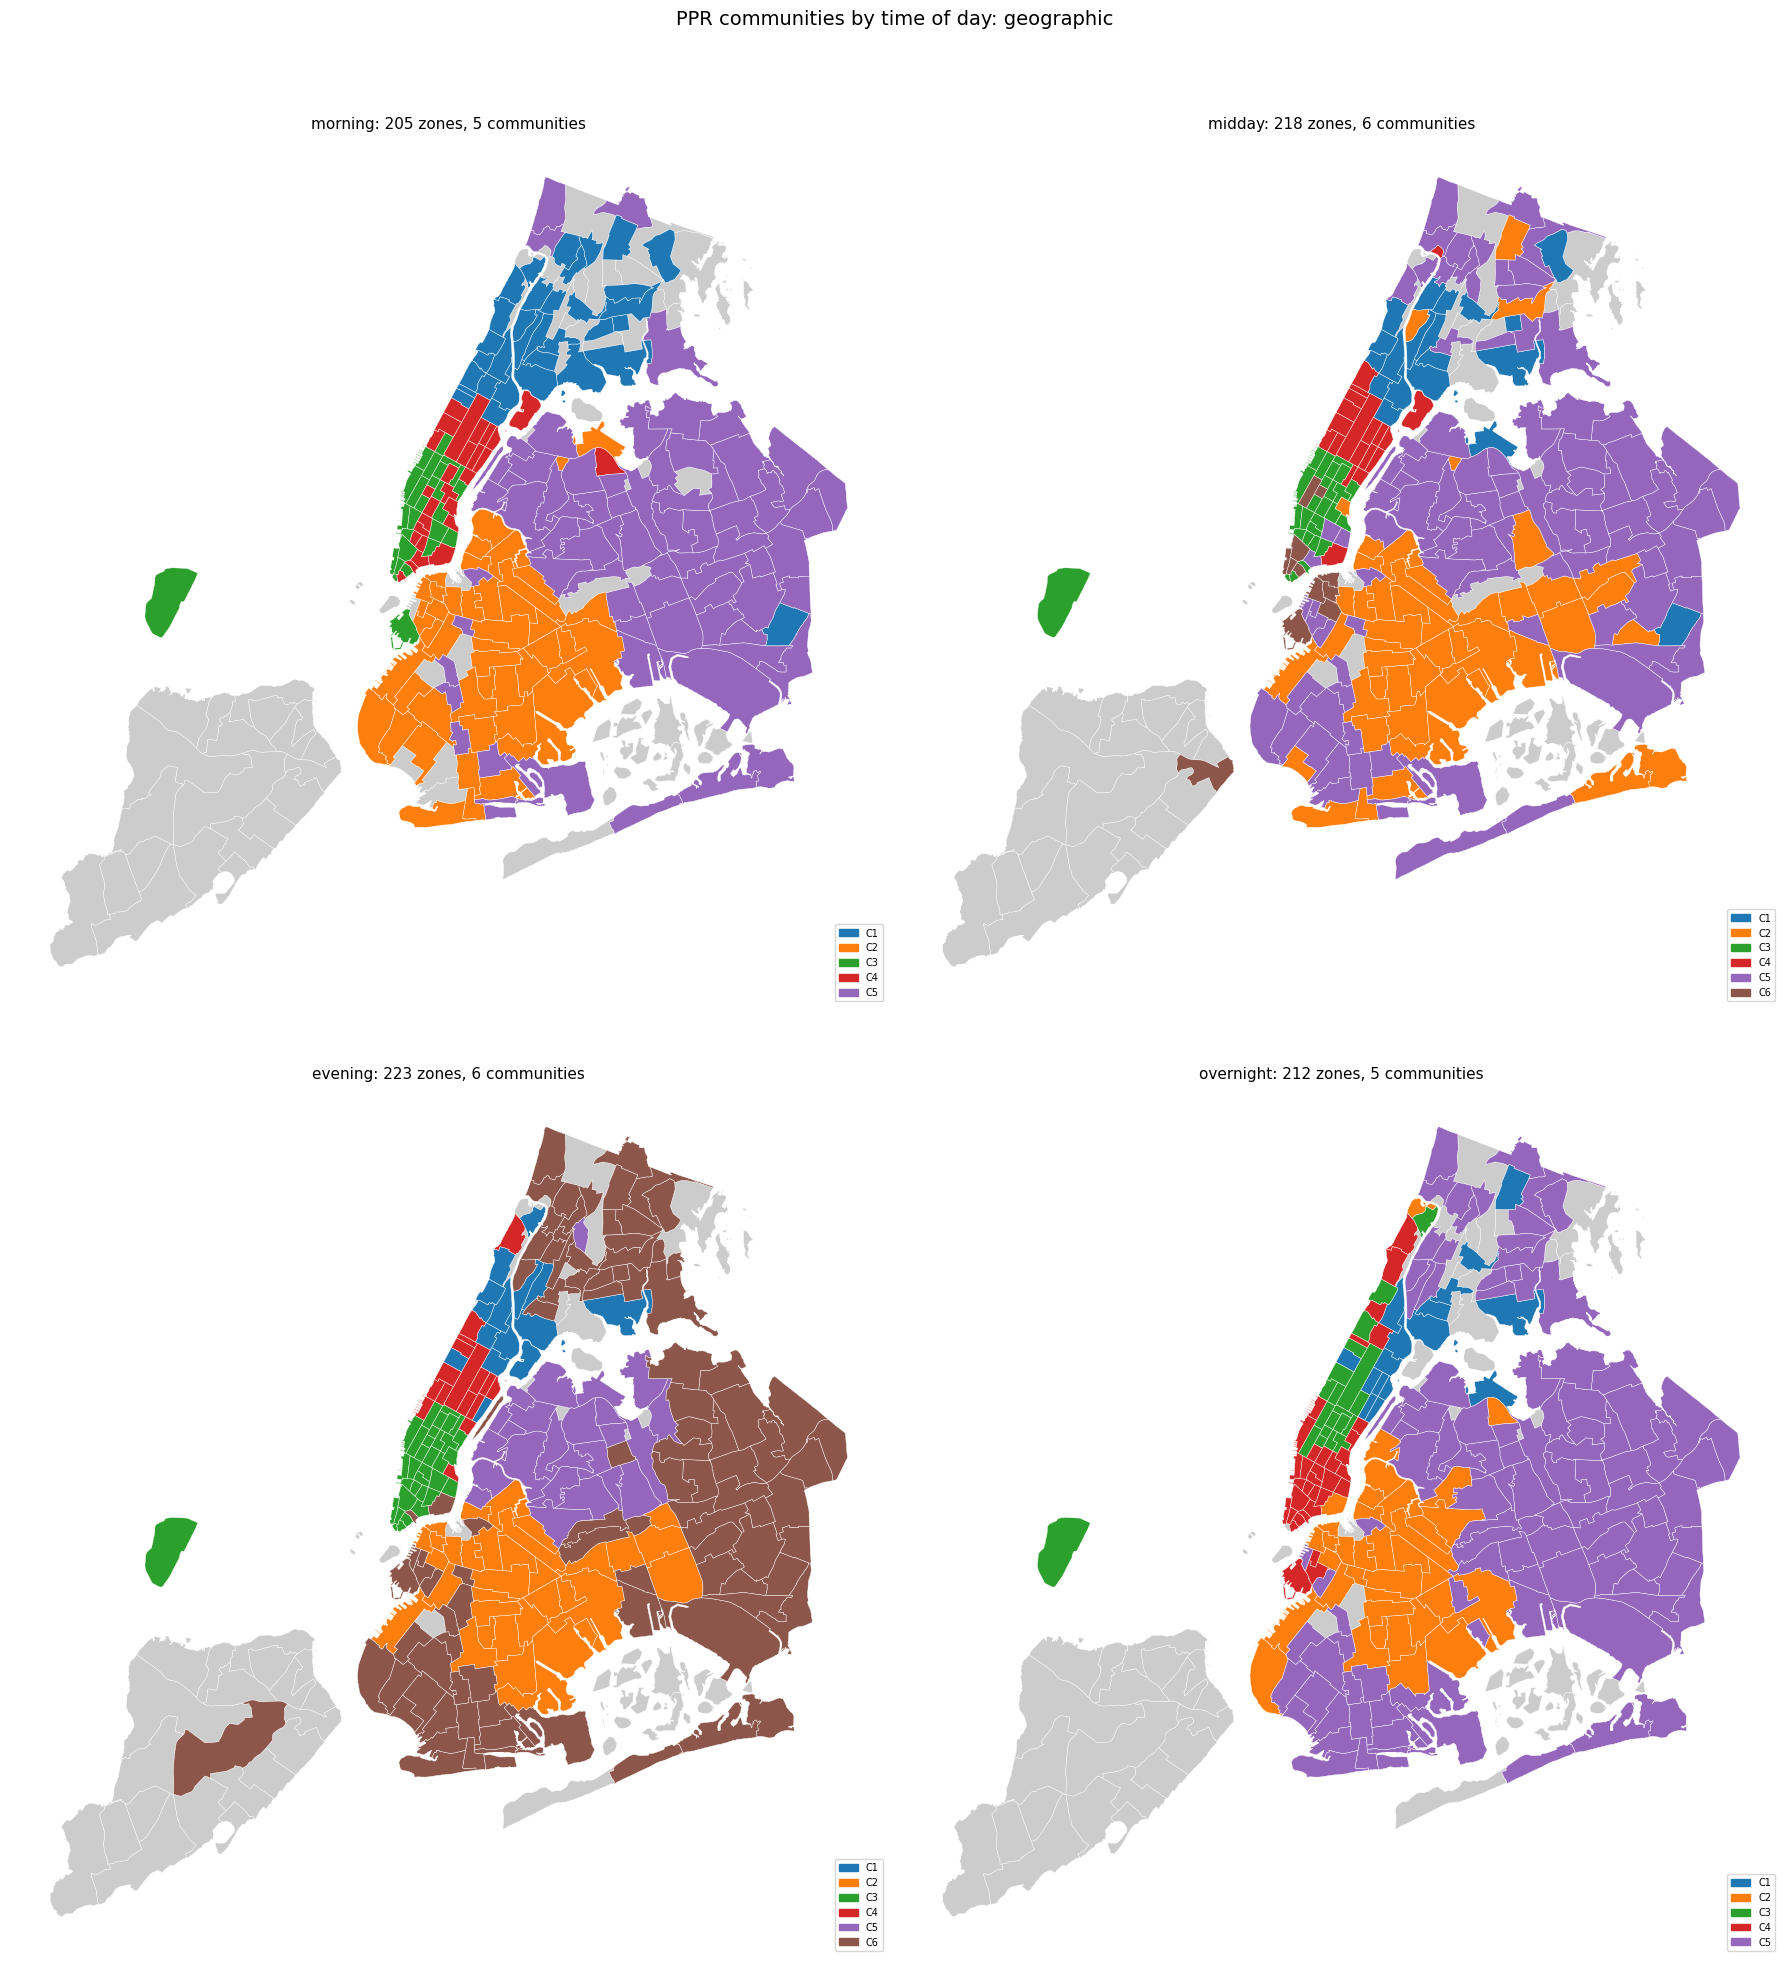

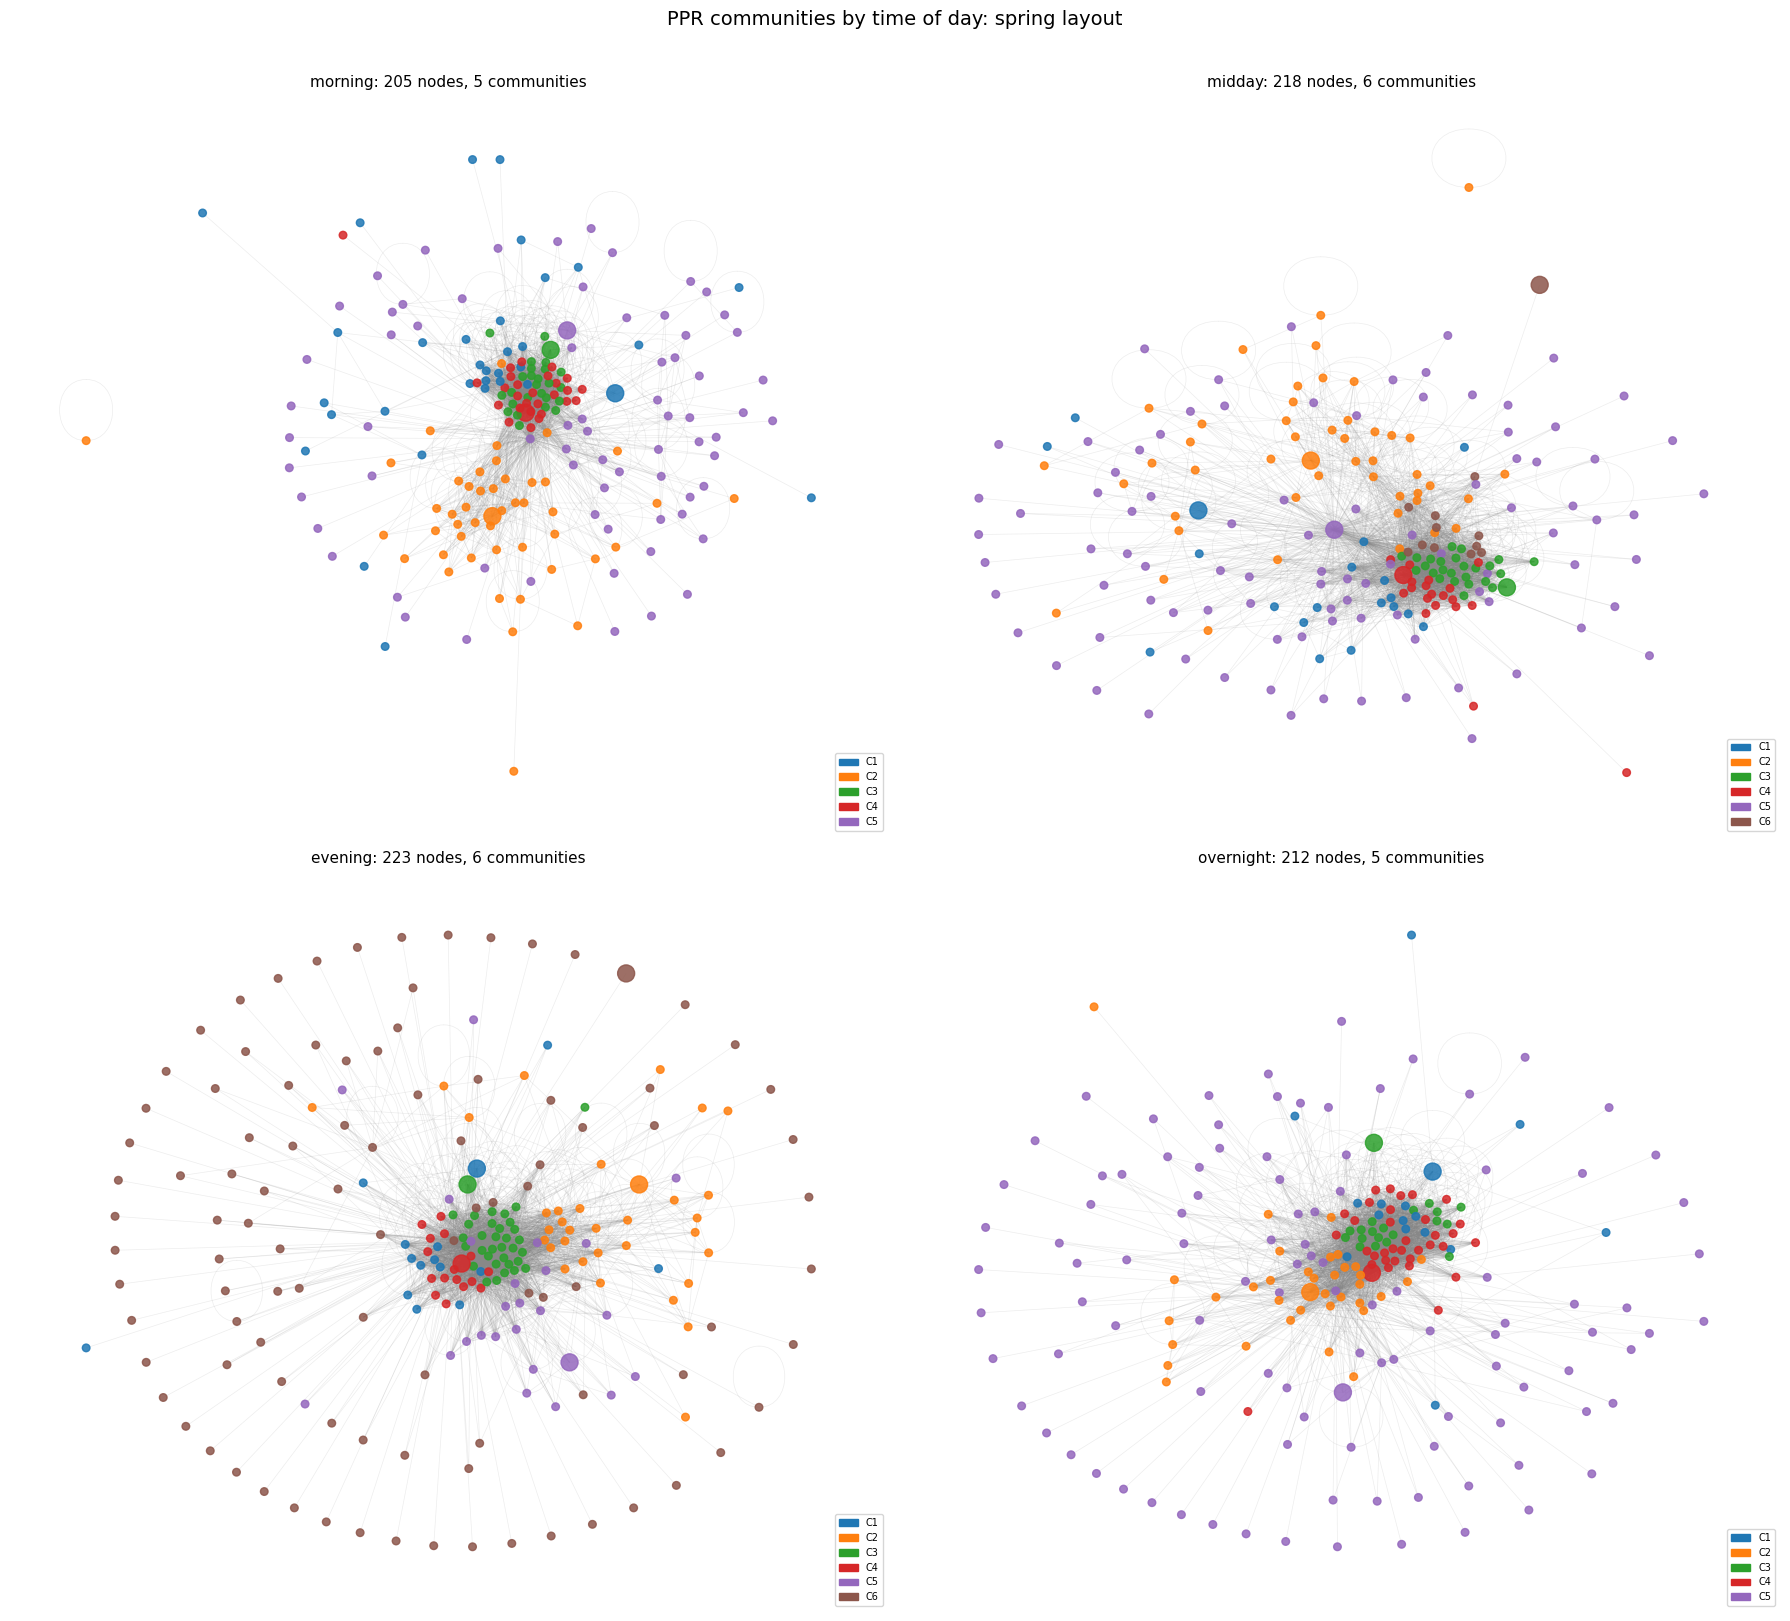

In [21]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import networkx as nx

slice_order = ["morning", "midday", "evening", "overnight"]

# geographic map
try:
    import geopandas as gpd

    shp_dir_candidates = [
        Path("data/nyc_tlc/misc/taxi_zones"),
        Path("/content/taxi_zones"),
    ]
    shp_path = None
    for d in shp_dir_candidates:
        if d.exists():
            for root, _, files in os.walk(d):
                for fn in files:
                    if fn.endswith(".shp"):
                        shp_path = Path(root) / fn
                        break
                if shp_path:
                    break
        if shp_path:
            break
    if shp_path is None:
        raise FileNotFoundError("taxi_zones shapefile not found")

    zones_gdf = gpd.read_file(str(shp_path))
    zones_gdf["LocationID"] = zones_gdf["LocationID"].astype(int)

    fig_a, axes_a = plt.subplots(2, 2, figsize=(18, 20))
    axes_a_flat = axes_a.flatten()
    for idx, sname in enumerate(slice_order):
        ax_a = axes_a_flat[idx]
        if sname not in slice_maps:
            ax_a.set_title(f"{sname}\n(no data)"); ax_a.axis("off"); continue
        cmap_s = slice_maps[sname]
        max_comm = cmap_s["community"].max() + 1
        COLORS = [cm.tab10(i % 10) for i in range(max_comm)]
        zplot = zones_gdf.merge(cmap_s[["LocationID", "community"]],
                                on="LocationID", how="left")
        zplot["community"] = zplot["community"].fillna(-1).astype(int)
        for cid_s, grp_s in zplot.groupby("community"):
            color = COLORS[cid_s] if 0 <= cid_s < len(COLORS) else "#cccccc"
            grp_s.plot(ax=ax_a, color=color, edgecolor="white", linewidth=0.3)
        patches = [mpatches.Patch(color=COLORS[i], label=f"C{i+1}")
                   for i in range(max_comm)]
        ax_a.legend(handles=patches, loc="lower right", fontsize=7)
        ax_a.set_title(f"{sname}: {len(cmap_s)} zones, {max_comm} communities", fontsize=11)
        ax_a.axis("off")
    fig_a.suptitle("PPR communities by time of day: geographic", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Skipping geographic map: geopandas is not installed.")
except Exception as ex:
    print(f"Skipping geographic map: {ex}")

# spring layout map
try:
    fig_b, axes_b = plt.subplots(2, 2, figsize=(18, 16))
    axes_b_flat = axes_b.flatten()
    for idx, sname in enumerate(slice_order):
        ax_b = axes_b_flat[idx]
        if sname not in slice_maps:
            ax_b.set_title(f"{sname}\n(no data)"); ax_b.axis("off"); continue
        cmap_s = slice_maps[sname]
        seeds_s = slice_seeds[sname]
        slice_hours = slices[sname]
        slice_df_b = taxi_eda[taxi_eda["pickup_hour"].isin(slice_hours)]
        od_slice_b = (slice_df_b.groupby(["PULocationID", "DOLocationID"])
                                .size().reset_index(name="trip_count"))
        od_t_b = od_slice_b[od_slice_b["trip_count"] >= TIME_SLICE_EDGE_MIN]
        if len(od_t_b) < 2:
            ax_b.set_title(f"{sname}\n(too few edges)"); ax_b.axis("off"); continue
        G_slice = nx.from_pandas_edgelist(od_t_b, "PULocationID", "DOLocationID",
                                           edge_attr="trip_count",
                                           create_using=nx.Graph())
        comm_lookup = cmap_s.set_index("LocationID")["community"]
        max_comm_b = cmap_s["community"].max() + 1
        COLORS_B = [cm.tab10(i % 10) for i in range(max_comm_b)]
        node_colors = [
            COLORS_B[int(comm_lookup.get(n, -1))]
            if comm_lookup.get(n, -1) >= 0 else "#cccccc"
            for n in G_slice.nodes()
        ]
        node_sizes = [150 if n in seeds_s else 30 for n in G_slice.nodes()]
        pos = nx.spring_layout(G_slice, seed=412, k=0.3)
        nx.draw_networkx_nodes(G_slice, pos, ax=ax_b,
                               node_color=node_colors,
                               node_size=node_sizes, alpha=0.85)
        nx.draw_networkx_edges(G_slice, pos, ax=ax_b, alpha=0.15,
                               width=0.5, edge_color="#888888")
        patches = [mpatches.Patch(color=COLORS_B[i], label=f"C{i+1}")
                   for i in range(max_comm_b)]
        ax_b.legend(handles=patches, loc="lower right", fontsize=7)
        ax_b.set_title(f"{sname}: {G_slice.number_of_nodes()} nodes, {max_comm_b} communities", fontsize=11)
        ax_b.axis("off")
    fig_b.suptitle("PPR communities by time of day: spring layout", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
except Exception as ex:
    print(f"Skipping spring layout map: {ex}")


### RQ1 takeaway

The OD graph is dense enough that raw edges are not very informative, so thresholding and seeded PageRank are needed. The time slice analysis is the main result because it checks whether community assignments change between morning, midday, evening, and overnight taxi flows.


### 5.8 RQ2: Enriched Outlier Features and K-Means Sweep

The quick checkpoint run used a few raw features. Here I add log features, capped speed, fare-per-mile, time flags, borough code, and payment code, then sweep k-means from k = 2..10.


Outlier rows used: 174,677; sample: 50,000; features: 13
k-means sweep:
  k= 2  silhouette=0.2403
  k= 3  silhouette=0.2574
  k= 4  silhouette=0.2073
  k= 5  silhouette=0.1834
  k= 6  silhouette=0.2428
  k= 7  silhouette=0.2186
  k= 8  silhouette=0.2409
  k= 9  silhouette=0.2607
  k=10  silhouette=0.2596
Best k by silhouette: 9


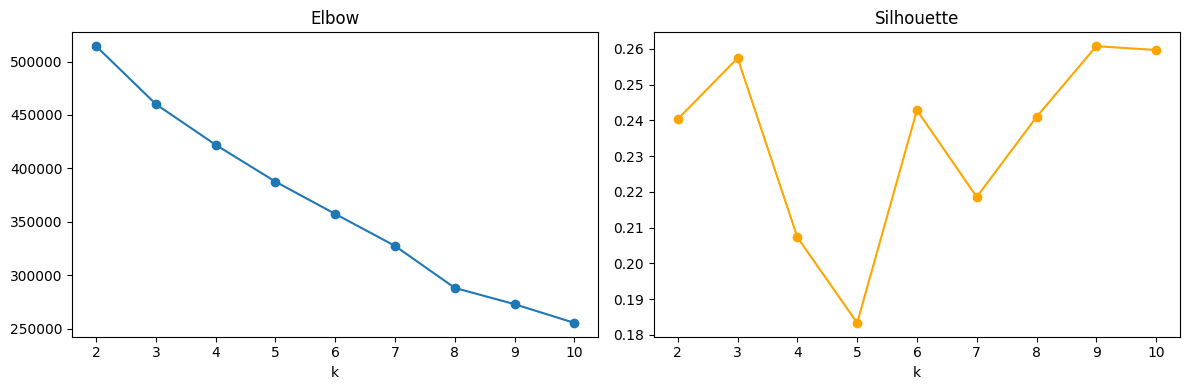

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 412

df = outliers.copy()
df["speed_capped"]      = df["speed_mph"].clip(0, 200)
df["log_speed"]         = np.log1p(df["speed_capped"])
df["log_distance"]      = np.log1p(df["trip_distance"])
df["log_fare"]          = np.log1p(df["fare_amount"].clip(0))
df["fare_per_mile"]     = np.where(df["trip_distance"] > 0,
                                   df["fare_amount"] / df["trip_distance"], 0.0)
df["log_fare_per_mile"] = np.log1p(df["fare_per_mile"].clip(0, 500))
df["is_zero_distance"]  = (df["trip_distance"] == 0).astype(int)
df["is_zero_fare"]      = (df["fare_amount"] == 0).astype(int)
df["is_night"]          = df["pickup_hour"].isin([22,23,0,1,2,3,4,5]).astype(int)
df["is_rush"]           = df["pickup_hour"].isin([7,8,9,17,18,19]).astype(int)
borough_codes = {"Manhattan":0,"Queens":1,"Brooklyn":2,"Bronx":3,"Staten Island":4,"EWR":5}
df["pu_borough_code"]   = df["PU_Borough"].map(borough_codes).fillna(-1)
df["payment_code"]      = pd.to_numeric(df["payment_type"], errors="coerce").fillna(-1)

if df["pickup_dow"].dtype == object:
    dow_map = {"Monday":0,"Tuesday":1,"Wednesday":2,"Thursday":3,
               "Friday":4,"Saturday":5,"Sunday":6}
    df["pickup_dow"] = df["pickup_dow"].map(dow_map).fillna(-1)

feat_cols = [
    "log_distance","trip_duration_min","log_fare","log_speed","log_fare_per_mile",
    "is_zero_distance","is_zero_fare","pickup_hour","pickup_dow",
    "is_night","is_rush","pu_borough_code","payment_code",
]
clean_df = df.dropna(subset=["log_distance","trip_duration_min","log_fare","log_speed"])
sample_n = min(50_000, len(clean_df))
sample = clean_df.sample(sample_n, random_state=RANDOM_STATE).copy()
X = StandardScaler().fit_transform(sample[feat_cols])

print(f"Outlier rows used: {len(clean_df):,}; sample: {sample_n:,}; features: {len(feat_cols)}")

k_values = [2,3,4,5,6,7,8,9,10]
inertias, sils = [], []
print("k-means sweep:")
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=10_000, random_state=RANDOM_STATE)
    sils.append(sil)
    print(f"  k={k:>2}  silhouette={sil:.4f}")

best_k = k_values[sils.index(max(sils))]
print(f"Best k by silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker="o"); axes[0].set_title("Elbow")
axes[0].set_xlabel("k"); axes[0].set_xticks(k_values)
axes[1].plot(k_values, sils, marker="o", color="orange"); axes[1].set_title("Silhouette")
axes[1].set_xlabel("k"); axes[1].set_xticks(k_values)
plt.tight_layout()
plt.show()


The silhouette is noisy (range 0.18–0.26), which is expected for an outlier tail that lacks good clusters. k=9 wins by only a small margin over k=3 and k=10. The cluster count should be interpreted loosely. The clustering is more useful as a way to label different types of unusual trips than evidence that these groups exist cleanly within the data.

### 5.9 RQ2: Cluster Profiles and Geographic Distribution

This fits k-means with the silhouette-selected `best_k`. The cluster names are descriptive labels for candidate irregularity types, not confirmed fraud labels.


In [23]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
sample["cluster"] = km.fit_predict(X)
sizes = sample["cluster"].value_counts().sort_index()
print(f"Cluster sizes: {sizes.to_dict()}")

profile_cols = ["trip_distance","trip_duration_min","fare_amount","speed_capped",
                "fare_per_mile","is_zero_distance","is_zero_fare","pickup_hour"]
avail = [c for c in profile_cols if c in sample.columns]
print("\nCluster means:")
print(sample.groupby("cluster")[avail].mean().round(2).to_string())

means4 = sample.groupby("cluster")[["trip_distance","trip_duration_min","fare_amount",
                                      "speed_capped","is_zero_distance","is_zero_fare",
                                      "fare_per_mile"]].mean()
cluster_labels = {}
print("\nCluster labels:")
for cid in sorted(sample["cluster"].unique()):
    r = means4.loc[cid]
    if r["trip_distance"] > 500 or r["trip_duration_min"] > 500:
        label = "GHOST DATA"
    elif r["is_zero_distance"] > 0.8 and r["is_zero_fare"] < 0.1:
        label = "PHANTOM TRIPS"
    elif r["is_zero_fare"] > 0.5:
        label = "CANCELLED/FREE RIDES"
    elif r["fare_per_mile"] > 500 and r["speed_capped"] > 20:
        label = "OVERCHARGED SHORTS"
    else:
        label = "MIXED ANOMALIES"
    cluster_labels[cid] = label
    n = (sample["cluster"] == cid).sum()
    print(f"  {cid}: {label} ({n:,}, {n/len(sample)*100:.1f}%)")

print("\nTop pickup zones per cluster:")
zone_col = "PU_Zone" if "PU_Zone" in sample.columns else "PULocationID"
for cid in sorted(sample["cluster"].unique()):
    cl = sample[sample["cluster"] == cid]
    top_zones = cl[zone_col].value_counts().head(5)
    print(f"  cluster {cid} ({cluster_labels.get(cid, cid)}): " + "; ".join(f"{z}={n}" for z, n in top_zones.items()))


Cluster sizes: {0: 15488, 1: 807, 2: 4372, 3: 891, 4: 8463, 5: 8212, 6: 7103, 7: 3478, 8: 1186}

Cluster means:
         trip_distance  trip_duration_min  fare_amount  speed_capped  fare_per_mile  is_zero_distance  is_zero_fare  pickup_hour
cluster                                                                                                                         
0                 0.00               1.96        40.91          0.00           0.02              1.00           0.0        15.83
1                 0.48              12.86        70.19          3.04         229.66              0.88           0.0        14.34
2                 0.04               2.71        39.55          0.09           0.12              0.99           0.0         2.02
3                 1.66               7.63         0.00         14.14           0.00              0.46           1.0        13.61
4                 0.10               4.79        48.79         23.14        1857.84              0.00           0.

The 9 clusters separate primarily along zero-distance trips, fare irregularities, and speed extremes. Clusters 0 and 1 are the most anomalous (zero distance with $40+ fare or very short distance with fare_per_mile ~230). Clusters 2, 4, and 6 represent normal trips at progressively longer distance groups. Cluster 3 likely shows traffic-heavy or meter-running trips. Cluster 7 has typical distance but unusually high fare. These separations motivate the fare comparison in the next section.

### 5.10 RQ2: Expected vs Actual Fare Analysis

For the high-fare short-distance cluster, this compares actual fare to a simple expected fare estimate. Airport zones are excluded because they often use flat rates or toll-heavy pricing.


In [24]:
overcharge_cid = next(
    (cid for cid, lbl in cluster_labels.items() if "OVERCHARGED SHORTS" in lbl), None
)
if overcharge_cid is not None:
    cluster3 = sample[(sample["cluster"] == overcharge_cid)
                      & (sample["trip_distance"] > 0)].copy()
    if len(cluster3) > 0:
        AIRPORT_ZONES = {132, 138, 1}  # JFK, LGA, Newark
        n_total_c3 = len(cluster3)
        if "DOLocationID" in cluster3.columns:
            mask_metered = (~cluster3["PULocationID"].isin(AIRPORT_ZONES)
                            & ~cluster3["DOLocationID"].isin(AIRPORT_ZONES))
        else:
            mask_metered = ~cluster3["PULocationID"].isin(AIRPORT_ZONES)
        cluster3_metered = cluster3[mask_metered].copy()
        n_metered_c3 = len(cluster3_metered)

        cluster3_metered["expected_fare"] = 3.00 + 3.50 * cluster3_metered["trip_distance"]
        cluster3_metered["overcharge"] = cluster3_metered["fare_amount"] - cluster3_metered["expected_fare"]

        mean_expected   = cluster3_metered["expected_fare"].mean()
        mean_actual     = cluster3_metered["fare_amount"].mean()
        mean_overcharge = cluster3_metered["overcharge"].mean()
        pct_over5       = (cluster3_metered["overcharge"] > 5).mean() * 100

        print(f"Metered trips analyzed: {n_metered_c3:,} of {n_total_c3:,}")
        print(f"Expected fare: ${mean_expected:.2f}; actual fare: ${mean_actual:.2f}")
        print(f"Mean amount above estimate: ${mean_overcharge:.2f}; >$5 above estimate: {pct_over5:.1f}%")
    else:
        print(f"No positive distance trips in cluster {overcharge_cid}.")
else:
    print("No overcharged shorts cluster found.")


Metered trips analyzed: 5,798 of 8,463
Expected fare: $3.40; actual fare: $43.21
Mean amount above estimate: $39.81; >$5 above estimate: 66.0%


Within the 8,463 short-distance high-fare trips, 5,798 had a standard metered rate and could be compared against an expected fare estimate. The mean expected fare is $3.40 but the mean actual fare is $43.21 — a difference of $39.81. 66% of these trips charged more than $5 above the estimate. Airport zones were excluded since they use flat-rate or toll-heavy pricing, so this result applies to non-airport metered trips only. This does not confirm fraud, but the gap between expected and actual fare in this cluster is large enough to warrant further validation. The expected fare is a simplified estimate using a hardcoded rate of $3.00 + $3.50×distance, ignoring time-based charges, surcharges, and tolls, so it likely understates the fair fare and the true overcharge gap may be smaller.

### 5.11 RQ2: Cluster Stability Bootstrap

This refits k-means on repeated 80% subsamples and compares each result to the original labels with ARI. Higher ARI means the cluster structure is more stable.


Bootstrap ARI: mean=0.805, std=0.041, min=0.769, max=0.973
Stability: high


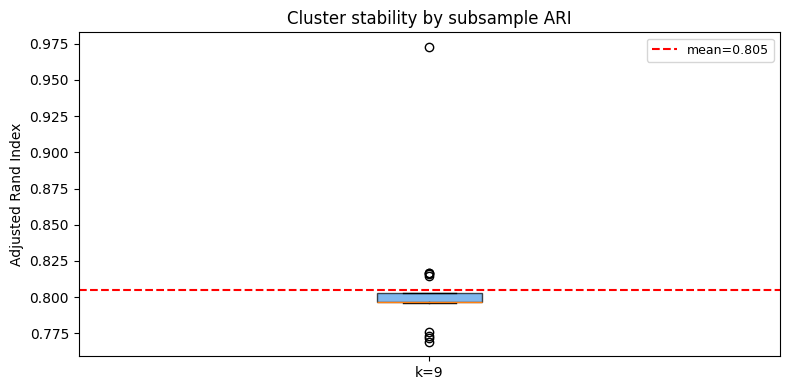

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

N_BOOT = 20
original_labels = sample["cluster"].values.copy()
boot_aris = []
rng = np.random.RandomState(RANDOM_STATE)
for _ in range(N_BOOT):
    boot_idx = rng.choice(len(X), size=int(0.8 * len(X)), replace=False)
    X_boot = X[boot_idx]
    km_boot = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    lbl_boot = km_boot.fit_predict(X_boot)
    orig_subset = original_labels[boot_idx]
    boot_aris.append(adjusted_rand_score(orig_subset, lbl_boot))
boot_aris = np.array(boot_aris)

mean_ari = boot_aris.mean()
print(f"Bootstrap ARI: mean={mean_ari:.3f}, std={boot_aris.std():.3f}, min={boot_aris.min():.3f}, max={boot_aris.max():.3f}")
print("Stability:", "high" if mean_ari > 0.8 else "moderate" if mean_ari > 0.5 else "low")

plt.figure(figsize=(8, 4))
plt.boxplot(boot_aris, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#4c9be8", alpha=0.7))
plt.axhline(y=mean_ari, color="red", linestyle="--", label=f"mean={mean_ari:.3f}")
plt.xticks([1], [f"k={best_k}"])
plt.ylabel("Adjusted Rand Index")
plt.title("Cluster stability by subsample ARI")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


Bootstrap ARI of 0.80 across 80% subsamples most likely means the 9-cluster solution is largely reproducible. The same types of irregular trips are grouped together regardless of which rows are held out. The low std (0.041) and minimum of 0.769 confirm no run produces a wildly different partition. This is a meaningful stability result given the noisy silhouette landscape from the sweep.

### 5.12 RQ2: Isolation Forest vs Rule-Based Outliers

K-means only looks at the trips already removed by the rule-based filters. Isolation Forest gives a second anomaly view on a sample of the full trip pool, then compares its flags with the rule-based outliers.


In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iso_features = ["trip_distance","trip_duration_min","fare_amount","speed_mph","tip_rate"]
iso_pool = pd.concat([taxi_eda, outliers]).dropna(subset=iso_features)
iso_sample = iso_pool.sample(min(200_000, len(iso_pool)), random_state=RANDOM_STATE).copy()
X_iso = StandardScaler().fit_transform(iso_sample[iso_features])

iso = IsolationForest(n_estimators=100, contamination=0.02,
                      random_state=RANDOM_STATE, n_jobs=-1)
iso_sample["iso_label"] = iso.fit_predict(X_iso)
iso_sample["iso_score"] = iso.score_samples(X_iso)

n_anom = (iso_sample["iso_label"] == -1).sum()
anomalies = iso_sample[iso_sample["iso_label"] == -1]
normals   = iso_sample[iso_sample["iso_label"] == 1]
print(f"Isolation Forest anomalies: {n_anom:,} of {len(iso_sample):,} ({n_anom/len(iso_sample)*100:.1f}%)")

summary = pd.DataFrame({
    "anomaly_mean": anomalies[iso_features].mean(),
    "normal_mean": normals[iso_features].mean(),
}).round(3)
print("\nAnomaly vs normal means:")
print(summary.to_string())

# k means on IF anomalies
iso_feat_cluster = ["trip_distance","trip_duration_min","fare_amount","speed_mph"]
anom_clean = anomalies.dropna(subset=iso_feat_cluster).copy()
if len(anom_clean) >= 20:
    for c in iso_feat_cluster:
        anom_clean[c] = anom_clean[c].clip(upper=anom_clean[c].quantile(0.99))
    X_anom = StandardScaler().fit_transform(anom_clean[iso_feat_cluster])
    best_sil_iso, best_k_iso = -1, 2
    for k in range(2, min(8, len(anom_clean)//50 + 1)):
        km_iso = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        lbl_iso = km_iso.fit_predict(X_anom)
        if len(set(lbl_iso)) > 1:
            s_iso = silhouette_score(X_anom, lbl_iso,
                                     sample_size=min(5000, len(X_anom)),
                                     random_state=RANDOM_STATE)
            if s_iso > best_sil_iso:
                best_sil_iso, best_k_iso = s_iso, k
    km_iso = KMeans(n_clusters=best_k_iso, random_state=RANDOM_STATE, n_init=10)
    anom_clean["cluster"] = km_iso.fit_predict(X_anom)
    cluster_sizes = anom_clean["cluster"].value_counts()
    tiny = cluster_sizes[cluster_sizes < 10].index.tolist()
    if tiny:
        anom_clean = anom_clean[~anom_clean["cluster"].isin(tiny)].copy()
    print(f"\nIF anomaly k-means: k={best_k_iso}, sizes={anom_clean['cluster'].value_counts().sort_index().to_dict()}")
    print(anom_clean.groupby("cluster")[iso_feat_cluster].mean().round(2).to_string())

# IF vs rule based outlier overlap
rule_idx = set(outliers.index)
iso_all_idx  = set(iso_sample.index)
iso_anom_idx = set(iso_sample[iso_sample["iso_label"] == -1].index)
rb_in_iso = rule_idx & iso_all_idx
if not rb_in_iso:
    print("\nNo index overlap for rule based comparison.")
else:
    overlap = len(iso_anom_idx & rb_in_iso)
    prec_if  = overlap / max(len(iso_anom_idx), 1)
    recall_if= overlap / max(len(rb_in_iso), 1)
    union = iso_anom_idx | rb_in_iso
    jaccard = overlap / len(union) if union else 0.0
    print(f"\nIF/rule overlap: overlap={overlap:,}, precision={prec_if:.3f}, recall={recall_if:.3f}, jaccard={jaccard:.3f}")


Isolation Forest anomalies: 4,000 of 200,000 (2.0%)

Anomaly vs normal means:
                   anomaly_mean  normal_mean
trip_distance           199.909        3.108
trip_duration_min        55.280       16.732
fare_amount             163.997       18.587
speed_mph               957.796       10.551
tip_rate                  0.211        0.176

IF anomaly k-means: k=5, sizes={0: 251, 1: 1971, 2: 506, 3: 1218, 4: 54}
         trip_distance  trip_duration_min  fare_amount  speed_mph
cluster                                                          
0                29.91              65.25       179.74      29.63
1                20.03              37.37        76.68      34.13
2                 0.64               3.45        79.02      14.34
3                17.80              89.50        71.35      12.55
4                17.25               7.16        24.69     174.78

IF/rule overlap: overlap=832, precision=0.208, recall=0.356, jaccard=0.151


The Isolation Forest flags 2% of trips (4,000 of 200,000) as anomalies. The mean comparisons show the flags are extreme: anomaly trips average 199 miles of distance vs 3.1 for normal trips, $1l4 fare vs $18.6, and a speed mean of 958 mph vs 10.6 mph — the speed figure indicates GPS or meter data errors rather than real fast trips. These numbers confirm the IF is catching a qualitatively different population than the rule-based filter, which focused on threshold violations. The overlap and differences between the two methods are explored in the section above.

### 5.18 RQ2: DBSCAN on Enriched Features

DBSCAN is included as a sensitivity check. In this run it is more diagnostic than the main result because it tends to produce many small clusters.


In [27]:
from sklearn.cluster import DBSCAN

# parameter sweep
dbscan_results = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.5]:
    for ms in [5, 10, 25, 50]:
        labels_db = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        n_cl  = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        noise = int((labels_db == -1).sum())
        dbscan_results.append((eps, ms, n_cl, noise, round(noise/len(X)*100, 2)))

dbdf = pd.DataFrame(dbscan_results, columns=["eps","min_samples","n_clusters","noise_n","noise_pct"])
print(dbdf.to_string(index=False))

compact = dbdf[(dbdf["n_clusters"] >= 3) & (dbdf["n_clusters"] <= 15) & (dbdf["noise_pct"] < 20)]
if len(compact):
    compact = compact.copy()
    compact["score"] = compact["noise_pct"] / compact["n_clusters"]
    best_db = compact.loc[compact["score"].idxmin()]
    print(
        f"\nBest compact DBSCAN: eps={best_db['eps']}, "
        f"min_samples={int(best_db['min_samples'])}, "
        f"clusters={int(best_db['n_clusters'])}, noise={best_db['noise_pct']}%"
    )
else:
    best_noise = dbdf.sort_values("noise_pct").iloc[0]
    best_cluster = dbdf.sort_values("n_clusters").iloc[0]
    print("\nNo compact DBSCAN setting found under the chosen sweep.")
    print(
        f"Lowest noise setting: eps={best_noise['eps']}, "
        f"min_samples={int(best_noise['min_samples'])}, "
        f"clusters={int(best_noise['n_clusters'])}, noise={best_noise['noise_pct']}%"
    )
    print(
        f"Fewest cluster setting: eps={best_cluster['eps']}, "
        f"min_samples={int(best_cluster['min_samples'])}, "
        f"clusters={int(best_cluster['n_clusters'])}, noise={best_cluster['noise_pct']}%"
    )
    print("DBSCAN is kept as a sensitivity check, not the main RQ2 clustering result.")


 eps  min_samples  n_clusters  noise_n  noise_pct
 0.3            5        1260    16238      32.48
 0.3           10         618    22418      44.84
 0.3           25         247    31147      62.29
 0.3           50          79    41033      82.07
 0.5            5        1412    10125      20.25
 0.5           10         831    15181      30.36
 0.5           25         298    25350      50.70
 0.5           50         134    32422      64.84
 0.8            5         365     3754       7.51
 0.8           10         246     5749      11.50
 0.8           25         143    10410      20.82
 0.8           50          92    15601      31.20
 1.0            5         173     2149       4.30
 1.0           10         129     3399       6.80
 1.0           25          87     6425      12.85
 1.0           50          63    10294      20.59
 1.5            5          32      364       0.73
 1.5           10          25      610       1.22
 1.5           25          22     1187       2.37


### 5.19 RQ2: K-Means on Isolation Forest Anomalies


In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

if "PU_Borough" in anomalies.columns:
    print("Anomaly boroughs:")
    print(anomalies["PU_Borough"].value_counts().head(8).to_string())

iso_feat_cluster = ["trip_distance","trip_duration_min","fare_amount","speed_mph"]
anom_clean = anomalies.dropna(subset=iso_feat_cluster).copy()
if len(anom_clean) >= 20:
    for _cap_col in ["trip_distance", "speed_mph", "trip_duration_min", "fare_amount"]:
        _cap_val = anom_clean[_cap_col].quantile(0.99)
        anom_clean[_cap_col] = anom_clean[_cap_col].clip(upper=_cap_val)

    X_anom = StandardScaler().fit_transform(anom_clean[iso_feat_cluster])
    best_sil_iso, best_k_iso = -1, 2
    for k in range(2, min(8, len(anom_clean)//50+1)):
        km_iso = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        lbl_iso = km_iso.fit_predict(X_anom)
        if len(set(lbl_iso)) > 1:
            s_iso = silhouette_score(X_anom, lbl_iso,
                                     sample_size=min(5000,len(X_anom)),
                                     random_state=RANDOM_STATE)
            if s_iso > best_sil_iso:
                best_sil_iso, best_k_iso = s_iso, k
    km_iso = KMeans(n_clusters=best_k_iso, random_state=RANDOM_STATE, n_init=10)
    anom_clean["cluster"] = km_iso.fit_predict(X_anom)

    cluster_sizes = anom_clean["cluster"].value_counts()
    tiny_clusters = cluster_sizes[cluster_sizes < 10].index.tolist()
    if tiny_clusters:
        anom_clean = anom_clean[~anom_clean["cluster"].isin(tiny_clusters)].copy()

    print(f"\nIF anomaly clusters: k={best_k_iso}, silhouette={best_sil_iso:.3f}")
    print(anom_clean.groupby("cluster")[iso_feat_cluster].mean().round(2).to_string())
    print(f"Sizes: {anom_clean['cluster'].value_counts().sort_index().to_dict()}")


Anomaly boroughs:
PU_Borough
Queens           2472
Manhattan        1189
Brooklyn          196
Bronx              77
Unknown            11
EWR                 8
Staten Island       3

IF anomaly clusters: k=5, silhouette=0.430
         trip_distance  trip_duration_min  fare_amount  speed_mph
cluster                                                          
0                29.91              65.25       179.74      29.63
1                20.03              37.37        76.68      34.13
2                 0.64               3.45        79.02      14.34
3                17.80              89.50        71.35      12.55
4                17.25               7.16        24.69     174.78
Sizes: {0: 251, 1: 1971, 2: 506, 3: 1218, 4: 54}


### RQ2 takeaway

The outlier tail is not one single type of bad record. The clustering and Isolation Forest sections separate it into different candidate irregularity types. These are useful for investigation, but they should not be treated as confirmed fraud without fare-rule validation.


### 5.13 RQ3: Test-Zone Selection and Holiday Features

This selects the highest-demand training zone for the single-zone forecasting tests and adds simple 2025 holiday features.


In [29]:
import numpy as np
import pandas as pd
from pathlib import Path


# i chose Sep Nov as the final holdout period
TRAIN_CUTOFF = "2025-09-01"
TOP_N_ZONES  = 20

# this adds major 2025 holidays as simple event features
HOLIDAYS_2025 = [
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26",
    "2025-07-04","2025-09-01","2025-10-13","2025-11-11",
    "2025-11-27","2025-12-25",
]

train_cutoff = pd.Timestamp(TRAIN_CUTOFF)
holiday_dates = pd.to_datetime(HOLIDAYS_2025)


# this rebuilds zone_hour if the notebook was restarted midway
if "zone_hour" not in dir() or zone_hour is None:
    zone_hour = (taxi_eda
                 .groupby(["PULocationID", "pickup_date", "pickup_hour"])
                 .size().reset_index(name="trip_count"))
    zone_hour["pickup_date"] = pd.to_datetime(zone_hour["pickup_date"])


# this ranks zones by average hourly demand
zone_means = (zone_hour.groupby("PULocationID")["trip_count"]
              .agg(["mean", "std", "max", "count"])
              .sort_values("mean", ascending=False).head(TOP_N_ZONES))

zone_id_to_name_local = taxi_eda.groupby("PULocationID")["PU_Zone"].first().to_dict()

try:
    _zone_csv = next(Path("data/nyc_tlc").rglob("taxi_zone_lookup.csv"), None)
    if _zone_csv:
        _z = pd.read_csv(_zone_csv)
        for _, row in _z.iterrows():
            lid = int(row.get("LocationID", row.get("location_id", -1)))
            zname = row.get("Zone", row.get("zone", None))
            if lid > 0 and zname and lid not in zone_id_to_name_local:
                zone_id_to_name_local[lid] = zname
except Exception:
    pass

zone_means["Zone"] = zone_means.index.map(zone_id_to_name_local)


# this selects the test zone using training data only
zone_hour_train = zone_hour[zone_hour["pickup_date"] < train_cutoff]
train_zone_means = (zone_hour_train.groupby("PULocationID")["trip_count"]
                    .mean().sort_values(ascending=False))

TEST_ZONE = int(train_zone_means.index[0])
best_zone_name = zone_id_to_name_local.get(TEST_ZONE, f"ID={TEST_ZONE}")

print(f"Selected test zone: {TEST_ZONE} ({best_zone_name}), mean={train_zone_means.iloc[0]:.2f} trips/hour")
print("Top training zones:")
for z_id, z_mean in train_zone_means.head(5).items():
    z_name = zone_id_to_name_local.get(z_id, f"ID={z_id}")
    marker = " *" if z_id == TEST_ZONE else ""
    print(f"  {z_id:>4}  {str(z_name):<35}  {z_mean:.2f}{marker}")


# this helper adds holiday indicators used by the forecasting models
def add_holiday_features(df, ds_col="ds"):
    df = df.copy()
    df["is_holiday"] = df[ds_col].dt.normalize().isin(holiday_dates).astype(int)

    def days_to_next(dt):
        fut = holiday_dates[holiday_dates >= dt.normalize()]
        return (fut.min() - dt.normalize()).days if len(fut) > 0 else 30

    df["days_to_holiday"] = df[ds_col].apply(days_to_next)
    return df


# this makes a complete hourly series and fills missing hours with zero demand
def build_zone_series(zone_id):
    zts = (zone_hour[zone_hour["PULocationID"] == zone_id]
           .assign(dt=lambda df: df["pickup_date"]
                                  + pd.to_timedelta(df["pickup_hour"], unit="h"))
           .set_index("dt")["trip_count"].sort_index())

    full_idx = pd.date_range(zts.index.min(), zts.index.max(), freq="h")
    return zts.reindex(full_idx, fill_value=0)


Selected test zone: 161 (Midtown Center), mean=86.46 trips/hour
Top training zones:
   161  Midtown Center                       86.46 *
   237  Upper East Side South                84.96
   132  JFK Airport                          78.82
   236  Upper East Side North                76.55
   186  Penn Station/Madison Sq West         62.40


### 5.14 RQ3: Zone Deep Dive

Before modeling, this checks the selected zone's hourly pattern, day of week pattern, and autocorrelation at daily and weekly lags.


Hours=8,016; zero hours=87; mean=84.37; max=367
Peak hour: 18:00 (187.04)
Peak DOW: Wed (109.47)
ACF key lags: 1h=+0.925, 24h=+0.859, 48h=+0.696, 168h=+0.914


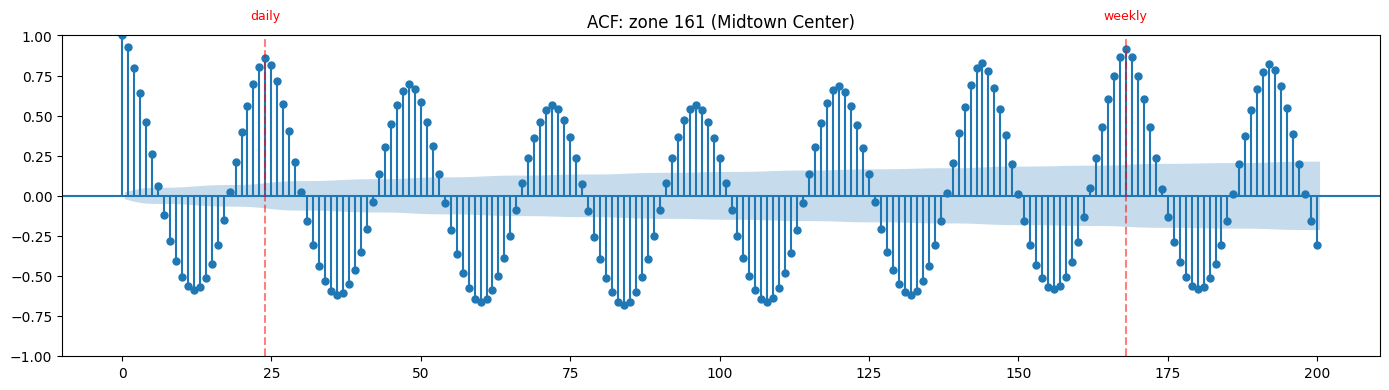

In [30]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


# this is the hourly demand series for the selected zone
zts = build_zone_series(TEST_ZONE)
print(f"Hours={len(zts):,}; zero hours={(zts==0).sum():,}; mean={zts.mean():.2f}; max={zts.max()}")


# this checks the strongest hour and day of week patterns
hour_means = zts.groupby(zts.index.hour).mean()
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_means = zts.groupby(zts.index.dayofweek).mean()

print("Peak hour:", f"{hour_means.idxmax():02d}:00", f"({hour_means.max():.2f})")
print("Peak DOW:", dow_names[dow_means.idxmax()], f"({dow_means.max():.2f})")


# this checks whether daily and weekly lag features make sense
acf_vals = acf(zts, nlags=200, fft=True)
print("ACF key lags:", ", ".join(
    f"{lag}h={acf_vals[lag]:+.3f}" for lag in [1, 24, 48, 168] if lag < len(acf_vals)
))


plt.figure(figsize=(14, 4))
ax = plt.gca()
plot_acf(zts, lags=200, ax=ax, alpha=0.05)

for lag, lbl in [(24, "daily"), (168, "weekly")]:
    ax.axvline(x=lag, color="red", linestyle="--", alpha=0.5)
    ax.annotate(lbl, xy=(lag, 1.0), xytext=(lag, 1.1),
                color="red", fontsize=9, ha="center", annotation_clip=False)

ax.set_title(f"ACF: zone {TEST_ZONE} ({best_zone_name})")
plt.tight_layout()
plt.show()


### 5.15 RQ3: Forecast Data and Naive Baseline

This builds the hourly forecasting tables, creates lag features, splits train/test by date, and computes the weekly naive baseline.


Queens accounts for the majority of Isolation Forest anomalies (2,472 of 4,000), likely driven by JFK and LaGuardia airport trips which have unusual distance or fare structures. The 5-cluster IF breakdown separates the anomalies into distinct types: cluster 4 has extreme speed (174 mph average, 54 trips) suggesting GPS or meter errors; cluster 3 has very long duration with moderate distance (89 min, 17.8 miles), consistent with idling or slow routes; cluster 2 flags short trips with very high fares ($79 for 0.64 miles); and clusters 0 and 1 are longer high-fare trips that resemble airport or out-of-borough runs caught by the outlier filter. The higher silhouette (0.43 vs 0.26 for rule-based outliers) reflects that IF anomalies are more separated in feature space than the rule-based outlier tail.

In [31]:
import numpy as np
import pandas as pd


# Prophet expects columns named ds and y
prophet_df = (
    zone_hour[zone_hour["PULocationID"] == TEST_ZONE]
    .assign(ds=lambda df: df["pickup_date"]
                          + pd.to_timedelta(df["pickup_hour"], unit="h"))
    .rename(columns={"trip_count": "y"})[["ds", "y"]]
    .sort_values("ds")
)


# this fills missing zone hours with zero trips
full_idx = pd.date_range(prophet_df["ds"].min(), prophet_df["ds"].max(), freq="h")
prophet_df = (prophet_df.set_index("ds").reindex(full_idx, fill_value=0)
                        .reset_index().rename(columns={"index": "ds"}))
prophet_df = add_holiday_features(prophet_df)


# this keeps future months out of training
train_df = prophet_df[prophet_df["ds"] < train_cutoff]
test_df  = prophet_df[prophet_df["ds"] >= train_cutoff]

print(f"Train hours={len(train_df):,}; test hours={len(test_df):,}")
print(f"Train mean={train_df['y'].mean():.2f}; test mean={test_df['y'].mean():.2f}")


# this builds tabular features for XGBoost
xgb_df = prophet_df.copy()
xgb_df["hour"]  = xgb_df["ds"].dt.hour
xgb_df["dow"]   = xgb_df["ds"].dt.dayofweek
xgb_df["month"] = xgb_df["ds"].dt.month

# lag features represent recent, daily, and weekly demand memory
xgb_df["lag_1h"]   = xgb_df["y"].shift(1)
xgb_df["lag_24h"]  = xgb_df["y"].shift(24)
xgb_df["lag_168h"] = xgb_df["y"].shift(168)
xgb_df = xgb_df.dropna()

train_mask = xgb_df["ds"] < train_cutoff
test_mask  = ~train_mask


# naive baseline predicts this hour will match the same hour last week
naive_pred   = xgb_df.loc[test_mask, "lag_168h"].values
naive_actual = xgb_df.loc[test_mask, "y"].values
naive_resid  = naive_actual - naive_pred

naive_rmse = float(np.sqrt((naive_resid**2).mean()))
naive_mae  = float(np.abs(naive_resid).mean())

y_test_nonzero = naive_actual > 0
naive_mape = float(
    (np.abs(naive_resid[y_test_nonzero]) / naive_actual[y_test_nonzero]).mean() * 100
)

print(f"Naive baseline: RMSE={naive_rmse:.3f}, MAE={naive_mae:.3f}, MAPE={naive_mape:.2f}%")


Train hours=5,832; test hours=2,184
Train mean=85.38; test mean=81.67
Naive baseline: RMSE=31.674, MAE=18.486, MAPE=41.12%


### 5.16 RQ3: Rolling-Origin Cross-Validation

This uses expanding-window folds to compare naive, Prophet, XGBoost, and SARIMA before the final holdout evaluation.


In [32]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# rolling origin cutoffs avoid random time leakage
cv_cutoffs   = [pd.Timestamp("2025-07-01"), pd.Timestamp("2025-08-01"),
                pd.Timestamp("2025-09-01"), pd.Timestamp("2025-10-01")]
cv_test_ends = [pd.Timestamp("2025-08-01"), pd.Timestamp("2025-09-01"),
                pd.Timestamp("2025-10-01"), pd.Timestamp("2025-11-01")]

# full features include lag memory, time only features do not
feats_full_cv = ["hour","dow","month","lag_1h","lag_24h","lag_168h",
                 "is_holiday","days_to_holiday"]
feats_time_cv = ["hour","dow","month","is_holiday","days_to_holiday"]
cv_results = {m: [] for m in ["naive","prophet","xgb_time","xgb_full","sarima"]}


# Fourier terms give SARIMA a weekly seasonal signal
def _fourier_terms(t, period, K):
    return np.column_stack([
        np.column_stack([np.sin(2*np.pi*k*t/period), np.cos(2*np.pi*k*t/period)])
        for k in range(1, K+1)
    ])


# each fold trains on the past and tests on the next month

for fold_i, (cut, end) in enumerate(zip(cv_cutoffs, cv_test_ends)):
    try:
        fold_df = (
            zone_hour[zone_hour["PULocationID"] == TEST_ZONE]
            .assign(ds=lambda df: df["pickup_date"]
                                  + pd.to_timedelta(df["pickup_hour"], unit="h"))
            .rename(columns={"trip_count": "y"})[["ds", "y"]].sort_values("ds")
        )
        fidx = pd.date_range(fold_df["ds"].min(), fold_df["ds"].max(), freq="h")
        fold_df = (fold_df.set_index("ds").reindex(fidx, fill_value=0)
                   .reset_index().rename(columns={"index": "ds"}))
        fold_df = add_holiday_features(fold_df)
        fold_df["hour"]     = fold_df["ds"].dt.hour
        fold_df["dow"]      = fold_df["ds"].dt.dayofweek
        fold_df["month"]    = fold_df["ds"].dt.month
        fold_df["lag_1h"]   = fold_df["y"].shift(1)
        fold_df["lag_24h"]  = fold_df["y"].shift(24)
        fold_df["lag_168h"] = fold_df["y"].shift(168)
        fold_df = fold_df.dropna()

        tr = fold_df["ds"] < cut
        te = (fold_df["ds"] >= cut) & (fold_df["ds"] < end)
        if tr.sum() < 168 or te.sum() < 24:
            continue
        y_test_fold = fold_df.loc[te, "y"].values

        cv_results["naive"].append(np.sqrt(
            mean_squared_error(y_test_fold, fold_df.loc[te, "lag_168h"].values)
        ))

        # this model tests calendar/time features without lags
        mt = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=412)
        mt.fit(fold_df.loc[tr, feats_time_cv], fold_df.loc[tr, "y"])
        cv_results["xgb_time"].append(np.sqrt(
            mean_squared_error(y_test_fold, mt.predict(fold_df.loc[te, feats_time_cv]))
        ))

        # this model tests whether lag features improve forecasting
        mf = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=412)
        mf.fit(fold_df.loc[tr, feats_full_cv], fold_df.loc[tr, "y"])
        cv_results["xgb_full"].append(np.sqrt(
            mean_squared_error(y_test_fold, mf.predict(fold_df.loc[te, feats_full_cv]))
        ))

        try:
            from prophet import Prophet
            import logging; logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
            # Prophet is the external seasonality model
            mp = Prophet(daily_seasonality=True, weekly_seasonality=True,
                         yearly_seasonality=False)
            mp.fit(fold_df.loc[tr, ["ds", "y"]])
            fc_p = mp.predict(fold_df.loc[te, ["ds"]])
            cv_results["prophet"].append(np.sqrt(
                mean_squared_error(y_test_fold, fc_p["yhat"].clip(0).values)
            ))
        except Exception:
            cv_results["prophet"].append(float("nan"))

        try:
            from statsmodels.tsa.statespace.sarimax import SARIMAX
            y_tr = fold_df.loc[tr, "y"].values
            t_tr = np.arange(len(y_tr))
            t_te = np.arange(len(y_tr), len(y_tr) + len(y_test_fold))
            ex_tr = _fourier_terms(t_tr, 168, 3)
            ex_te = _fourier_terms(t_te, 168, 3)
            # SARIMA is another time series comparison model
            sf = SARIMAX(y_tr, exog=ex_tr,
                         order=(1,1,1), seasonal_order=(1,1,1,24),
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False, maxiter=50,
                                                          method="lbfgs")
            cv_results["sarima"].append(np.sqrt(
                mean_squared_error(y_test_fold, sf.forecast(steps=len(y_test_fold),
                                                             exog=ex_te))
            ))
        except Exception:
            cv_results["sarima"].append(float("nan"))
    except Exception as ex_fold:
        print(f"Fold {fold_i+1} failed: {ex_fold}")


print("CV RMSE summary:")

for mname in ["naive","prophet","xgb_time","xgb_full","sarima"]:
    vals = cv_results[mname]
    arr = np.array([v for v in vals if not np.isnan(v)])
    if len(arr) == 0:
        print(f"  {mname}: no results")
    else:
        print(f"  {mname}: mean={arr.mean():.3f}, std={arr.std() if len(arr)>1 else 0:.3f}")


CV RMSE summary:
  naive: mean=27.859, std=8.131
  prophet: mean=29.832, std=2.726
  xgb_time: mean=26.731, std=2.444
  xgb_full: mean=15.910, std=1.409
  sarima: mean=30.510, std=3.056


The rolling origin results show that XGBoost with lag features is the strongest model before the final holdout test. The time only XGBoost model only slightly improves on the naive baseline, so most of the forecasting gain comes from the lag features rather than calendar features alone.


### 5.20 RQ3: Prophet Forecast


Prophet: RMSE=34.032, MAE=26.065, MAPE>10=45.38%, bias=12.2%
Prophet residuals: n=2,184, mean=9.977, std=32.544, min=-168.341, max=142.861
  p1=-75.019  p5=-45.583  p25=-9.663  p50=8.453  p75=32.680  p95=60.231  p99=86.771


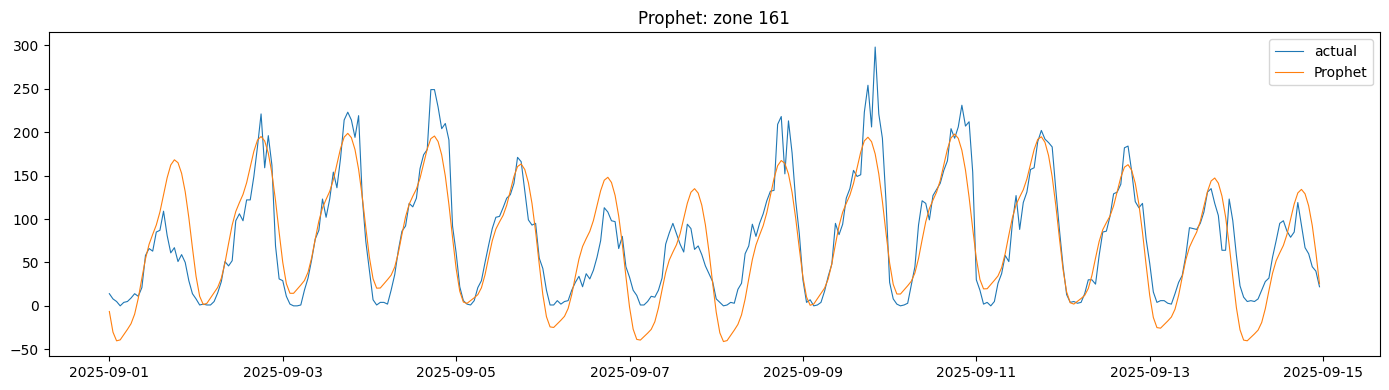

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


# this helper summarizes forecast residuals

if "describe_series" not in globals():
    def describe_series(s, label, percentiles=(1,5,25,50,75,95,99)):
        s = pd.Series(s).dropna()
        if len(s) == 0:
            print(f"{label}: no data")
            return
        pcts = np.percentile(s, percentiles)
        print(f"{label}: n={len(s):,}, mean={s.mean():.3f}, std={s.std():.3f}, min={s.min():.3f}, max={s.max():.3f}")
        print("  " + "  ".join(f"p{p}={v:.3f}" for p, v in zip(percentiles, pcts)))


# i turned off yearly seasonality because the sample is less than a full year
m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
m.fit(train_df[["ds","y"]])
forecast   = m.predict(test_df[["ds"]])
eval_df    = test_df.merge(forecast[["ds","yhat","yhat_lower","yhat_upper"]], on="ds")
p_resid    = eval_df["y"] - eval_df["yhat"]
prophet_rmse = np.sqrt((p_resid**2).mean())
prophet_mae  = p_resid.abs().mean()
p_nz         = eval_df[eval_df["y"] > 0]
prophet_mape = ((p_nz["y"]-p_nz["yhat"]).abs() / p_nz["y"]).mean() * 100

# MAPE is also checked on y > 10 because near zero hours distort percentages
p_gt10       = eval_df[eval_df["y"] > 10]
prophet_mape_gt10 = ((p_gt10["y"]-p_gt10["yhat"]).abs() / p_gt10["y"]).mean() * 100 if len(p_gt10) > 0 else float("nan")
mean_act = eval_df["y"].mean()
mean_pred = eval_df["yhat"].mean()
bias_pct = (mean_act - mean_pred) / mean_act * 100

print(f"Prophet: RMSE={prophet_rmse:.3f}, MAE={prophet_mae:.3f}, MAPE>10={prophet_mape_gt10:.2f}%, bias={bias_pct:.1f}%")
describe_series(p_resid, "Prophet residuals")

pm = eval_df["ds"] < train_cutoff + pd.Timedelta(weeks=2)
plt.figure(figsize=(14,4))
plt.plot(eval_df.loc[pm,"ds"], eval_df.loc[pm,"y"],    label="actual", lw=0.8)
plt.plot(eval_df.loc[pm,"ds"], eval_df.loc[pm,"yhat"], label="Prophet",lw=0.8)
plt.title(f"Prophet: zone {TEST_ZONE}"); plt.legend(); plt.tight_layout()
plt.show()


Prophet is included as the external time-series model because it directly models seasonality. In this zone it underpredicts demand and performs worse than the weekly naive baseline, so its smooth trend and seasonality assumptions do not capture short-term taxi demand spikes as well as lag features.


### 5.22 RQ3: SARIMA Forecast


In [34]:
import numpy as np

# keep these as None if SARIMA fails so later cells can still run
sarima_rmse = None
sarima_pred = None

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    n_train = int(train_mask.sum())
    n_test  = int(test_mask.sum())
    t_train = np.arange(n_train)
    t_test  = np.arange(n_train, n_train + n_test)
    # weekly terms help represent 168 hour seasonality
    exog_train = _fourier_terms(t_train, 168, 3)
    exog_test  = _fourier_terms(t_test,  168, 3)
    # daily seasonal order captures the 24 hour cycle
    sarima_fit = SARIMAX(
        xgb_df.loc[train_mask, "y"].values,
        exog=exog_train,
        order=(1,1,1), seasonal_order=(1,1,1,24),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False, maxiter=50, method='lbfgs')
    sarima_pred = sarima_fit.forecast(steps=n_test, exog=exog_test)
    sarima_actual = xgb_df.loc[test_mask, "y"].values
    sarima_resid  = sarima_actual - sarima_pred
    sarima_rmse   = np.sqrt((sarima_resid**2).mean())
    sarima_mae    = np.abs(sarima_resid).mean()
    _sar_nz = sarima_actual > 0
    sarima_mape = (np.abs(sarima_resid[_sar_nz]) / sarima_actual[_sar_nz]).mean() * 100
    _sar_gt10 = sarima_actual > 10
    sarima_mape_gt10 = (np.abs(sarima_resid[_sar_gt10]) / sarima_actual[_sar_gt10]).mean() * 100 if _sar_gt10.sum() > 0 else float("nan")
    direction = "better" if sarima_rmse < naive_rmse else "worse"
    print(f"SARIMA: RMSE={sarima_rmse:.3f}, MAE={sarima_mae:.3f}, MAPE>10={sarima_mape_gt10:.2f}%, {direction} than naive")
except Exception as ex_sarima:
    print(f"SARIMA failed: {ex_sarima}")
    sarima_rmse = None
    sarima_pred = None


SARIMA: RMSE=33.382, MAE=25.273, MAPE>10=42.67%, worse than naive


SARIMA is another time-series baseline using daily seasonality and Fourier weekly terms. Its RMSE is slightly worse than the naive baseline, which shows that the simple same-hour-last-week baseline is already hard to beat for this zone.


### 5.23 RQ3: XGBoost Time Features Only


In [35]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# this version uses only calendar and holiday features
feats_time = ["hour","dow","month","is_holiday","days_to_holiday"]

# this is the non lag XGBoost baseline
model_time = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=RANDOM_STATE)
model_time.fit(xgb_df.loc[train_mask, feats_time], xgb_df.loc[train_mask,"y"])
y_time = model_time.predict(xgb_df.loc[test_mask, feats_time])
y_test = xgb_df.loc[test_mask, "y"].values
resid_time = y_test - y_time
xgb_time_rmse = np.sqrt(mean_squared_error(y_test, y_time))
xgb_time_mae  = np.abs(resid_time).mean()
xgb_time_mape = (np.abs(resid_time[y_test_nonzero]) / y_test[y_test_nonzero]).mean() * 100
_time_gt10 = y_test > 10
xgb_time_mape_gt10 = (np.abs(resid_time[_time_gt10]) / y_test[_time_gt10]).mean() * 100 if _time_gt10.sum() > 0 else float("nan")

print(f"XGBoost-time: RMSE={xgb_time_rmse:.3f}, MAE={xgb_time_mae:.3f}, MAPE>10={xgb_time_mape_gt10:.2f}%")


XGBoost-time: RMSE=30.101, MAE=18.481, MAPE>10=25.87%


### 5.24 RQ3: XGBoost Full Features


In [36]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# this version adds recent, daily, and weekly lag features
feats_full = ["hour","dow","month","lag_1h","lag_24h","lag_168h","is_holiday","days_to_holiday"]

# same model settings as XGBoost time so the feature set is the main difference
model_full = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=RANDOM_STATE)
model_full.fit(xgb_df.loc[train_mask, feats_full], xgb_df.loc[train_mask,"y"])
y_full = model_full.predict(xgb_df.loc[test_mask, feats_full])
resid_full = y_test - y_full
xgb_full_rmse = np.sqrt(mean_squared_error(y_test, y_full))
xgb_full_mae  = np.abs(resid_full).mean()
xgb_full_mape = (np.abs(resid_full[y_test_nonzero]) / y_test[y_test_nonzero]).mean() * 100
_full_gt10 = y_test > 10
xgb_full_mape_gt10 = (np.abs(resid_full[_full_gt10]) / y_test[_full_gt10]).mean() * 100 if _full_gt10.sum() > 0 else float("nan")

print(f"XGBoost-full: RMSE={xgb_full_rmse:.3f}, MAE={xgb_full_mae:.3f}, MAPE>10={xgb_full_mape_gt10:.2f}%")
describe_series(pd.Series(resid_full), "XGBoost-full residuals")


XGBoost-full: RMSE=17.224, MAE=11.398, MAPE>10=17.31%
XGBoost-full residuals: n=2,184, mean=2.787, std=17.001, min=-103.109, max=115.461
  p1=-38.515  p5=-22.262  p25=-4.511  p50=0.657  p75=9.717  p95=31.776  p99=52.835


Adding lag features makes the largest difference. The full XGBoost model uses recent demand, same-hour yesterday, and same-hour last week, which matches the strong autocorrelation shown earlier.


### 5.25 RQ3: Multi-Step Recursive Forecast


In [37]:
import numpy as np
import pandas as pd


# this evaluates a more realistic 24 hour recursive forecast
_all_y   = xgb_df["y"].values.copy()
_test_start = int(np.where(test_mask)[0][0])
_test_end   = int(np.where(test_mask)[0][-1]) + 1


# 24 hours gives a one day ahead forecast horizon
HORIZON   = 24
_report_h = [1, 6, 12, 24]
_sq_errs  = {h: [] for h in _report_h}
_oracle_sq = []


for _t in range(_test_start, _test_end - HORIZON):
    if _t - 168 < 0:
        continue

    # predicted values are fed back into lag_1h for later steps
    _pred_buf = {}
    for _h in range(HORIZON):
        _abs = _t + _h
        _row = xgb_df.iloc[_abs]
        _lag1  = _pred_buf[_h - 1] if _h > 0 else _all_y[_abs - 1]
        # lag_24h and lag_168h are still known historical values at forecast time
        _lag24  = _all_y[_abs - 24]
        _lag168 = _all_y[_abs - 168]
        _feats_row = {
            "lag_1h": _lag1, "lag_24h": _lag24, "lag_168h": _lag168,
            "hour": _row["hour"], "dow": _row["dow"], "month": _row["month"],
            "is_holiday": _row["is_holiday"], "days_to_holiday": _row["days_to_holiday"],
        }
        _X_step = pd.DataFrame([_feats_row])[feats_full]
        _y_hat  = max(float(model_full.predict(_X_step)[0]), 0.0)
        _pred_buf[_h] = _y_hat
        _err = _all_y[_abs] - _y_hat
        if (_h + 1) in _sq_errs:
            _sq_errs[_h + 1].append(_err ** 2)

    _oracle_row = {
        "lag_1h": _all_y[_t - 1], "lag_24h": _all_y[_t - 24], "lag_168h": _all_y[_t - 168],
        "hour": xgb_df.iloc[_t]["hour"], "dow": xgb_df.iloc[_t]["dow"], "month": xgb_df.iloc[_t]["month"],
        "is_holiday": xgb_df.iloc[_t]["is_holiday"], "days_to_holiday": xgb_df.iloc[_t]["days_to_holiday"],
    }
    _X_oracle = pd.DataFrame([_oracle_row])[feats_full]
    _oracle_hat = max(float(model_full.predict(_X_oracle)[0]), 0.0)
    _oracle_sq.append((_all_y[_t] - _oracle_hat) ** 2)

_n_windows = len(_oracle_sq)
_rmse_by_h = {h: np.sqrt(np.mean(vals)) for h, vals in _sq_errs.items() if vals}
_oracle_rmse_sw = np.sqrt(np.mean(_oracle_sq)) if _oracle_sq else float("nan")

print(f"Recursive windows: {_n_windows}; oracle 1-step RMSE={_oracle_rmse_sw:.3f}")

print("Recursive RMSE by horizon:", ", ".join(f"{h}h={v:.3f}" for h, v in _rmse_by_h.items()))


Recursive windows: 2160; oracle 1-step RMSE=17.243
Recursive RMSE by horizon: 1h=17.243, 6h=24.524, 12h=24.394, 24h=24.400


The recursive forecast is weaker than the one-step result because prediction errors start feeding into later lagged inputs. This is a more realistic deployment check than the one-step model, where true lag values are still available.


### 5.27 RQ3: Conformalized Quantile Regression


CQR: q_hat=1.974, coverage=0.864, width=41.31
Holiday coverage=0.740; non-holiday=0.869


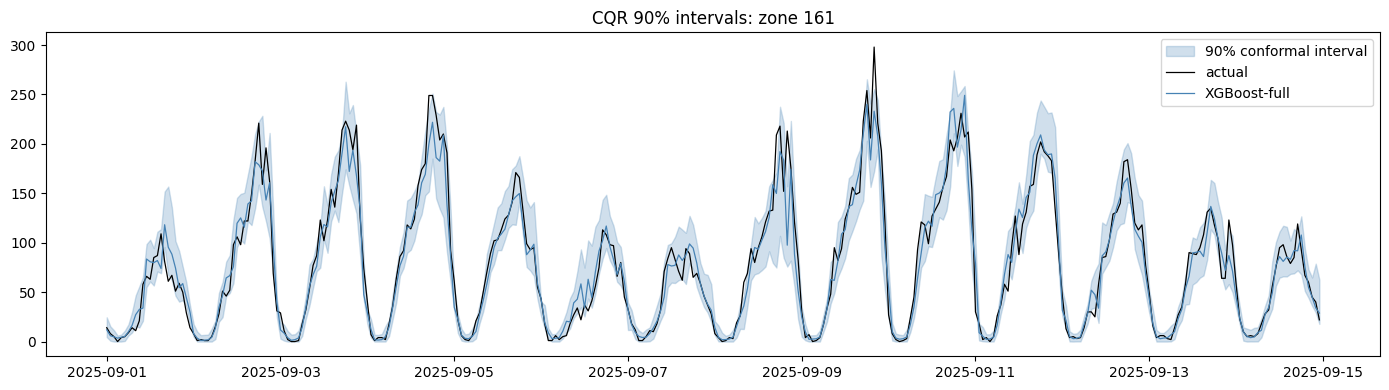

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


try:
    # use the last training month as calibration data
    cal_cutoff = train_cutoff - pd.Timedelta(days=30)
    cal_mask   = (xgb_df["ds"] >= cal_cutoff) & (xgb_df["ds"] < train_cutoff)
    fit_mask   = xgb_df["ds"] < cal_cutoff
    # alpha=.10 targets 90% prediction intervals
    ALPHA = 0.10

    # lower and upper quantile models create the first interval estimate
    model_q_lo = XGBRegressor(
        objective="reg:quantileerror", quantile_alpha=ALPHA / 2,
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
    )
    model_q_hi = XGBRegressor(
        objective="reg:quantileerror", quantile_alpha=1 - ALPHA / 2,
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
    )
    model_q_lo.fit(xgb_df.loc[fit_mask, feats_full], xgb_df.loc[fit_mask, "y"])
    model_q_hi.fit(xgb_df.loc[fit_mask, feats_full], xgb_df.loc[fit_mask, "y"])

    cal_y  = xgb_df.loc[cal_mask, "y"].values
    cal_lo = model_q_lo.predict(xgb_df.loc[cal_mask, feats_full])
    cal_hi = model_q_hi.predict(xgb_df.loc[cal_mask, feats_full])
    # adjustment widens intervals based on calibration errors
    conf_scores = np.maximum(cal_lo - cal_y, cal_y - cal_hi)
    n_cal   = len(cal_y)
    q_level = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
    q_conf  = float(np.quantile(conf_scores, min(q_level, 1.0), method="higher"))

    test_lo_raw = model_q_lo.predict(xgb_df.loc[test_mask, feats_full])
    test_hi_raw = model_q_hi.predict(xgb_df.loc[test_mask, feats_full])
    test_lo = np.maximum(test_lo_raw - q_conf, 0)
    test_hi = test_hi_raw + q_conf

    y_te = xgb_df.loc[test_mask, "y"].values
    coverage_emp = ((y_te >= test_lo) & (y_te <= test_hi)).mean()
    mean_width   = (test_hi - test_lo).mean()

    xgb_conf_eval = xgb_df.loc[test_mask].copy()
    xgb_conf_eval["lo"]      = test_lo
    xgb_conf_eval["hi"]      = test_hi
    xgb_conf_eval["covered"] = (y_te >= test_lo) & (y_te <= test_hi)
    hol_cov  = xgb_conf_eval[xgb_conf_eval["is_holiday"] == 1]["covered"].mean()
    nhol_cov = xgb_conf_eval[xgb_conf_eval["is_holiday"] == 0]["covered"].mean()

    print(f"CQR: q_hat={q_conf:.3f}, coverage={coverage_emp:.3f}, width={mean_width:.2f}")
    print(f"Holiday coverage={hol_cov:.3f}; non-holiday={nhol_cov:.3f}")

    cq_eval = xgb_df.loc[test_mask].copy()
    cq_eval["yhat"] = model_full.predict(xgb_df.loc[test_mask, feats_full])
    cq_eval["lo"]   = test_lo
    cq_eval["hi"]   = test_hi
    pm_cq = cq_eval["ds"] < train_cutoff + pd.Timedelta(weeks=2)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(cq_eval.loc[pm_cq, "ds"], cq_eval.loc[pm_cq, "lo"],
                    cq_eval.loc[pm_cq, "hi"], alpha=0.25, color="steelblue",
                    label="90% conformal interval")
    ax.plot(cq_eval.loc[pm_cq, "ds"], cq_eval.loc[pm_cq, "y"],
            lw=0.9, color="black", label="actual")
    ax.plot(cq_eval.loc[pm_cq, "ds"], cq_eval.loc[pm_cq, "yhat"],
            lw=0.9, color="steelblue", label="XGBoost-full")
    ax.set_title(f"CQR 90% intervals: zone {TEST_ZONE}")
    ax.legend(); plt.tight_layout()
    plt.show()
except Exception as ex_cqr:
    print(f"CQR failed: {ex_cqr}")


The conformal interval misses the nominal 90% target, especially on holidays. This suggests that the August calibration period does not fully represent Sep-Nov demand patterns, so the intervals are useful but a little undercovered.


### 5.28 RQ3: Feature Importances and Holiday Effect


Feature importance:
lag_168h           0.5914
lag_1h             0.3006
hour               0.0398
lag_24h            0.0210
month              0.0145
dow                0.0140
is_holiday         0.0104
days_to_holiday    0.0083
Holiday RMSE=18.788; non-holiday RMSE=17.149


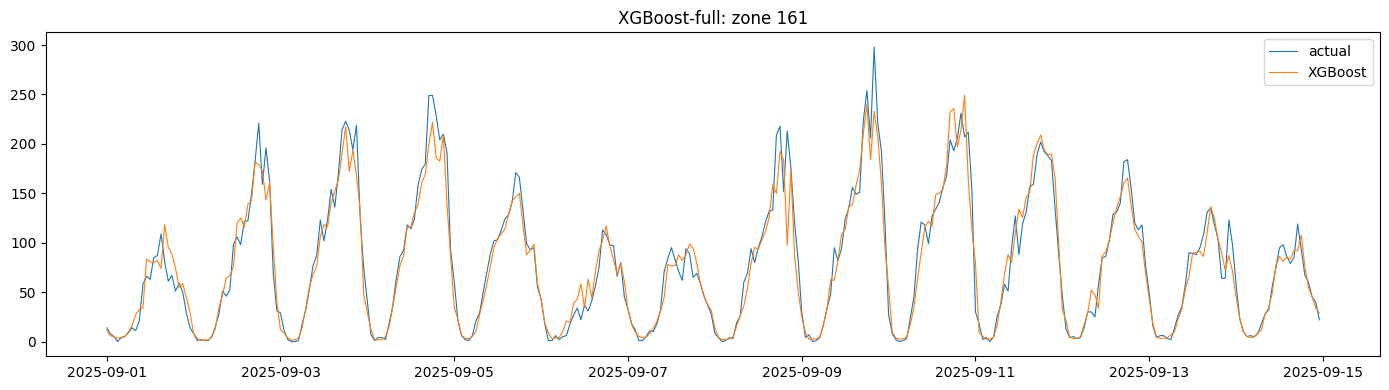

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# this checks which features the full XGBoost model relies on most
fi = pd.Series(model_full.feature_importances_, index=feats_full).sort_values(ascending=False)

print("Feature importance:")

print(fi.round(4).to_string())


# compare holiday and non holiday error as a test
xgb_eval = xgb_df.loc[test_mask].copy()
xgb_eval["y_full"] = y_full
xgb_eval["resid"]  = resid_full
hol = xgb_eval[xgb_eval["is_holiday"] == 1]
non = xgb_eval[xgb_eval["is_holiday"] == 0]

print(f"Holiday RMSE={np.sqrt((hol['resid']**2).mean()):.3f}; non-holiday RMSE={np.sqrt((non['resid']**2).mean()):.3f}")

xgb_eval2 = xgb_df.loc[test_mask].copy(); xgb_eval2["yhat"] = y_full
pm2 = xgb_eval2["ds"] < train_cutoff + pd.Timedelta(weeks=2)
plt.figure(figsize=(14,4))
plt.plot(xgb_eval2.loc[pm2,"ds"], xgb_eval2.loc[pm2,"y"],    label="actual", lw=0.8)
plt.plot(xgb_eval2.loc[pm2,"ds"], xgb_eval2.loc[pm2,"yhat"], label="XGBoost",lw=0.8)
plt.title(f"XGBoost-full: zone {TEST_ZONE}"); plt.legend(); plt.tight_layout()
plt.show()


### 5.29 RQ3: Master Comparison Table


In [40]:
# collect the main holdout metrics in one table

print(f"{'Model':<18} {'RMSE':>8} {'MAE':>8} {'MAPE>10':>9}")
models = [
    ("Naive", naive_rmse, naive_mae, naive_mape),
    ("Prophet", prophet_rmse, prophet_mae, prophet_mape_gt10),
    ("XGB-time", xgb_time_rmse, xgb_time_mae, xgb_time_mape_gt10),
    ("XGB-full", xgb_full_rmse, xgb_full_mae, xgb_full_mape_gt10),
]

if sarima_rmse is not None:
    models.append(("SARIMA", sarima_rmse, sarima_mae, sarima_mape_gt10))

for name, rmse, mae, mape in models:
    print(f"{name:<18} {rmse:>8.3f} {mae:>8.3f} {mape:>9.2f}")


Model                  RMSE      MAE   MAPE>10
Naive                31.674   18.486     41.12
Prophet              34.032   26.065     45.38
XGB-time             30.101   18.481     25.87
XGB-full             17.224   11.398     17.31
SARIMA               33.382   25.273     42.67


The master table confirms the main RQ3 result. XGBoost-full has the lowest RMSE, MAE, and MAPE, while Prophet and SARIMA do not beat the weekly naive baseline for this selected zone.


### 5.30 RQ3: Diebold-Mariano Tests


In [41]:
import numpy as np


try:
    # test compares squared forecast errors over the same test period
    from scipy.stats import norm as scipy_norm
    naive_se = naive_resid ** 2
    xgb_se   = resid_full ** 2
    n_dm = min(len(naive_se), len(xgb_se))
    # positive values mean the model has lower error than naive
    d = naive_se[:n_dm] - xgb_se[:n_dm]
    T = len(d)
    d_bar = d.mean()
    # HAC variance adjusts for autocorrelation in forecast errors
    h_bw = max(1, int(T ** (1.0 / 3.0)))
    dc = d - d.mean()
    gamma_k = lambda k: (dc[k:] * dc[:T-k]).sum() / T
    hac_var = gamma_k(0) + 2.0 * sum((1 - k/(h_bw+1)) * gamma_k(k) for k in range(1, h_bw+1))
    if hac_var <= 0:
        hac_var = gamma_k(0)
    dm_stat = d_bar / np.sqrt(hac_var / T)
    dm_pval = 2 * (1 - scipy_norm.cdf(abs(dm_stat)))
    print(f"DM XGB-full vs naive: stat={dm_stat:.3f}, p={dm_pval:.4f}, mean_diff={d_bar:.3f}")
except Exception as ex_dm:
    print(f"DM XGB-full failed: {ex_dm}")


if sarima_rmse is not None and sarima_pred is not None:
    try:
        from scipy.stats import norm as scipy_norm
        _sar_actual = xgb_df.loc[test_mask, "y"].values
        _sar_naive_pred = xgb_df.loc[test_mask, "lag_168h"].values
        naive_se_sar = (_sar_actual - _sar_naive_pred) ** 2
        sarima_se    = (_sar_actual - sarima_pred) ** 2
        n_dm_sar = min(len(naive_se_sar), len(sarima_se))
        d_sar  = naive_se_sar[:n_dm_sar] - sarima_se[:n_dm_sar]
        T_sar  = len(d_sar)
        d_bar_sar = d_sar.mean()
        h_bw_sar  = max(1, int(T_sar ** (1.0 / 3.0)))
        dc_sar = d_sar - d_sar.mean()
        gamma_k_sar = lambda k: (dc_sar[k:] * dc_sar[:T_sar-k]).sum() / T_sar
        hac_var_sar = gamma_k_sar(0) + 2.0 * sum(
            (1 - k/(h_bw_sar+1)) * gamma_k_sar(k) for k in range(1, h_bw_sar+1)
        )
        if hac_var_sar <= 0:
            hac_var_sar = gamma_k_sar(0)
        dm_stat_sar = d_bar_sar / np.sqrt(hac_var_sar / T_sar)
        dm_pval_sar = 2 * (1 - scipy_norm.cdf(abs(dm_stat_sar)))
        print(f"DM SARIMA vs naive: stat={dm_stat_sar:.3f}, p={dm_pval_sar:.4f}, mean_diff={d_bar_sar:.3f}")
    except Exception as ex_dm_sar:
        print(f"DM SARIMA failed: {ex_dm_sar}")
else:
    print("DM SARIMA skipped.")


DM XGB-full vs naive: stat=4.430, p=0.0000, mean_diff=706.587
DM SARIMA vs naive: stat=-0.769, p=0.4419, mean_diff=-111.092


The Diebold-Mariano test checks whether the model difference is meaningful rather than just numerically better. It supports the XGBoost-full improvement over naive, while SARIMA does not show a significant improvement.


The weekly lag (lag_168h) is by far the dominant feature at 0.59 importance, meaning same-hour last week is the single most useful signal for predicting demand. The 1-hour lag (0.30) is the next most important, capturing short-term momentum. Calendar features (hour, month, day-of-week, holiday) together account for less than 0.05, confirming that the improvement over Prophet and SARIMA comes from recent demand history rather than from knowing what time it is. The holiday effect is small but present: holiday RMSE (18.8) is slightly higher than non-holiday (17.1), consistent with the earlier finding that the conformal intervals undercover on holidays.

### 5.31 RQ3: Weekly RMSE and November Check


In [42]:
import numpy as np


# this breaks holdout  by week and month
xgb_eval3 = xgb_df.loc[test_mask].copy()
xgb_eval3["y_naive"] = xgb_df.loc[test_mask,"lag_168h"].values
xgb_eval3["y_xgb_full"] = y_full
xgb_eval3["week"] = xgb_eval3["ds"].dt.to_period("W")
eval_df["week"] = eval_df["ds"].dt.to_period("W")

# include Prophet weekly RMSE so the week table compares all main models
p_weekly = {w: np.sqrt(((g["y"]-g["yhat"])**2).mean()) for w,g in eval_df.groupby("week")}

print(f"{'Week':<22} {'Naive':>7} {'Prophet':>8} {'XGB':>7}")

for w, grp in xgb_eval3.groupby("week"):
    w_naive = np.sqrt(((grp["y"]-grp["y_naive"])**2).mean())
    w_xgb   = np.sqrt(((grp["y"]-grp["y_xgb_full"])**2).mean())
    w_prop  = p_weekly.get(w, float("nan"))
    print(f"{str(w):<22} {w_naive:>7.2f} {w_prop:>8.2f} {w_xgb:>7.2f}")

test_data = xgb_df[test_mask].copy()
test_data["y_xgb"] = y_full
test_data["y_naive"] = test_data["lag_168h"].values
test_data["xgb_err"] = (test_data["y"] - test_data["y_xgb"])**2
test_data["naive_err"] = (test_data["y"] - test_data["y_naive"])**2

if "month" in test_data.columns:
    print("\nMonthly summary:")
    for m, grp in test_data.groupby("month"):
        print(f"  {m}: mean={grp['y'].mean():.2f}, naive_rmse={np.sqrt(grp['naive_err'].mean()):.2f}, xgb_rmse={np.sqrt(grp['xgb_err'].mean()):.2f}")


Week                     Naive  Prophet     XGB
2025-09-01/2025-09-07    32.59    33.34   15.72
2025-09-08/2025-09-14    38.23    30.25   19.50
2025-09-15/2025-09-21    18.51    31.50   14.51
2025-09-22/2025-09-28    48.01    39.70   19.20
2025-09-29/2025-10-05    45.00    30.31   17.71
2025-10-06/2025-10-12    22.46    27.45   17.08
2025-10-13/2025-10-19    21.08    29.97   14.62
2025-10-20/2025-10-26    16.78    29.95   13.57
2025-10-27/2025-11-02    21.09    29.69   15.95
2025-11-03/2025-11-09    23.99    38.77   18.34
2025-11-10/2025-11-16    23.19    39.20   19.89
2025-11-17/2025-11-23    26.24    40.93   18.10
2025-11-24/2025-11-30    48.68    37.38   18.25

Monthly summary:
  9: mean=77.63, naive_rmse=39.74, xgb_rmse=18.00
  10: mean=81.92, naive_rmse=21.47, xgb_rmse=15.34
  11: mean=85.46, naive_rmse=31.42, xgb_rmse=18.25


XGBoost is consistently scoring better than Naive in every week. Prophet is competitive only in the Sep 8 and Sep 22 weeks but falls in November. These results show that XGBoost can be reliable across all weeks for forecasting rather than a week by week advantage.

### 5.32 RQ3: Multi Zone Evaluation


In [43]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# this checks whether the single zone result generalizes to other busy zones
top_zones = zone_means.index.tolist()
multi_results = []

for zone_id in top_zones:
    try:
        zs = build_zone_series(zone_id)
        pf = (
            zone_hour[zone_hour["PULocationID"] == zone_id]
            .assign(ds=lambda df: df["pickup_date"] + pd.to_timedelta(df["pickup_hour"],unit="h"))
            .rename(columns={"trip_count":"y"})[["ds","y"]].sort_values("ds")
        )
        # rebuild the same hourly feature table for each zone
        full_idx_z = pd.date_range(pf["ds"].min(), pf["ds"].max(), freq="h")
        pf = (pf.set_index("ds").reindex(full_idx_z,fill_value=0)
                .reset_index().rename(columns={"index":"ds"}))
        pf = add_holiday_features(pf)
        pf["hour"]     = pf["ds"].dt.hour
        pf["dow"]      = pf["ds"].dt.dayofweek
        pf["month"]    = pf["ds"].dt.month
        pf["lag_1h"]   = pf["y"].shift(1)
        pf["lag_24h"]  = pf["y"].shift(24)
        pf["lag_168h"] = pf["y"].shift(168)
        pf = pf.dropna()
        tm = pf["ds"] < train_cutoff
        te = ~tm
        if tm.sum() < 100 or te.sum() < 24:
            continue
        # use a smaller model here because it is fit once per zone
        mdl = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                           random_state=RANDOM_STATE)
        mdl.fit(pf.loc[tm, feats_full], pf.loc[tm,"y"])
        yp = mdl.predict(pf.loc[te, feats_full])
        yt = pf.loc[te,"y"].values
        yn = pf.loc[te,"lag_168h"].values
        xgb_r = np.sqrt(mean_squared_error(yt, yp))
        nai_r = np.sqrt(mean_squared_error(yt, yn))
        mean_d = yt.mean()
        zone_name = zone_id_to_name_local.get(zone_id, f"ID={zone_id}")
        multi_results.append({"zone_id":zone_id,"zone_name":zone_name,
                               "mean_demand":mean_d,"xgb_rmse":xgb_r,
                               "naive_rmse":nai_r,"improvement_pct":(nai_r-xgb_r)/nai_r*100})
    except Exception as ex:
        print(f"zone {zone_id} failed: {ex}")

mdf = pd.DataFrame(multi_results).sort_values("mean_demand", ascending=False)

print(f"Multi-zone XGBoost: {len(mdf)} zones; beats naive in {(mdf['xgb_rmse'] < mdf['naive_rmse']).sum()} zones")

print(f"Mean RMSE: XGB={mdf['xgb_rmse'].mean():.3f}; naive={mdf['naive_rmse'].mean():.3f}")

print("Top zones:")

print(mdf[["zone_name","mean_demand","xgb_rmse","naive_rmse","improvement_pct"]].head(10).round(2).to_string(index=False))


# Prophet is slower, so only test it on the top five zones
top5 = list(zone_means.head(5).index)
prophet_multi_results = []

for zone_id in top5:
    try:
        pf = (zone_hour[zone_hour["PULocationID"] == zone_id]
              .assign(ds=lambda df: df["pickup_date"] + pd.to_timedelta(df["pickup_hour"],unit="h"))
              .rename(columns={"trip_count":"y"})[["ds","y"]].sort_values("ds"))
        full_idx_z = pd.date_range(pf["ds"].min(), pf["ds"].max(), freq="h")
        pf = (pf.set_index("ds").reindex(full_idx_z,fill_value=0).reset_index().rename(columns={"index":"ds"}))
        pf = add_holiday_features(pf)
        pf["lag_168h"] = pf["y"].shift(168)
        pf = pf.dropna()
        tr = pf[pf["ds"] < pd.Timestamp(train_cutoff)]
        te = pf[pf["ds"] >= pd.Timestamp(train_cutoff)]
        if len(tr) < 100 or len(te) < 10:
            continue
        from prophet import Prophet as _P
        import logging; logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
        pm = _P(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
        pm.fit(tr[["ds","y"]])
        fc = pm.predict(te[["ds"]])
        yhat = fc["yhat"].clip(0).values
        yt = te["y"].values
        n_rmse = np.sqrt(mean_squared_error(yt, te["lag_168h"].values))
        p_rmse = np.sqrt(mean_squared_error(yt, yhat))
        zone_nm = zone_id_to_name_local.get(zone_id, f"ID={zone_id}")
        prophet_multi_results.append({"zone":zone_nm,"prophet_rmse":p_rmse,"naive_rmse":n_rmse})
    except Exception as ex:
        print(f"Prophet zone {zone_id} failed: {ex}")

if prophet_multi_results:
    pdf = pd.DataFrame(prophet_multi_results)
    n_worse = (pdf["prophet_rmse"] > pdf["naive_rmse"]).sum()
    print(f"Prophet worse than naive in {n_worse}/{len(pdf)} top zones")


Multi-zone XGBoost: 20 zones; beats naive in 20 zones
Mean RMSE: XGB=12.749; naive=19.157
Top zones:
                   zone_name  mean_demand  xgb_rmse  naive_rmse  improvement_pct
       Upper East Side South        88.78     17.37       25.88            32.89
              Midtown Center        81.67     16.56       31.67            47.73
                 JFK Airport        77.54     19.79       25.98            23.80
       Upper East Side North        76.52     16.21       23.18            30.09
Penn Station/Madison Sq West        60.35     16.05       23.93            32.93
                Midtown East        59.20     12.47       19.23            35.16
   Times Sq/Theatre District        55.66     12.67       17.42            27.30
         Lincoln Square East        54.42     15.65       19.43            19.47
           LaGuardia Airport        51.30     16.95       24.59            31.08
                    Union Sq        49.61     10.60       16.77            36.83
Prophet 

The multi-zone test shows that the XGBoost result is not only a Midtown Center result. It beats the naive baseline across all 20 high-demand zones, which makes the forecasting conclusion stronger.


### RQ3 takeaway

The forecasting section compares a seasonal naive baseline, Prophet, SARIMA, XGBoost with time features, and XGBoost with lag features. The one-step XGBoost result is useful, but the recursive and rolling-origin results are the better way to judge deployable forecasting performance.


## Final conclusions:

The strongest part of the project is the demand forecasting workflow because it has a clear baseline, multiple model families, rolling origin evaluation, feature importance, and multi zone testing. The strongest empirical result is that XGBoost-full beats the weekly naive baseline across all 20 high-demand zones tested. The graph and anomaly sections add context by showing where demand moves and what kinds of unusual records exist in the data.

The main limitation is that the anomaly labels are exploratory. They describe candidate irregularity types, but not confirmed fraud. Another limitation is that some graph choices, like edge thresholding and undirected community detection, are modeling decisions that should be tested more deeply in future work.


On my honor, I declare the following resources:

1. Collaborators:
- None

2. Web Sources:
- https://arxiv.org/abs/1707.01926 : Spatiotemporal forecasting
- https://arxiv.org/abs/1802.08714 : Demand prediction
- TLC data info:
    - https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
    - https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf
    - https://data.cityofnewyork.us/Transportation/NYC-Taxi-Zones/8meu-9t5y/about_data
    - https://www.nyc.gov/assets/tlc/downloads/pdf/trip_record_user_guide.pdf
- https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html : reading parquets
- https://pandas.pydata.org/docs/reference/api/pandas.merge.html : info on pandas merging
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://numpy.org/doc/2.1/reference/generated/numpy.quantile.html
- https://facebook.github.io/prophet/ : Prophet documentation
- https://peerj.com/preprints/3190/ : Taylor & Letham, "Forecasting at Scale" (2018)
- https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html : NetworkX PageRank
- https://scikit-learn.org/stable/modules/clustering.html : scikit-learn clustering (k-means, DBSCAN)
- https://xgboost.readthedocs.io/ : XGBoost documentation
- https://www.statsmodels.org/stable/statespace.html : statsmodels state space / SARIMAX documentation
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html : scipy normal distribution documentation
- https://geopandas.org/ : GeoPandas documentation
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html : scikit-learn Isolation Forest documentation
- https://networkx.org/documentation/stable/reference/algorithms/community.html : NetworkX community algorithms documentation
- https://en.wikipedia.org/wiki/PageRank : general PageRank info
- https://en.wikipedia.org/wiki/Time_series : general time series info
- https://en.wikipedia.org/wiki/Autocorrelation : general autocorrelation info

3. AI Tools:
- ChatGPT:
    - I asked GPT for a list of interesting datasets to give me a starting point. This one was not in the list.
    - I asked GPT to walk me through how some feature engineering should work for speed, time of the week, hour, and joining pickup/dropoff lookup table by location IDs.
    - I asked GPT to review the quantile trimming I did.
    - I used GPT for research question structure, reviewing feasibility assessments, plot building, Prophet information, a breakdown on autocorrelation/aggregation, and review on building the weighted graph.
    - I asked GPT to explain how the rolling-origin cross-validation works for time-series forecasting.
    - I asked GPT to explain how lag features
    - I asked GPT to help interpret why Prophet, SARIMA, and XGBoost might perform differently on zone-hour demand data.
    - I had GPT help me with the implementation of Prophet, SARIMA, and XGBoost.
    - I had GPT help with forming some of the parameter sweeps.
- Used simple inline generative ai autocomplete

4. Extra Citations:
- Taylor, S.J. & Letham, B. (2018). Forecasting at Scale. The American Statistician, 72(1), 37-45.
